# **Countries Consumer Price Indexes (CPIs) Analysis and Forecasting**
### *Project Assignment 2025/26*

### **1. Preprocesamiento**

Primero le echamos un vistazo al dataset

In [1]:
import pandas as pd
import re

# -------------------------------------------------------
# 1. CARGAR EL ARCHIVO CSV
# -------------------------------------------------------
# Leemos el archivo. low_memory=False evita avisos raros de tipos de datos.
df = pd.read_csv("CPITimeSeries.csv", low_memory=False)

# -------------------------------------------------------
# 2. FILTRAR SOLO EL PAÍS: CHILE
# -------------------------------------------------------
# Nos quedamos con las filas cuyo nombre de país sea exactamente "Chile"
df_chile = df[df["Country Name"].str.strip() == "Chile"]
df_chile.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Attribute,1950M1,1950M2,1950M3,1950M4,1950M5,...,2022M1,2022M2,2022M3,2022M4,2022M5,2022M6,2022M7,2022M8,Common Reference Period,Unnamed: 878
507,Chile,228,"Recreation and culture, Weight",PCPIR_WT,Value,NaN,NaN,NaN,NaN,NaN,...,65.8912,65.8912,65.8912,65.8912,65.8912,65.8912,65.8912,65.8912,NaN,NaN
508,Chile,228,"Education, Weight",PCPIED_WT,Value,NaN,NaN,NaN,NaN,NaN,...,65.9568,65.9568,65.9568,65.9568,65.9568,65.9568,65.9568,65.9568,NaN,NaN
525,Chile,228,Restaurants and hotels,PCPIRE_IX,Value,NaN,NaN,NaN,NaN,NaN,...,119.12,119.75,121.47,123.89,125.64,127.83,129.27,131.33,2018A,NaN
526,Chile,228,Restaurants and hotels,PCPIRE_IX,Reference Period,NaN,NaN,NaN,NaN,NaN,...,2018A,2018A,2018A,2018A,2018A,2018A,2018A,2018A,NaN,NaN
527,Chile,228,Food and non-alcoholic beverages,PCPIF_IX,Value,NaN,NaN,NaN,NaN,NaN,...,120.67,122.81,127.63,130.53,132.93,134.5,137,139.72,2018A,NaN


In [2]:
# Mostramos qué indicadores tiene Chile (solo para comprobarlo)
print("Available indicators for Chile:")
print(df_chile[["Indicator Name", "Indicator Code", "Attribute"]].drop_duplicates().head(20))

Available indicators for Chile:
                                         Indicator Name     Indicator Code  \
507                      Recreation and culture, Weight           PCPIR_WT   
508                                   Education, Weight          PCPIED_WT   
525                              Restaurants and hotels          PCPIRE_IX   
526                              Restaurants and hotels          PCPIRE_IX   
527                    Food and non-alcoholic beverages           PCPIF_IX   
528                    Food and non-alcoholic beverages           PCPIF_IX   
529     Communication, Percentage change, Previous year  PCPIEC_PC_CP_A_PT   
530   Clothing and footwear, Percentage change, Prev...     PCPIA_PC_PP_PT   
531                                              Health           PCPIM_IX   
532                                              Health           PCPIM_IX   
533   Housing, Water, Electricity, Gas and Other Fue...     PCPIH_PC_PP_PT   
534   Furnishings, household equ

In [3]:
df.columns.unique()

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       'Attribute', '1950M1', '1950M2', '1950M3', '1950M4', '1950M5',
       ...
       '2022M1', '2022M2', '2022M3', '2022M4', '2022M5', '2022M6', '2022M7',
       '2022M8', 'Common Reference Period', 'Unnamed: 878'],
      dtype='object', length=879)

In [4]:
# -------------------------------------------------------
# 3. FILTRAR SOLO EL INDICADOR QUE PIDE EL PROYECTO: PCPI_IX
# -------------------------------------------------------
df_chile_pcpi = df_chile[df_chile["Indicator Code"] == "PCPI_IX"]
df_chile_pcpi.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Attribute,1950M1,1950M2,1950M3,1950M4,1950M5,...,2022M1,2022M2,2022M3,2022M4,2022M5,2022M6,2022M7,2022M8,Common Reference Period,Unnamed: 878
1338,Chile,228,"Consumer Price Index, All items",PCPI_IX,Value,NaN,NaN,NaN,NaN,NaN,...,115.77,116.1,118.26,119.91,121.35,122.48,124.16,125.67,2018A,NaN
1339,Chile,228,"Consumer Price Index, All items",PCPI_IX,Reference Period,NaN,NaN,NaN,NaN,NaN,...,2018A,2018A,2018A,2018A,2018A,2018A,2018A,2018A,NaN,NaN


In [5]:
df_chile_pcpi.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2 entries, 1338 to 1339
Columns: 879 entries, Country Name to Unnamed: 878
dtypes: float64(1), int64(1), object(877)
memory usage: 13.8+ KB


In [6]:
df_chile_pcpi.select_dtypes(include=['float64']).columns

Index(['Unnamed: 878'], dtype='object')

In [7]:
df_chile_pcpi.select_dtypes(include=['int64']).columns

Index(['Country Code'], dtype='object')

In [8]:
df_chile_pcpi.select_dtypes(include=['object']).columns

Index(['Country Name', 'Indicator Name', 'Indicator Code', 'Attribute',
       '1950M1', '1950M2', '1950M3', '1950M4', '1950M5', '1950M6',
       ...
       '2021M12', '2022M1', '2022M2', '2022M3', '2022M4', '2022M5', '2022M6',
       '2022M7', '2022M8', 'Common Reference Period'],
      dtype='object', length=877)

We can see that the numeric CPI data are stored as text --> they need to be processed

In [9]:
# -------------------------------------------------------
# 3. FILTRAR SOLO EL INDICADOR QUE PIDE EL PROYECTO: PCPI_IX
# -------------------------------------------------------
df_chile_pcpi = df_chile[df_chile["Indicator Code"] == "PCPI_IX"]

print("\nRows found for Chile + PCPI_IX:")
print(df_chile_pcpi[["Country Name", "Indicator Name", "Indicator Code", "Attribute"]])

# -------------------------------------------------------
# 4. QUEDARNOS SOLO CON LA FILA DE VALORES NUMÉRICOS
# -------------------------------------------------------
# En este dataset suele haber una fila "Value" y otra "Reference Period"
# Para analizar la serie temporal nos interesa la fila "Value"
fila_valores = df_chile_pcpi[df_chile_pcpi["Attribute"] == "Value"]

# -------------------------------------------------------
# 5. IDENTIFICAR LAS COLUMNAS DE FECHAS
# -------------------------------------------------------
# Las columnas de fechas tienen formato tipo: 1990M1, 1990M2, 1990M3...
columnas_fecha = [col for col in df.columns if re.fullmatch(r"\d{4}M\d{1,2}", str(col))]

# -------------------------------------------------------
# 6. CONVERTIR LA FILA A FORMATO DE SERIE TEMPORAL
# -------------------------------------------------------
# Sacamos solo las columnas de fechas
serie = fila_valores[columnas_fecha].iloc[0]

# Convertimos los valores a numéricos
# Si algún valor no se puede convertir, lo pone como NaN
serie = pd.to_numeric(serie, errors="coerce")

# -------------------------------------------------------
# 7. PASAR DE FORMATO "ANCHO" A FORMATO "LARGO"
# -------------------------------------------------------
# Creamos un DataFrame con dos columnas: Fecha y CPI
df_serie = serie.reset_index()
df_serie.columns = ["Fecha", "CPI"]

# -------------------------------------------------------
# 8. CONVERTIR LA FECHA A FORMATO DATETIME
# -------------------------------------------------------
# Transformamos "1990M1" en "1990-01-01"
df_serie["Fecha"] = pd.to_datetime(
    df_serie["Fecha"].str.replace("M", "-", regex=False) + "-01"
)

# Ordenamos por fecha por seguridad
df_serie = df_serie.sort_values("Fecha").reset_index(drop=True)

# Mostramos las primeras filas
print("\nFirst rows of the Chile series - PCPI_IX:")
print(df_serie.head())

print("\nLast rows of the Chile series - PCPI_IX:")
print(df_serie.tail())


Rows found for Chile + PCPI_IX:
     Country Name                   Indicator Name Indicator Code  \
1338        Chile  Consumer Price Index, All items        PCPI_IX   
1339        Chile  Consumer Price Index, All items        PCPI_IX   

             Attribute  
1338             Value  
1339  Reference Period  

First rows of the Chile series - PCPI_IX:
       Fecha  CPI
0 1950-01-01  NaN
1 1950-02-01  NaN
2 1950-03-01  NaN
3 1950-04-01  NaN
4 1950-05-01  NaN

Last rows of the Chile series - PCPI_IX:
         Fecha     CPI
867 2022-04-01  119.91
868 2022-05-01  121.35
869 2022-06-01  122.48
870 2022-07-01  124.16
871 2022-08-01  125.67


In [10]:
# -------------------------------------------------------
# 9. COMPROBAR CUÁNTOS VALORES NULOS HAY EN TOTAL
# -------------------------------------------------------
# Ojo: aquí aparecerán muchos NaN al principio porque el dataset
# empieza en 1950 pero Chile no tiene datos desde el primer mes.
print("Total number of missing values in the whole series:", df_serie["CPI"].isna().sum())

# -------------------------------------------------------
# 10. BUSCAR EL PRIMER Y EL ÚLTIMO DATO REAL
# -------------------------------------------------------
primer_dato = df_serie["Fecha"][df_serie["CPI"].notna()].min()
ultimo_dato = df_serie["Fecha"][df_serie["CPI"].notna()].max()

print("First non-missing observation:", primer_dato)
print("Last non-missing observation:", ultimo_dato)

# -------------------------------------------------------
# 11. QUEDARNOS SOLO CON EL TRAMO REAL DE LA SERIE
# -------------------------------------------------------
# Así eliminamos los meses anteriores al primer dato válido
df_real = df_serie[(df_serie["Fecha"] >= primer_dato) & (df_serie["Fecha"] <= ultimo_dato)].copy()

print("\nSize of the real series:", len(df_real))
print("Missing values within the real segment:", df_real["CPI"].isna().sum())

# -------------------------------------------------------
# 12. COMPROBAR SI FALTAN MESES EN LA SERIE
# -------------------------------------------------------
# Creamos una secuencia mensual completa entre el primer y el último dato
fechas_esperadas = pd.date_range(start=primer_dato, end=ultimo_dato, freq="MS")

# Miramos qué fechas faltan comparando la serie real con la secuencia esperada
fechas_faltantes = fechas_esperadas.difference(df_real["Fecha"])

print("\nNumber of missing months in the series:", len(fechas_faltantes))

# Si quieres verlos:
print("First missing months (if any):")
print(fechas_faltantes[:10])

# -------------------------------------------------------
# 13. COMPROBAR SI HAY FECHAS DUPLICADAS
# -------------------------------------------------------
duplicados = df_real["Fecha"].duplicated().sum()
print("\nNumber of duplicated dates:", duplicados)

# -------------------------------------------------------
# 14. FILTRAR DESDE 1990, QUE ES LO QUE PIDE EL PROYECTO
# -------------------------------------------------------
df_chile_1990 = df_real[df_real["Fecha"] >= "1990-01-01"].copy()

print("\nFinal series from 1990 onward:")
print(df_chile_1990.head())
print(df_chile_1990.tail())

Total number of missing values in the whole series: 240
First non-missing observation: 1970-01-01 00:00:00
Last non-missing observation: 2022-08-01 00:00:00

Size of the real series: 632
Missing values within the real segment: 0

Number of missing months in the series: 0
First missing months (if any):
DatetimeIndex([], dtype='datetime64[ns]', freq='MS')

Number of duplicated dates: 0

Final series from 1990 onward:
         Fecha       CPI
480 1990-01-01  20.92559
481 1990-02-01  20.98727
482 1990-03-01  21.49400
483 1990-04-01  21.87580
484 1990-05-01  22.20919
         Fecha     CPI
867 2022-04-01  119.91
868 2022-05-01  121.35
869 2022-06-01  122.48
870 2022-07-01  124.16
871 2022-08-01  125.67


In [11]:
# -------------------------------------------------------
# 15. RESUMEN RÁPIDO DE LA SERIE FINAL
# -------------------------------------------------------
print("\nSummary of the series from 1990 onward:")
print(df_chile_1990["CPI"].describe())


Summary of the series from 1990 onward:
count    392.000000
mean      69.312847
std       24.203787
min       20.925590
25%       52.469347
50%       66.810650
75%       87.742500
max      125.670000
Name: CPI, dtype: float64


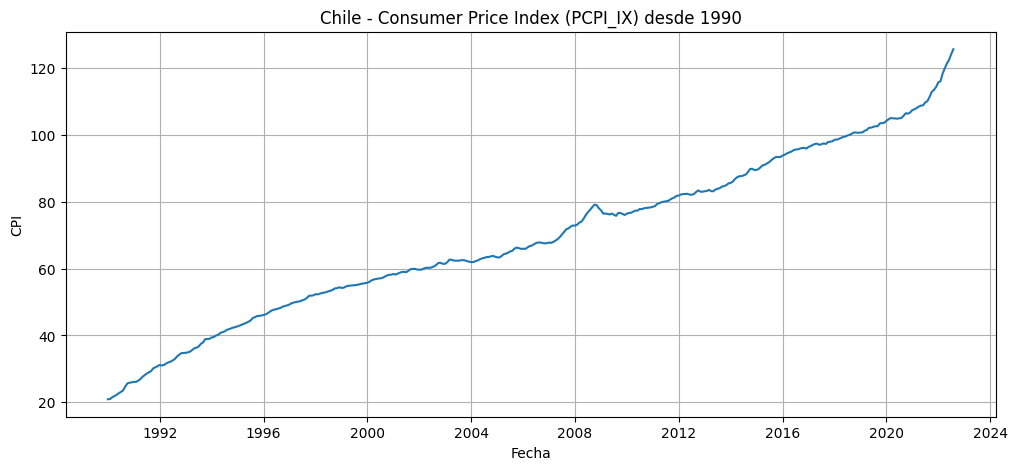

In [12]:
import matplotlib.pyplot as plt

# -------------------------------------------------------
# 16. GRÁFICO DE LA SERIE DESDE 1990
# -------------------------------------------------------
plt.figure(figsize=(12,5))
plt.plot(df_chile_1990["Fecha"], df_chile_1990["CPI"])
plt.title("Chile - Consumer Price Index (PCPI_IX) desde 1990")
plt.xlabel("Fecha")
plt.ylabel("CPI")
plt.grid(True)
plt.show()

In [13]:
# -------------------------------------------------------
# 1. PONER LA FECHA COMO ÍNDICE
# -------------------------------------------------------
# Hacemos una copia para no tocar el DataFrame original
ts = df_chile_1990.copy()

# Ponemos la columna Fecha como índice
ts = ts.set_index("Fecha")

# Mostramos cómo queda
print(ts.head())

                 CPI
Fecha               
1990-01-01  20.92559
1990-02-01  20.98727
1990-03-01  21.49400
1990-04-01  21.87580
1990-05-01  22.20919


### **2. Split train/test**

Here we do it very simply: we leave the last 24 months for the test set and use the rest for training.

This is usually a good idea for monthly series because it leaves 2 years to evaluate forecasts.

In [14]:
# -------------------------------------------------------
# DIVISIÓN CORRECTA TRAIN / VALIDATION / TEST
# -------------------------------------------------------

# Aseguramos que ts está ordenada temporalmente
ts = ts.sort_index()

# Tamaños de validación y test
# Como la serie es mensual, 24 = dos años
validation_size = 24
test_size = 24

# Comprobación básica
if len(ts) <= validation_size + test_size:
    raise ValueError("La serie es demasiado corta para esta división.")

# División cronológica
train = ts.iloc[:-(validation_size + test_size)].copy()                     # todo hasta los últimos 48 meses
validation = ts.iloc[-(validation_size + test_size):-test_size].copy()     # los últimos 24 meses (sin incluir test)
test = ts.iloc[-test_size:].copy()                                          # los últimos 24 meses

print("Train:", train.index.min(), "->", train.index.max(), "| n =", len(train))
print("Validation:", validation.index.min(), "->", validation.index.max(), "| n =", len(validation))
print("Test:", test.index.min(), "->", test.index.max(), "| n =", len(test))

Train: 1990-01-01 00:00:00 -> 2018-08-01 00:00:00 | n = 344
Validation: 2018-09-01 00:00:00 -> 2020-08-01 00:00:00 | n = 24
Test: 2020-09-01 00:00:00 -> 2022-08-01 00:00:00 | n = 24


First plot of the full series

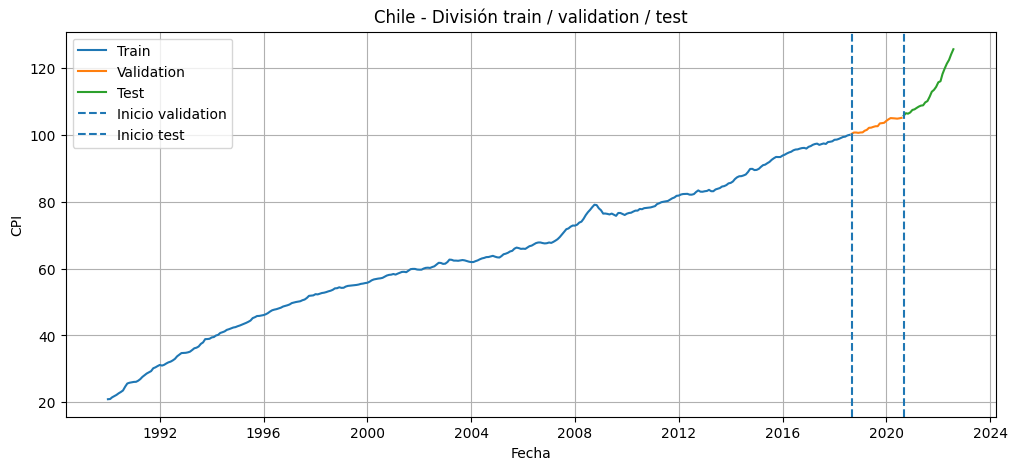

In [15]:
# -------------------------------------------------------
# GRÁFICO DE LA NUEVA DIVISIÓN
# -------------------------------------------------------
plt.figure(figsize=(12, 5))

plt.plot(train.index, train["CPI"], label="Train")
plt.plot(validation.index, validation["CPI"], label="Validation")
plt.plot(test.index, test["CPI"], label="Test")

plt.axvline(validation.index.min(), linestyle="--", label="Inicio validation")
plt.axvline(test.index.min(), linestyle="--", label="Inicio test")

plt.title("Chile - División train / validation / test")
plt.xlabel("Fecha")
plt.ylabel("CPI")
plt.legend()
plt.grid(True)
plt.show()

We can see that this is NOT a stationary series, because it has a clear increasing trend and its mean does not fluctuate around 0. Therefore, we transform the series into a stationary one, either to obtain possible values for d and D for a SARIMA model, or to use models that are only applicable to stationary series, such as AR, MA or ARMA.

Plot of train and test separated

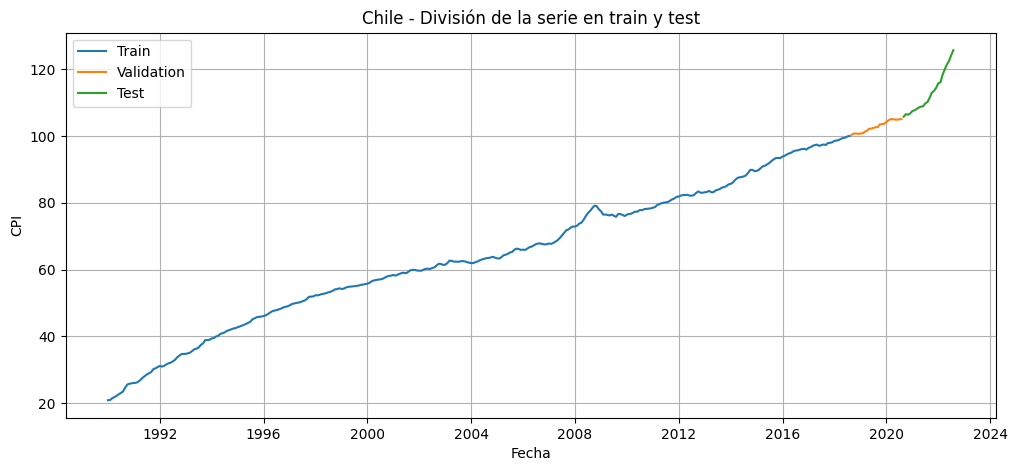

In [16]:
# -------------------------------------------------------
# 5. GRÁFICO DE TRAIN Y TEST
# -------------------------------------------------------
plt.figure(figsize=(12, 5))

# Dibujamos train
plt.plot(train.index, train["CPI"], label="Train")

# Dibujamos validation
plt.plot(validation.index, validation["CPI"], label="Validation")

# Dibujamos test
plt.plot(test.index, test["CPI"], label="Test")

# Añadimos títulos y etiquetas
plt.title("Chile - División de la serie en train y test")
plt.xlabel("Fecha")
plt.ylabel("CPI")

# Leyenda
plt.legend()

# Cuadrícula
plt.grid(True)

# Mostrar gráfico
plt.show()

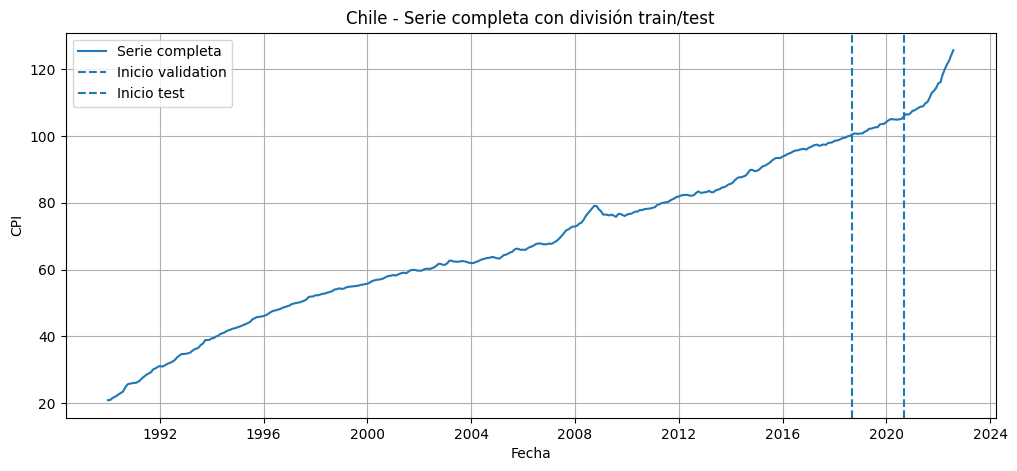

In [17]:
# -------------------------------------------------------
# 6. GRÁFICO CON LÍNEA DE CORTE
# -------------------------------------------------------
plt.figure(figsize=(12, 5))

# Serie completa
plt.plot(ts.index, ts["CPI"], label="Serie completa")

# Fecha en la que empieza la validation
fecha_corte_validation = validation.index.min()

# Fecha en la que empieza el test
fecha_corte_test = test.index.min()

# Línea vertical para marcar la separación
plt.axvline(fecha_corte_validation, linestyle="--", label="Inicio validation")
plt.axvline(fecha_corte_test, linestyle="--", label="Inicio test")

# Título y ejes
plt.title("Chile - Serie completa con división train/test")
plt.xlabel("Fecha")
plt.ylabel("CPI")

# Leyenda y cuadrícula
plt.legend()
plt.grid(True)

# Mostrar gráfico
plt.show()

In [18]:
# -------------------------------------------------------
# GUARDAR VERSIONES LIMPIAS
# -------------------------------------------------------
ts.to_csv("chile_cpi_1990_clean.csv")
train.to_csv("chile_cpi_train.csv")
validation.to_csv("chile_cpi_validation.csv")
test.to_csv("chile_cpi_test.csv")

# Opcional: útil para el ajuste final después de elegir modelo
train_validation = pd.concat([train, validation])
train_validation.to_csv("chile_cpi_train_validation.csv")

print("Files saved successfully.")

Files saved successfully.


The CPI series for Chile was filtered from the original dataset using the indicator PCPI_IX. After preprocessing and restricting the analysis to data from 1990 onwards, the time series was split into two parts: a training set used for characterization, modelling and forecast generation, and a test set containing the last 24 monthly observations, used to evaluate out-of-sample forecasting performance.

### **3. Descriptive characterization of the series**

In [19]:
df = pd.read_csv("chile_cpi_train.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Fecha   344 non-null    object 
 1   CPI     344 non-null    float64
dtypes: float64(1), object(1)
memory usage: 5.5+ KB


In [20]:
df.head()

,Fecha,CPI
0,1990-01-01,20.92559
1,1990-02-01,20.98727
2,1990-03-01,21.49400
3,1990-04-01,21.87580
4,1990-05-01,22.20919


                 CPI
Fecha               
1990-01-01  20.92559
1990-02-01  20.98727
1990-03-01  21.49400
1990-04-01  21.87580
1990-05-01  22.20919
               CPI
Fecha             
2018-04-01   99.13
2018-05-01   99.41
2018-06-01   99.51
2018-07-01   99.86
2018-08-01  100.04


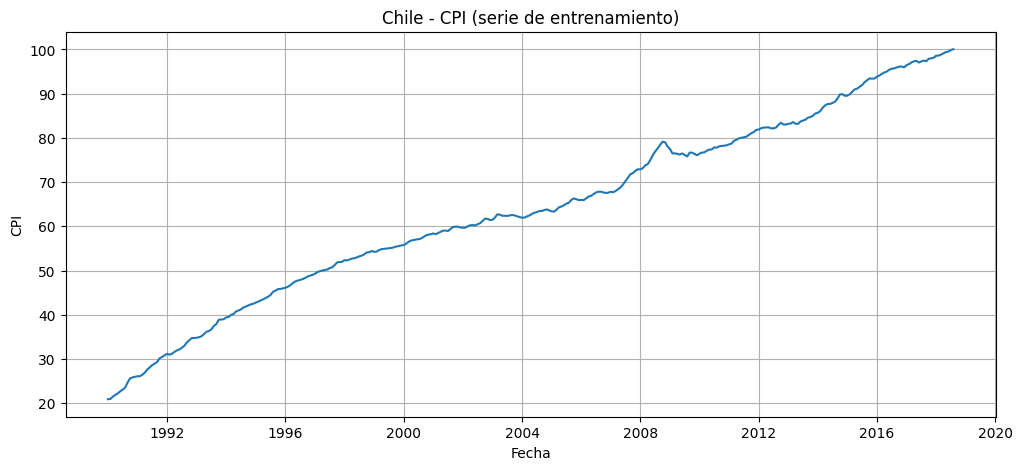

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# 1. CARGAR EL ARCHIVO DE TRAIN
# -------------------------------------------------------
# Leemos el CSV que habíamos guardado antes
df = pd.read_csv("chile_cpi_train.csv")

# -------------------------------------------------------
# 2. CONVERTIR LA COLUMNA DE FECHA A FORMATO FECHA
# -------------------------------------------------------
# Esto permite que Python entienda la columna como fechas reales
df["Fecha"] = pd.to_datetime(df["Fecha"])

# -------------------------------------------------------
# 3. PONER LA FECHA COMO ÍNDICE
# -------------------------------------------------------
# En series temporales es muy útil usar la fecha como índice
df = df.set_index("Fecha")

# -------------------------------------------------------
# 4. VER LAS PRIMERAS FILAS PARA COMPROBAR QUE TODO ESTÁ BIEN
# -------------------------------------------------------
print(df.head())
print(df.tail())

# -------------------------------------------------------
# 5. GRAFICAR LA SERIE COMPLETA
# -------------------------------------------------------
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["CPI"])

plt.title("Chile - CPI (serie de entrenamiento)")
plt.xlabel("Fecha")
plt.ylabel("CPI")
plt.grid(True)

plt.show()

At first sight, an increasing trend can be observed, with a variance that remains more or less constant over time --> additive model

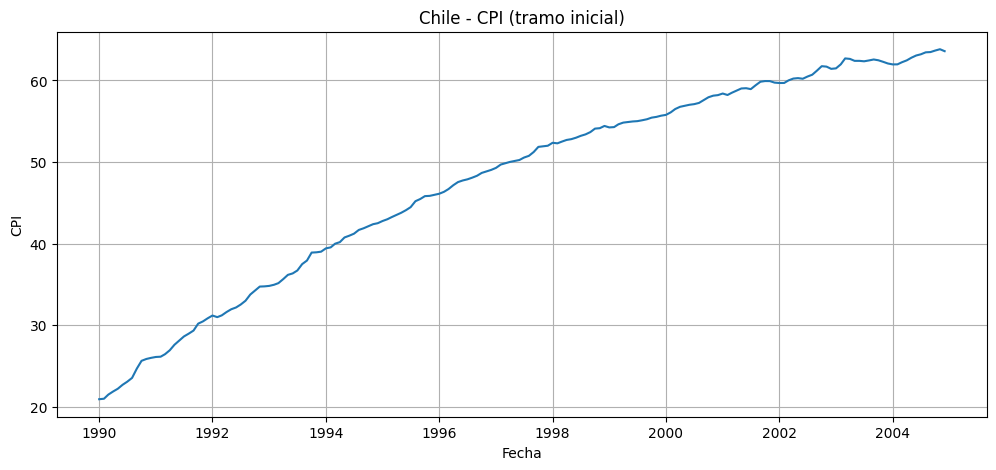

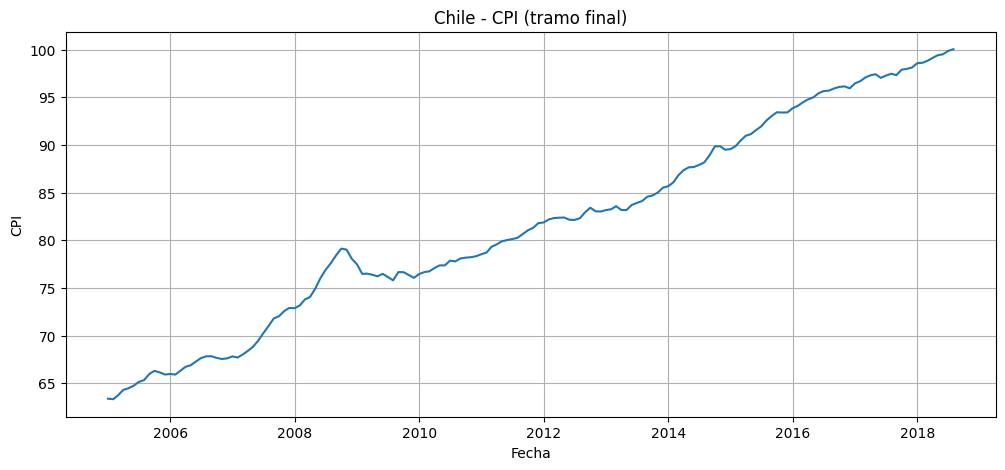

In [22]:
# -------------------------------------------------------
# 8. CREAR DOS SUBPERIODOS PARA COMPARAR
# -------------------------------------------------------
# Primer tramo: parte inicial
df_inicio = df.loc["1990":"2004"].copy()

# Segundo tramo: parte más reciente del train
df_final = df.loc["2005":].copy()

# -------------------------------------------------------
# 9. GRAFICAR LOS DOS TRAMOS POR SEPARADO
# -------------------------------------------------------
plt.figure(figsize=(12, 5))
plt.plot(df_inicio.index, df_inicio["CPI"])
plt.title("Chile - CPI (tramo inicial)")
plt.xlabel("Fecha")
plt.ylabel("CPI")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(df_final.index, df_final["CPI"])
plt.title("Chile - CPI (tramo final)")
plt.xlabel("Fecha")
plt.ylabel("CPI")
plt.grid(True)
plt.show()

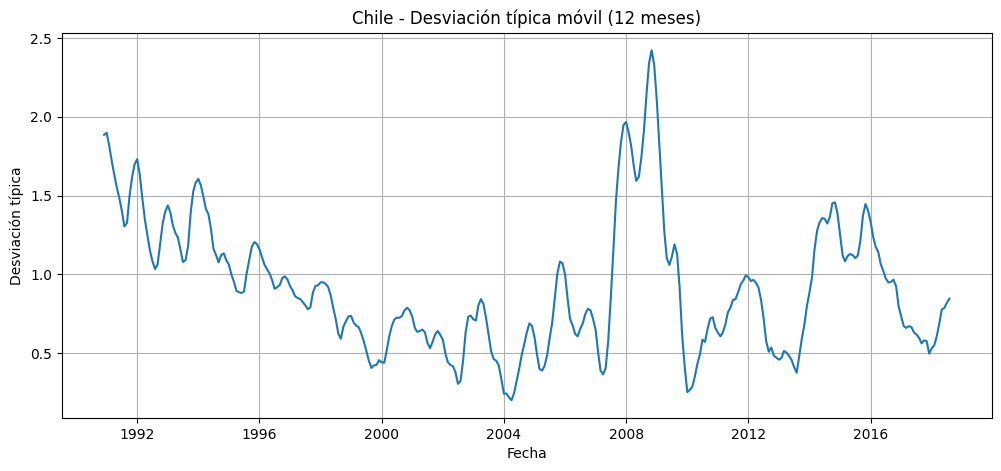

In [23]:
# -------------------------------------------------------
# 10. CALCULAR DESVIACIÓN TÍPICA MÓVIL DE 12 MESES
# -------------------------------------------------------
# Esto mide cuánto se mueve la serie localmente
df["Desv_movil_12"] = df["CPI"].rolling(window=12).std()

# -------------------------------------------------------
# 11. GRAFICAR LA DESVIACIÓN TÍPICA MÓVIL
# -------------------------------------------------------
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["Desv_movil_12"])

plt.title("Chile - Desviación típica móvil (12 meses)")
plt.xlabel("Fecha")
plt.ylabel("Desviación típica")
plt.grid(True)

plt.show()

Con esto comprobamos definitivamente que la varianza se mantiene mas o menos constante a lo largo del tiempo y por ello se debe elegir un **modelo aditivo**

### **4. Stationarity assessment and transformations**

Option 1. Polynomial trend

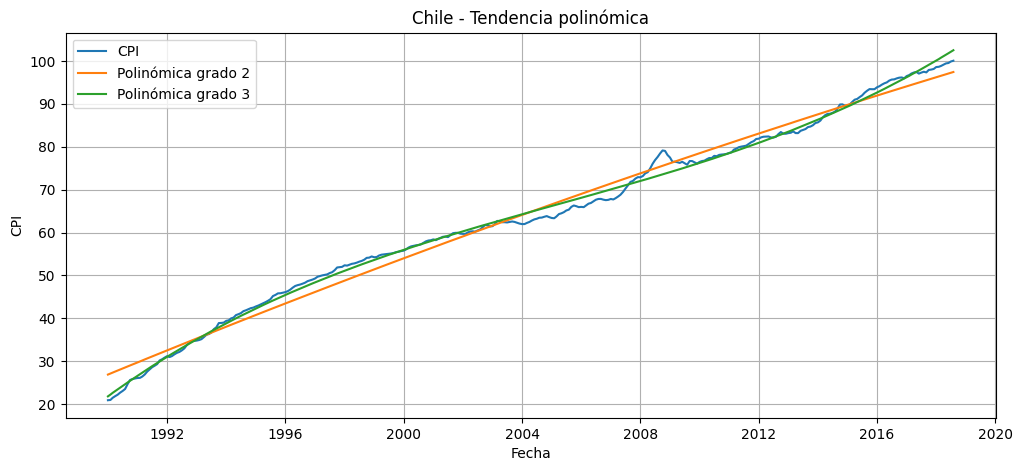

In [24]:
import numpy as np

# -------------------------------------------------------
# 2. CREAR UNA VARIABLE DE TIEMPO NUMÉRICA
# -------------------------------------------------------
# Esto convierte las fechas en una secuencia 0,1,2,3...
t = np.arange(len(df))

# -------------------------------------------------------
# 3. AJUSTAR UNA TENDENCIA POLINÓMICA DE GRADO 2
# -------------------------------------------------------
# polyfit calcula los coeficientes del polinomio
coef_grado2 = np.polyfit(t, df["CPI"], deg=2)

# poly1d crea la función polinómica
polinomio_grado2 = np.poly1d(coef_grado2)

# Calculamos la tendencia estimada
df["Tendencia_polinomica_2"] = polinomio_grado2(t)

# -------------------------------------------------------
# 4. TAMBIÉN PODEMOS PROBAR GRADO 3
# -------------------------------------------------------
coef_grado3 = np.polyfit(t, df["CPI"], deg=3)
polinomio_grado3 = np.poly1d(coef_grado3)
df["Tendencia_polinomica_3"] = polinomio_grado3(t)

# -------------------------------------------------------
# 5. GRAFICAR
# -------------------------------------------------------
plt.figure(figsize=(12,5))
plt.plot(df.index, df["CPI"], label="CPI")
plt.plot(df.index, df["Tendencia_polinomica_2"], label="Polinómica grado 2")
plt.plot(df.index, df["Tendencia_polinomica_3"], label="Polinómica grado 3")

plt.title("Chile - Tendencia polinómica")
plt.xlabel("Fecha")
plt.ylabel("CPI")
plt.legend()
plt.grid(True)
plt.show()

In [25]:
# Grado 2: curva más simple, tipo parábola.
# Grado 3: más flexible, pero también más fácil que “fuerce” la forma.

# Ventaja
    # Muy fácil de explicar.
# Inconveniente
    # A veces impone una forma artificial a la serie.
    # Si la tendencia real cambia de forma local, el polinomio puede no representarla bien.

Option 2. Trend using moving average

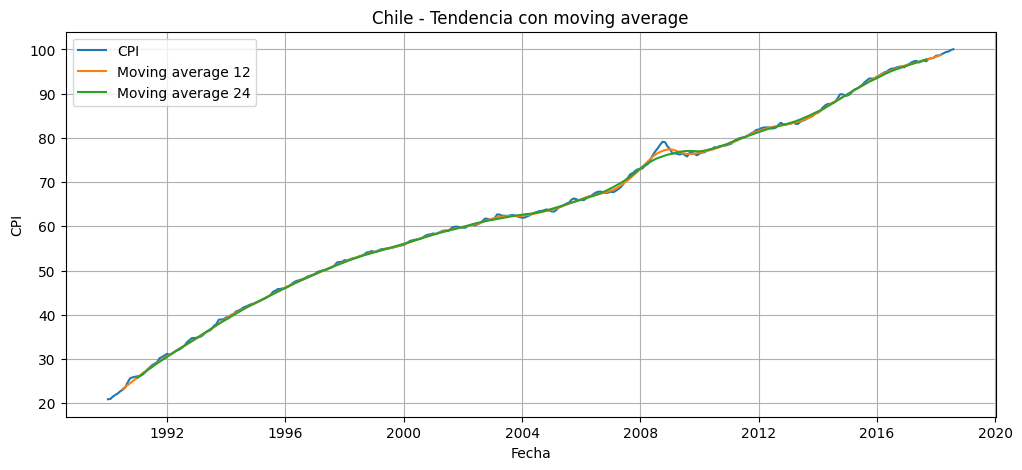

In [26]:
# -------------------------------------------------------
# 6. CALCULAR TENDENCIA CON MEDIA MÓVIL DE 12 MESES
# -------------------------------------------------------
# center=True coloca la media en el centro de la ventana
df["Tendencia_MA_12"] = df["CPI"].rolling(window=12, center=True).mean()

# También podemos probar una ventana más suave, por ejemplo 24 meses
df["Tendencia_MA_24"] = df["CPI"].rolling(window=24, center=True).mean()

# -------------------------------------------------------
# 7. GRAFICAR
# -------------------------------------------------------
plt.figure(figsize=(12,5))
plt.plot(df.index, df["CPI"], label="CPI")
plt.plot(df.index, df["Tendencia_MA_12"], label="Moving average 12")
plt.plot(df.index, df["Tendencia_MA_24"], label="Moving average 24")

plt.title("Chile - Tendencia con moving average")
plt.xlabel("Fecha")
plt.ylabel("CPI")
plt.legend()
plt.grid(True)
plt.show()

In [27]:
# MA 12: capta bien la evolución anual y suaviza bastante.
# MA 24: aún más suave, útil si quieres una tendencia muy de largo plazo.

# Ventaja
    # Muy intuitiva.
    # Muy fácil de justificar en un proyecto de series temporales.
    # Encaja especialmente bien con series mensuales.
# Inconveniente
    # En los extremos de la serie aparecen NaN.
    # No siempre recoge bien cambios más sutiles en la pendiente.

Option 3. LOWESS / LOESS trend

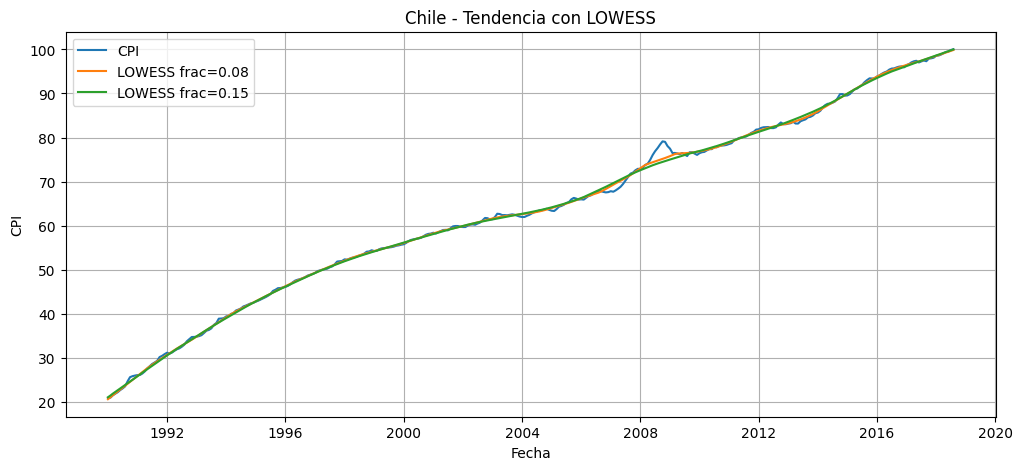

In [28]:
from statsmodels.nonparametric.smoothers_lowess import lowess

# -------------------------------------------------------
# 8. CALCULAR TENDENCIA CON LOWESS
# -------------------------------------------------------
# frac controla cuánto suaviza:
# - valores pequeños: sigue más la serie
# - valores grandes: más suavizado
lowess_resultado_1 = lowess(endog=df["CPI"], exog=t, frac=0.08, return_sorted=False)
lowess_resultado_2 = lowess(endog=df["CPI"], exog=t, frac=0.15, return_sorted=False)

# Guardamos ambas opciones en el DataFrame
df["Tendencia_LOWESS_008"] = lowess_resultado_1
df["Tendencia_LOWESS_015"] = lowess_resultado_2

# -------------------------------------------------------
# 9. GRAFICAR
# -------------------------------------------------------
plt.figure(figsize=(12,5))
plt.plot(df.index, df["CPI"], label="CPI")
plt.plot(df.index, df["Tendencia_LOWESS_008"], label="LOWESS frac=0.08")
plt.plot(df.index, df["Tendencia_LOWESS_015"], label="LOWESS frac=0.15")

plt.title("Chile - Tendencia con LOWESS")
plt.xlabel("Fecha")
plt.ylabel("CPI")
plt.legend()
plt.grid(True)
plt.show()

In [29]:
# frac=0.08: menos suavizado, sigue más los movimientos.
# frac=0.15: más suavizado, mejor para largo plazo.

# Ventaja
    # Suele describir muy bien la tendencia real.
    # No obliga a que la curva sea una parábola o similar.
# Inconveniente
    # Es algo menos “básico” que moving average.
    # A veces queda muy bien visualmente, pero cuesta más justificarla si en clase no habéis trabajado este método.

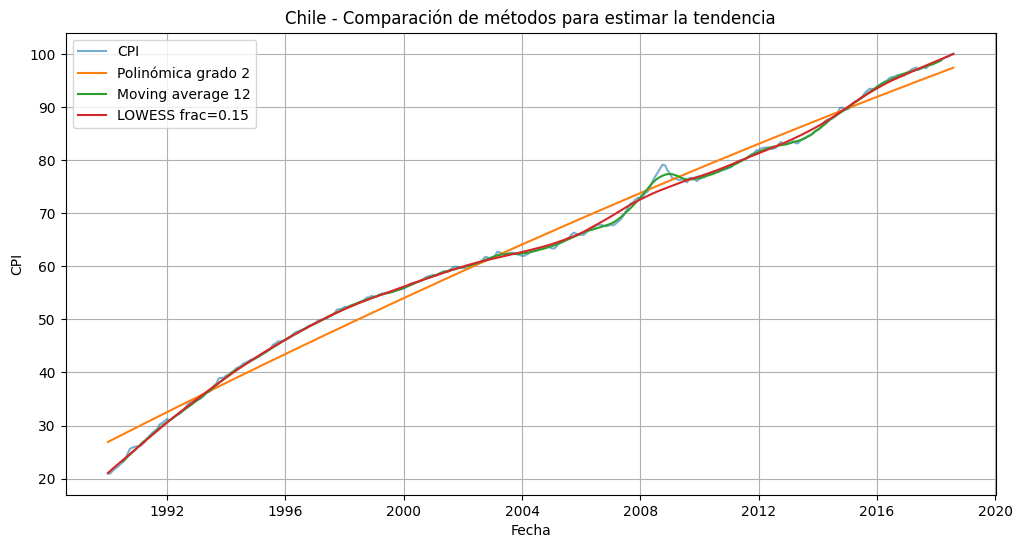

In [30]:
# -------------------------------------------------------
# 10. COMPARAR TODAS LAS TENDENCIAS EN UN SOLO GRÁFICO
# -------------------------------------------------------
plt.figure(figsize=(12,6))

plt.plot(df.index, df["CPI"], label="CPI", alpha=0.6)
plt.plot(df.index, df["Tendencia_polinomica_2"], label="Polinómica grado 2")
plt.plot(df.index, df["Tendencia_MA_12"], label="Moving average 12")
plt.plot(df.index, df["Tendencia_LOWESS_015"], label="LOWESS frac=0.15")

plt.title("Chile - Comparación de métodos para estimar la tendencia")
plt.xlabel("Fecha")
plt.ylabel("CPI")
plt.legend()
plt.grid(True)
plt.show()

We can clearly see that the best approximation is "Moving average 12". It is also simpler than LOWESS, so we will use it to estimate the trend.

In [31]:
df.head()

,CPI,Desv_movil_12,Tendencia_polinomica_2,Tendencia_polinomica_3,Tendencia_MA_12,Tendencia_MA_24,Tendencia_LOWESS_008,Tendencia_LOWESS_015
Fecha,,,,,,,,
1990-01-01,20.92559,NaN,26.901656,21.824404,NaN,NaN,20.626705,21.068800
1990-02-01,20.98727,NaN,27.138221,22.238599,NaN,NaN,21.065784,21.470852
1990-03-01,21.49400,NaN,27.374605,22.650016,NaN,NaN,21.504816,21.872224
1990-04-01,21.87580,NaN,27.610808,23.058670,NaN,NaN,21.943681,22.272890
1990-05-01,22.20919,NaN,27.846830,23.464577,NaN,NaN,22.382263,22.672836


We now remove the trend and study seasonality. To do this, we use the maSmooth function seen in class, applying data augmentation so we do not have to discard the first values of the series that would otherwise be considered NaN.

Fecha
1990-01-01    20.92559
1990-02-01    20.98727
1990-03-01    21.49400
1990-04-01    21.87580
1990-05-01    22.20919
Name: Chile CPI, dtype: float64
Fecha
1990-01-01    21.803965
1990-02-01    21.868830
1990-03-01    22.059759
1990-04-01    22.348826
1990-05-01    22.684680
Name: Smoothed TS with M=13, dtype: float64


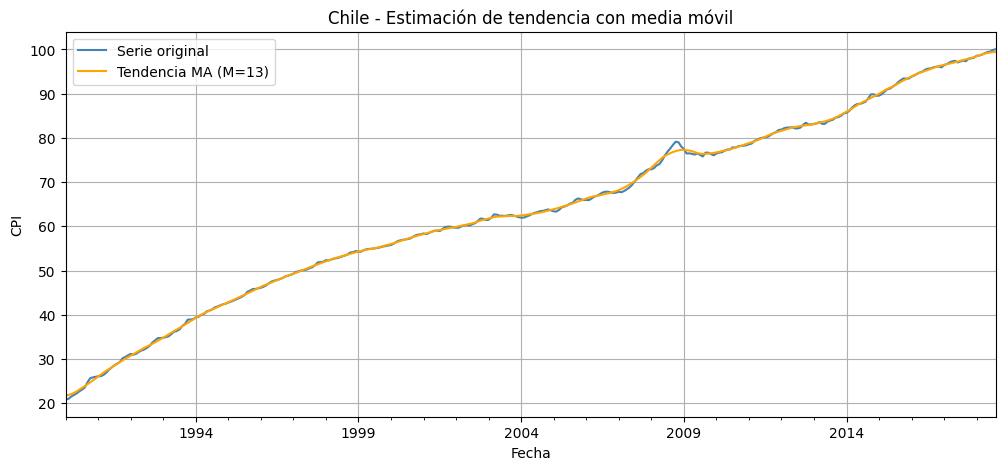

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =============================================================
# 1. CARGAR LA SERIE DE ENTRENAMIENTO
# =============================================================
# Leemos el archivo CSV que guardaste antes
df = pd.read_csv("chile_cpi_train.csv")

# Convertimos la columna de fecha a formato fecha real
df["Fecha"] = pd.to_datetime(df["Fecha"])

# Ponemos la fecha como índice temporal
df = df.set_index("Fecha")

# Creamos la serie temporal que vamos a usar
ts = pd.Series(df["CPI"], name="Chile CPI")

# Mostramos las primeras filas para comprobar que todo está bien
print(ts.head())

# =============================================================
# 2. FUNCION DE MEDIA MOVIL DE CLASE
# =============================================================
def maSmooth(TSeries, omega, data_aug=False):
    # M es el tamaño de la ventana del filtro
    M = omega.shape[0]
    
    # lag es el número de datos a cada lado del punto central
    lag = int(np.floor((M - 1) / 2))
    
    # Si activamos data_aug=True, ampliamos la serie por los extremos
    # para no perder datos al principio y al final
    if data_aug:
        TSeriesAug = pd.concat([TSeries, TSeries[-lag:][::-1]])
        TSeriesAug = pd.concat([TSeries[0:lag][::-1], TSeriesAug])
    else:
        TSeriesAug = TSeries
        
    # Índices sobre los que podemos aplicar el filtro
    nf = range(lag, TSeriesAug.size - lag)
    
    # Aquí guardaremos la serie suavizada
    xf = np.zeros(TSeriesAug.size - 2 * lag).astype("float")
    
    # Aplicamos la media móvil ponderada
    for n in nf:
        xf[n - lag] = (1 / float(sum(omega))) * np.sum(
            np.multiply(TSeriesAug[n - lag:n + lag + 1], omega)
        )
        
    # Convertimos el resultado en una serie temporal con el mismo índice
    xf = pd.Series(
        data=xf,
        index=TSeriesAug.index[lag:TSeriesAug.size - lag],
        name="Smoothed TS with M=" + str(M)
    )
    
    return xf

# =============================================================
# 3. ESTIMACION DE TENDENCIA CON MEDIA MOVIL
# =============================================================
# Como la serie es mensual, usamos una ventana anual centrada
# En la práctica de clase se usa M = 13 --> ¡OJO! la función está pensada de forma natural para ventanas impares y una ventana impar tiene un centro exacto
M = 13

# omega son los pesos del filtro
# Como queremos una media móvil simple, todos los pesos son iguales
omega = np.ones(M) * (1 / float(M))

# Calculamos la tendencia suavizada
trend = maSmooth(ts, omega, data_aug=True)

# Mostramos las primeras filas
print(trend.head())

# =============================================================
# 4. GRAFICO DE SERIE ORIGINAL + TENDENCIA
# =============================================================
plt.figure(figsize=(12, 5))

# Serie original
ax = ts.plot(color="steelblue", label="Serie original")

# Tendencia estimada
trend.plot(color="orange", label="Tendencia MA (M=13)")

# Etiquetas y título
ax.set_ylabel("CPI")
ax.set_xlabel("Fecha")
plt.title("Chile - Estimación de tendencia con media móvil")

# Leyenda y cuadrícula
plt.legend()
plt.grid(True)

plt.show()

Fecha
1990-01-01   -0.878375
1990-02-01   -0.881560
1990-03-01   -0.565759
1990-04-01   -0.473026
1990-05-01   -0.475490
Name: Serie sin tendencia, dtype: float64


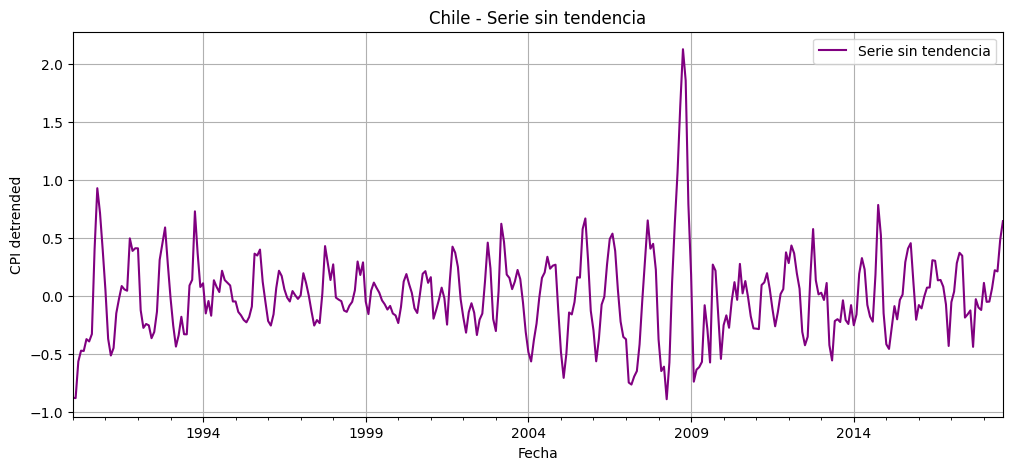

In [33]:
# =============================================================
# 5. ELIMINAR LA TENDENCIA
# =============================================================
ts_no_trend = ts - trend
ts_no_trend.name = "Serie sin tendencia"

# Mostramos algunas filas
print(ts_no_trend.head())

# =============================================================
# 6. GRAFICAR LA SERIE SIN TENDENCIA
# =============================================================
plt.figure(figsize=(12, 5))

ax = ts_no_trend.plot(color="purple", label="Serie sin tendencia")

ax.set_ylabel("CPI detrended")
ax.set_xlabel("Fecha")
plt.title("Chile - Serie sin tendencia")

plt.legend()
plt.grid(True)

plt.show()

Como la serie sigue teniendo una estructura no estacionaria pero sin tendencia entonces puede que haya estacionalidad

Siguiente paso es Estudiar la estacionalidad con "epoch averaging". Por ello, vamos a graficar su DFT y su ACF para razonar sobre el valor de "S"

<Figure size 1000x500 with 0 Axes>

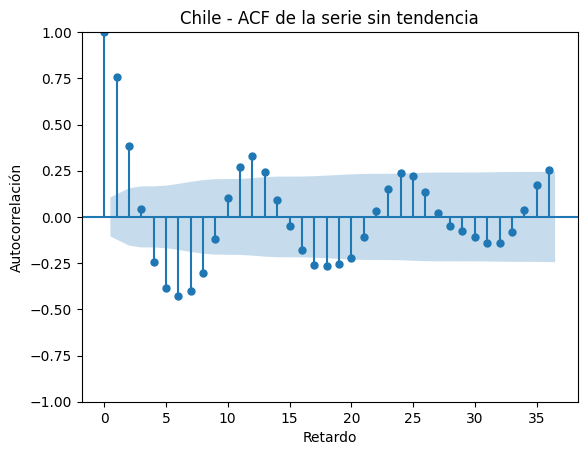

In [34]:
from statsmodels.graphics.tsaplots import plot_acf

# =============================================================
# 14. ACF DE LA SERIE SIN TENDENCIA
# =============================================================
plt.figure(figsize=(10, 5))
plot_acf(ts_no_trend.dropna(), lags=36)

plt.title("Chile - ACF de la serie sin tendencia")
plt.xlabel("Retardo")
plt.ylabel("Autocorrelación")

plt.show()

We can see that every 6 lags there is a significant peak, which suggests that S could be 6 instead of 12, as initially expected. We will verify this definitively with Fourier analysis.

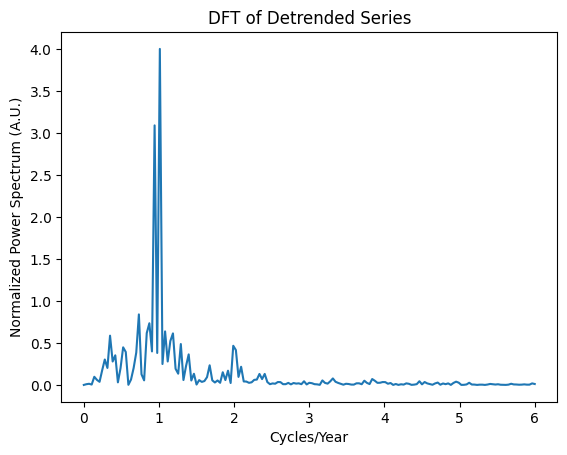

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.signal as scs

# =============================================================
# DFT/FFT SOBRE LA SERIE SIN TENDENCIA
# =============================================================

# Espectro de potencia normalizado
fTS = (np.abs(np.fft.rfft(ts_no_trend - ts_no_trend.mean()))**2 / ts_no_trend.size)

# Frecuencias asociadas (12 muestras/año porque la serie es mensual)
samp_freq = 12
f = np.fft.rfftfreq(ts_no_trend.size, d=1/samp_freq)

plt.figure()
plt.plot(f, fTS)
plt.xlabel("Cycles/Year")
plt.ylabel("Normalized Power Spectrum (A.U.)")
plt.title("DFT of Detrended Series")
plt.show()

The dominant frequency of the detrended series is 1 cycle/year, because that is the main peak in the DFT.

The ACF shows an oscillatory structure with signal also at multiples of 6 months, but this is compatible with the presence of an annual component with semiannual harmonics.

Therefore, the base seasonal cycle remains annual.

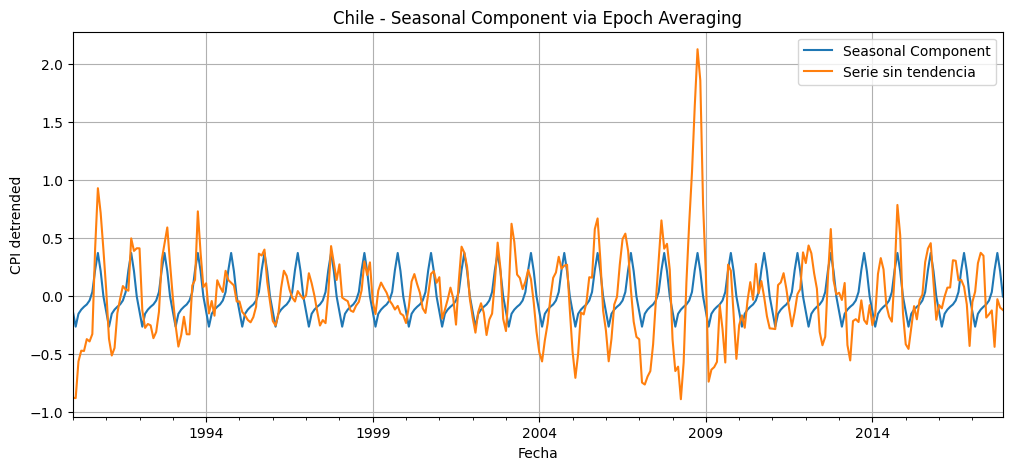

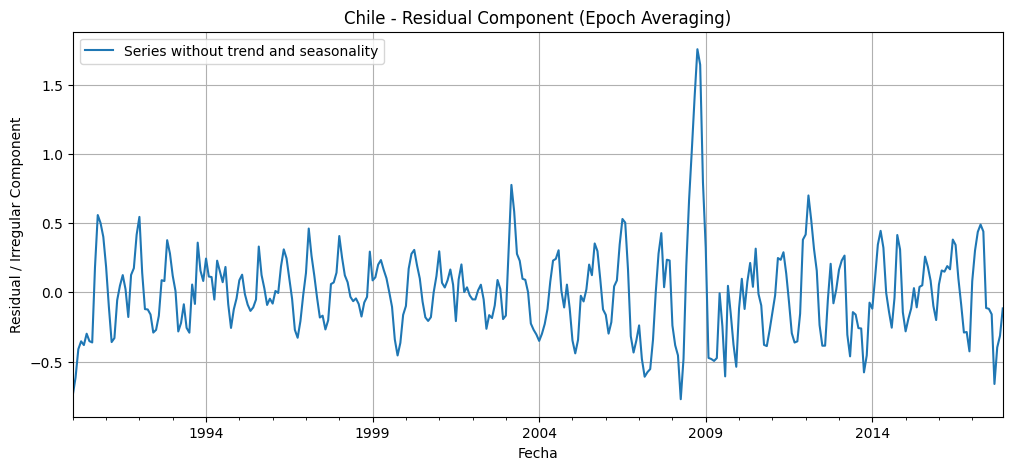

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =============================================================
# EPOCH AVERAGING — CHILE CPI
# =============================================================

# Periodicidad mensual
S = 12

# Serie sin tendencia, quitando posibles NaN
ts_det = ts_no_trend.dropna()

# Número total de muestras
N = ts_det.size

# Número de ciclos completos
C = int(np.floor(N / S))

# Nos quedamos solo con los datos que caben en ciclos completos
ts_det = ts_det[0:C*S]

# Reorganizar la serie en una matriz: una fila por ciclo, una columna por mes
reshTS = np.array(ts_det).reshape((C, S))

# Calcular el ciclo estacional medio
ac = np.tile(np.mean(reshTS, axis=0), (C,))

# Construir la serie de la componente estacional
SeaTS = pd.Series(data=ac, index=ts_det.index, name="Seasonal Component")

# =============================================================
# GRAFICAR COMPONENTE ESTACIONAL
# =============================================================
plt.figure(figsize=(12,5))
SeaTS.plot(legend=True)
ax = ts_det.plot(legend=True)
ax.set_ylabel("CPI detrended")
ax.set_xlabel("Fecha")
plt.title("Chile - Seasonal Component via Epoch Averaging")
plt.grid(True)
plt.show()

# =============================================================
# ELIMINAR ESTACIONALIDAD — MODELO ADITIVO
# =============================================================
ts_no_trend_no_seas = ts_det - SeaTS
ts_no_trend_no_seas.name = "Series without trend and seasonality"

# =============================================================
# GRAFICAR RESIDUAL
# =============================================================
plt.figure(figsize=(12,5))
ax = ts_no_trend_no_seas.plot(legend=True)
ax.set_ylabel("Residual / Irregular Component")
ax.set_xlabel("Fecha")
plt.title("Chile - Residual Component (Epoch Averaging)")
plt.grid(True)
plt.show()

The blue component shows a pattern that repeats fairly regularly over time. That is exactly what epoch averaging does: it builds an average annual cycle and repeats it across the whole series.

The detrended series, in orange, follows that pattern in many sections, although not perfectly. This is normal:

- part of the variation is seasonal,
- but another part remains irregular.

--> This plot suggests that annual seasonality does exist in the Chilean series, because the estimated average pattern captures a visible repetitive structure.

*What important detail appears*

There is a very striking episode around 2008-2009, with a strong peak in the detrended series that the seasonal component cannot explain. This indicates an irregular shock or extraordinary variation that is not part of the average seasonal pattern.

SERIES WITHOUT TREND OR SEASONALITY
- The residual series does fluctuate around 0.
- Its amplitude is much smaller than in the original series.
- A clear annual pattern is no longer visible.

However, it is not "pure noise". Even so, the residual series does not seem completely random:

- some oscillations still have structure,
- and the strong 2008-2009 episode stands out again with a very large peak.

This suggests that:

- either some temporal dependence remains,
- or the series contains shocks that are not removed by such a simple decomposition.

We now check whether the resulting series is already stationary or whether stationarity has not yet been achieved.

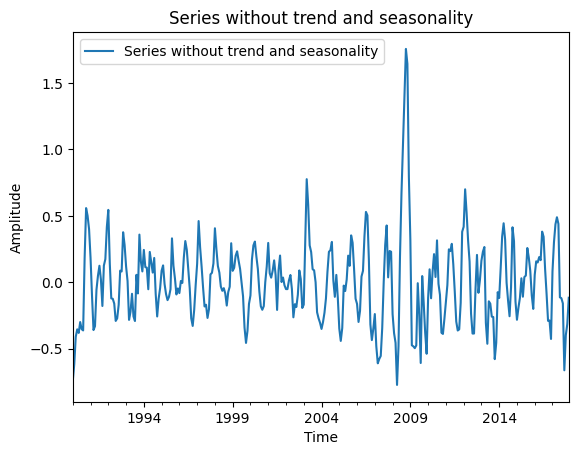

ADF Test — Series without trend and seasonality
ADF Statistic: -9.402709369128683
p-value: 6.126372776248087e-16
Critical Values:
   1%: -3.4503224123605194
   5%: -2.870338478726661
   10%: -2.571457612488522



<Figure size 1000x500 with 0 Axes>

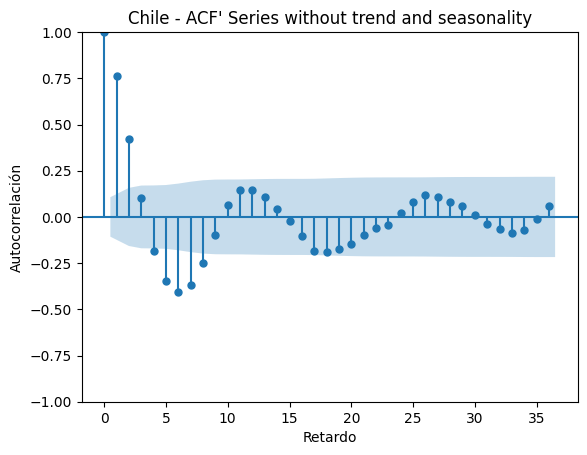

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# ==============================
# FUNCIÓN PARA MOSTRAR RESULTADOS ADF
# ==============================

def ADFtest(series, name=""):
    result = adfuller(series.dropna())
    print("====================================")
    print("ADF Test —", name)
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value}")
    print("====================================\n")

# ==============================
# 1) SERIE SIN TENDENCIA Y SIN ESTACIONALIDAD
# ==============================

plt.figure()
ts_no_trend_no_seas.plot(title="Series without trend and seasonality", legend=True)
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

ADFtest(ts_no_trend_no_seas, "Series without trend and seasonality")

from statsmodels.graphics.tsaplots import plot_acf

# =============================================================
# 2. ACF DE LA SERIE SIN TENDENCIA Y SIN ESTACIONALIDAD
# =============================================================
plt.figure(figsize=(10, 5))
plot_acf(ts_no_trend_no_seas.dropna(), lags=36)

plt.title("Chile - ACF' Series without trend and seasonality")
plt.xlabel("Retardo")
plt.ylabel("Autocorrelación")

plt.show()

We have removed the trend and seasonality, and the ADF test indicates that the series is stationary. However, the ACF structure of the series without trend and seasonality still shows a pattern that can be used to apply Box-Jenkins models for forecasting.

A series can be stationary and, at the same time, have a structured ACF.

This does not imply "non-stationarity".

### **5. Basic baseline construction through trend-curve extrapolation**

The idea is for this model to be deliberately simple: it only tries to capture the overall trend of the CPI series, without explicitly modeling seasonality or temporal dependence in the residuals. This works well as a comparison point because the previous analysis already showed that the Chilean series has a clear increasing trend, approximately stable variance and an annual seasonal component detected after removing the trend.

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error

# =============================================================
# 1. CARGAR LOS FICHEROS YA GUARDADOS
# =============================================================

train = pd.read_csv("chile_cpi_train.csv")
validation = pd.read_csv("chile_cpi_validation.csv")
test = pd.read_csv("chile_cpi_test.csv")
train_validation = pd.read_csv("chile_cpi_train_validation.csv")

# Convertimos Fecha a datetime
for df_aux in [train, validation, test, train_validation]:
    df_aux["Fecha"] = pd.to_datetime(df_aux["Fecha"])
    df_aux.set_index("Fecha", inplace=True)

# Comprobamos tamaños
print("Train:", train.index.min(), "->", train.index.max(), "| n =", len(train))
print("Validation:", validation.index.min(), "->", validation.index.max(), "| n =", len(validation))
print("Test:", test.index.min(), "->", test.index.max(), "| n =", len(test))
print("Train + Validation:", train_validation.index.min(), "->", train_validation.index.max(), "| n =", len(train_validation))

Train: 1990-01-01 00:00:00 -> 2018-08-01 00:00:00 | n = 344
Validation: 2018-09-01 00:00:00 -> 2020-08-01 00:00:00 | n = 24
Test: 2020-09-01 00:00:00 -> 2022-08-01 00:00:00 | n = 24
Train + Validation: 1990-01-01 00:00:00 -> 2020-08-01 00:00:00 | n = 368


**5.1. Baseline with polynomial curves**

We will test several trend curves:

- Degree 1: linear trend.
- Degree 2: quadratic trend.
- Degree 3: cubic trend.

The logic is:

1. Fit each curve using train.
2. Predict on validation.
3. Compute errors.
4. Choose a reasonable curve.
5. Refit using train_validation.
6. Finally evaluate on test.

This keeps the process clean: validation is used to choose the baseline, and test remains reserved for the final evaluation.

In [39]:
# =============================================================
# 2. FUNCIONES AUXILIARES
# =============================================================

def preparar_tiempo(n):
    """
    Crea una variable temporal numérica: 0, 1, 2, ..., n-1
    """
    return np.arange(n)


def ajustar_polinomio(y_train, grado):
    """
    Ajusta una curva polinómica de grado dado a la serie de entrenamiento.
    """
    t_train = preparar_tiempo(len(y_train))
    coef = np.polyfit(t_train, y_train, deg=grado)
    modelo = np.poly1d(coef)
    return modelo


def predecir_polinomio(modelo, n_train, horizonte):
    """
    Extrapola la curva ajustada hacia el futuro.
    
    n_train: longitud usada para entrenar.
    horizonte: número de pasos a predecir.
    """
    t_future = np.arange(n_train, n_train + horizonte)
    pred = modelo(t_future)
    return pred


def calcular_metricas(y_real, y_pred):
    """
    Calcula métricas básicas de forecasting.
    """
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mape = np.mean(np.abs((y_real - y_pred) / y_real)) * 100
    
    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }

**5.2. Fit on train and evaluation on validation**

In [40]:
# =============================================================
# 3. EVALUAR CURVAS EN VALIDATION
# =============================================================

grados = [1, 2, 3]

resultados_baseline_val = []

y_train = train["CPI"].values
y_val = validation["CPI"].values

predicciones_validation = {}

for grado in grados:
    
    # Ajustamos el modelo solo con train
    modelo = ajustar_polinomio(y_train, grado)
    
    # Predecimos validation
    y_pred_val = predecir_polinomio(
        modelo=modelo,
        n_train=len(train),
        horizonte=len(validation)
    )
    
    # Guardamos predicciones
    predicciones_validation[f"Polinomio grado {grado}"] = y_pred_val
    
    # Calculamos métricas
    metricas = calcular_metricas(y_val, y_pred_val)
    
    resultados_baseline_val.append({
        "Modelo": f"Polinomio grado {grado}",
        "MAE": metricas["MAE"],
        "RMSE": metricas["RMSE"],
        "MAPE": metricas["MAPE"]
    })

resultados_baseline_val = pd.DataFrame(resultados_baseline_val)
resultados_baseline_val = resultados_baseline_val.sort_values("RMSE")

print(resultados_baseline_val)

              Modelo       MAE      RMSE      MAPE
0  Polinomio grado 1  1.104118  1.173088  1.069028
1  Polinomio grado 2  3.283469  3.332054  3.184802
2  Polinomio grado 3  4.306627  4.433660  4.173346


**5.3. Plot of predictions on validation**

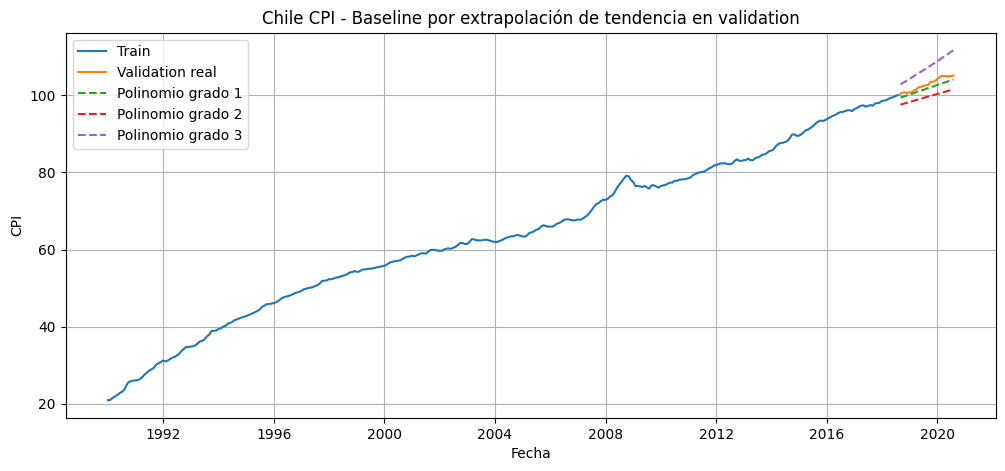

In [41]:
# =============================================================
# 4. GRÁFICO TRAIN + VALIDATION + PREDICCIONES
# =============================================================

plt.figure(figsize=(12, 5))

plt.plot(train.index, train["CPI"], label="Train")
plt.plot(validation.index, validation["CPI"], label="Validation real")

for nombre_modelo, pred in predicciones_validation.items():
    plt.plot(validation.index, pred, linestyle="--", label=nombre_modelo)

plt.title("Chile CPI - Baseline por extrapolación de tendencia en validation")
plt.xlabel("Fecha")
plt.ylabel("CPI")
plt.legend()
plt.grid(True)
plt.show()

Here we should look at two things:

1. Numerical error, especially RMSE.
2. Visual behavior, that is, whether the extrapolated curve reasonably follows the level of the series.

A higher-degree polynomial may fit the past better, but it can also extrapolate worse. Therefore, it is not convenient to automatically choose the highest degree. For this baseline, it is preferable to keep a simple and easy-to-justify curve.

**5.4. Manual baseline selection**

After looking at the table, we can choose the best degree according to RMSE. To automate this:

In [42]:
# =============================================================
# 5. SELECCIONAR EL MEJOR BASELINE SEGÚN RMSE EN VALIDATION
# =============================================================

mejor_modelo_nombre = resultados_baseline_val.iloc[0]["Modelo"]
mejor_grado = int(mejor_modelo_nombre.split()[-1])

print("Best baseline according to RMSE on validation:", mejor_modelo_nombre)
print("Selected degree:", mejor_grado)

Best baseline according to RMSE on validation: Polinomio grado 1
Selected degree: 1


**5.5. Final evaluation on test**

Una vez elegido el grado con validation, reentrenamos el baseline usando train_validation, porque ahora ya podemos usar train + validation para ajustar el modelo final antes de evaluar en test.

In [43]:
# =============================================================
# 6. REENTRENAR BASELINE FINAL CON TRAIN + VALIDATION
# =============================================================

y_train_val = train_validation["CPI"].values
y_test = test["CPI"].values

modelo_baseline_final = ajustar_polinomio(y_train_val, mejor_grado)

y_pred_test_baseline = predecir_polinomio(
    modelo=modelo_baseline_final,
    n_train=len(train_validation),
    horizonte=len(test)
)

metricas_test_baseline = calcular_metricas(y_test, y_pred_test_baseline)

print("Final baseline metrics on test:")
print(metricas_test_baseline)

Final baseline metrics on test:
{'MAE': 5.974479183512391, 'RMSE': np.float64(7.586831649154883), 'MAPE': np.float64(5.091078992770732)}


**5.6. Final plot: prediction versus test**

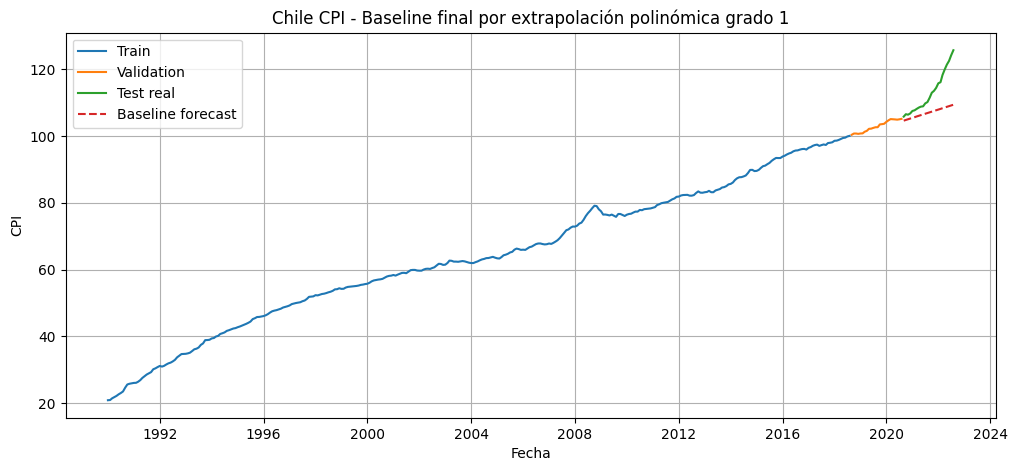

In [44]:
# =============================================================
# 7. GRÁFICO FINAL DEL BASELINE EN TEST
# =============================================================

plt.figure(figsize=(12, 5))

plt.plot(train.index, train["CPI"], label="Train")
plt.plot(validation.index, validation["CPI"], label="Validation")
plt.plot(test.index, test["CPI"], label="Test real")
plt.plot(test.index, y_pred_test_baseline, linestyle="--", label="Baseline forecast")

plt.title(f"Chile CPI - Baseline final por extrapolación polinómica grado {mejor_grado}")
plt.xlabel("Fecha")
plt.ylabel("CPI")
plt.legend()
plt.grid(True)
plt.show()

**5.7. Zoomed plot only on test**

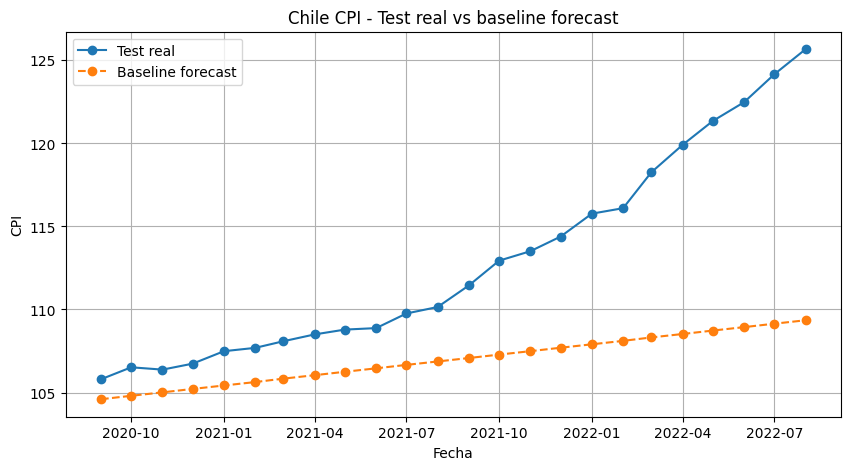

In [45]:
# =============================================================
# 8. GRÁFICO AMPLIADO TEST REAL VS FORECAST
# =============================================================

plt.figure(figsize=(10, 5))

plt.plot(test.index, test["CPI"], marker="o", label="Test real")
plt.plot(test.index, y_pred_test_baseline, marker="o", linestyle="--", label="Baseline forecast")

plt.title("Chile CPI - Test real vs baseline forecast")
plt.xlabel("Fecha")
plt.ylabel("CPI")
plt.legend()
plt.grid(True)
plt.show()

**5.8. Guardar resultados del baseline**

In [46]:
# =============================================================
# 9. GUARDAR RESULTADOS DEL BASELINE
# =============================================================

baseline_test_results = test.copy()
baseline_test_results["Baseline_Forecast"] = y_pred_test_baseline
baseline_test_results["Error"] = baseline_test_results["CPI"] - baseline_test_results["Baseline_Forecast"]

baseline_test_results.to_csv("chile_cpi_baseline_test_forecast.csv")

resultados_baseline_val.to_csv("chile_cpi_baseline_validation_metrics.csv", index=False)

metricas_baseline_test_df = pd.DataFrame([{
    "Modelo": f"Baseline polinómico grado {mejor_grado}",
    "MAE": metricas_test_baseline["MAE"],
    "RMSE": metricas_test_baseline["RMSE"],
    "MAPE": metricas_test_baseline["MAPE"]
}])

metricas_baseline_test_df.to_csv("chile_cpi_baseline_test_metrics.csv", index=False)

print("Baseline results saved successfully.")

Baseline results saved successfully.


### **6. Box&Jenkins y forecasting**

**6.1. Cargar datos ya divididos**

Train: 1990-01-01 00:00:00 -> 2018-08-01 00:00:00 | n = 344
Validation: 2018-09-01 00:00:00 -> 2020-08-01 00:00:00 | n = 24
Test: 2020-09-01 00:00:00 -> 2022-08-01 00:00:00 | n = 24
Train + validation: 1990-01-01 00:00:00 -> 2020-08-01 00:00:00 | n = 368


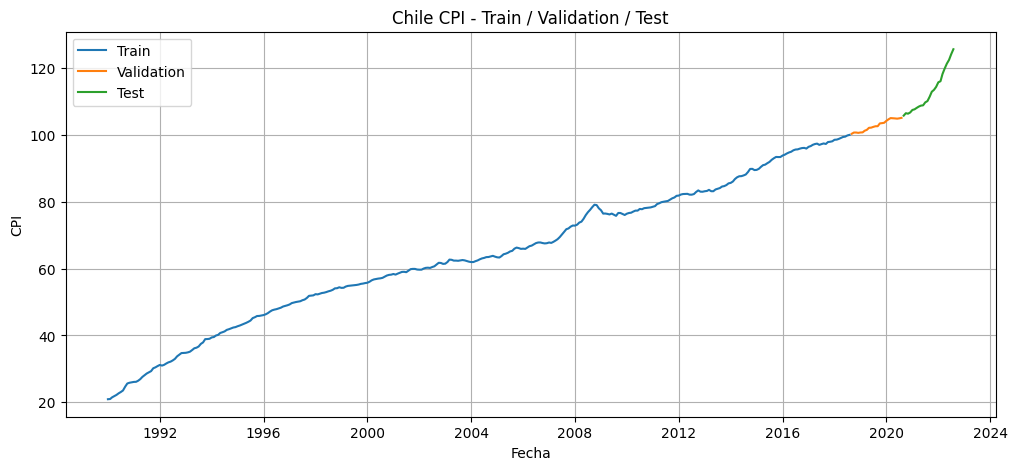

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, acf

from sklearn.metrics import mean_squared_error, mean_absolute_error
import scipy.stats as spyst

warnings.filterwarnings("ignore")

# =============================================================
# 1. CARGAR DATASETS YA DIVIDIDOS
# =============================================================

train = pd.read_csv("chile_cpi_train.csv")
validation = pd.read_csv("chile_cpi_validation.csv")
test = pd.read_csv("chile_cpi_test.csv")
train_validation = pd.read_csv("chile_cpi_train_validation.csv")

# Convertir Fecha a datetime y ponerla como índice
for df_aux in [train, validation, test, train_validation]:
    df_aux["Fecha"] = pd.to_datetime(df_aux["Fecha"])
    df_aux.set_index("Fecha", inplace=True)

# Convertir a Series
train_ts = train["CPI"]
validation_ts = validation["CPI"]
test_ts = test["CPI"]
train_validation_ts = train_validation["CPI"]

print("Train:", train_ts.index.min(), "->", train_ts.index.max(), "| n =", len(train_ts))
print("Validation:", validation_ts.index.min(), "->", validation_ts.index.max(), "| n =", len(validation_ts))
print("Test:", test_ts.index.min(), "->", test_ts.index.max(), "| n =", len(test_ts))
print("Train + validation:", train_validation_ts.index.min(), "->", train_validation_ts.index.max(), "| n =", len(train_validation_ts))

# =============================================================
# 2. GRAFICAR TRAIN / VALIDATION / TEST
# =============================================================

plt.figure(figsize=(12, 5))

plt.plot(train_ts.index, train_ts, label="Train")
plt.plot(validation_ts.index, validation_ts, label="Validation")
plt.plot(test_ts.index, test_ts, label="Test")

plt.title("Chile CPI - Train / Validation / Test")
plt.xlabel("Fecha")
plt.ylabel("CPI")
plt.legend()
plt.grid(True)
plt.show()

**6.2. ACF de la serie original**

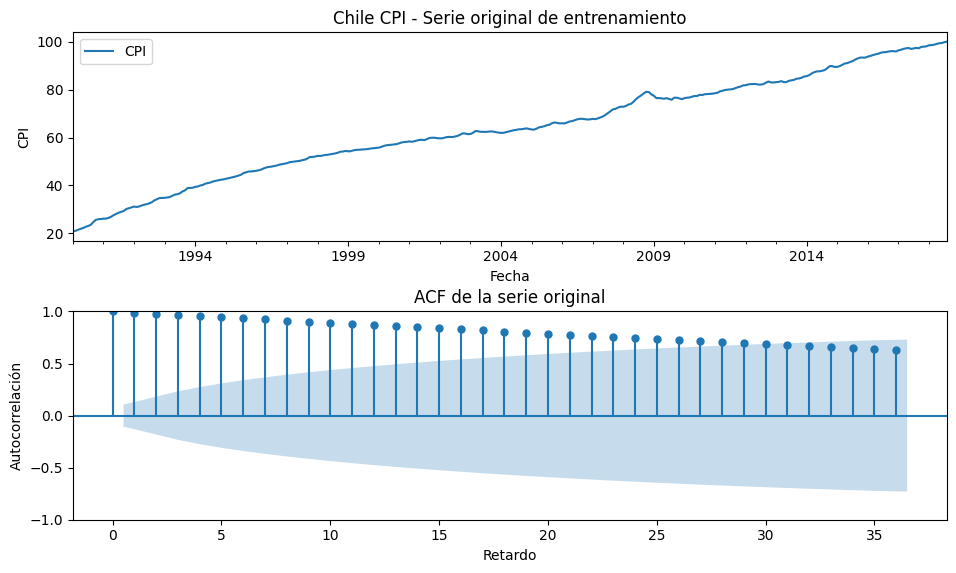

In [48]:
# =============================================================
# 3. ACF DE LA SERIE ORIGINAL DE TRAIN
# =============================================================

fig, axs = plt.subplots(2, figsize=(10, 6))
fig.tight_layout(pad=3)

train_ts.plot(ax=axs[0], legend=True)
axs[0].set_title("Chile CPI - Serie original de entrenamiento")
axs[0].set_xlabel("Fecha")
axs[0].set_ylabel("CPI")

plot_acf(train_ts, ax=axs[1], lags=36, title="")
axs[1].set_title("ACF de la serie original")
axs[1].set_xlabel("Retardo")
axs[1].set_ylabel("Autocorrelación")

plt.show()

The ACF decays slowly, which is a typical sign of non-stationarity due to trend.

**6.3. Regular differencing to remove trend**

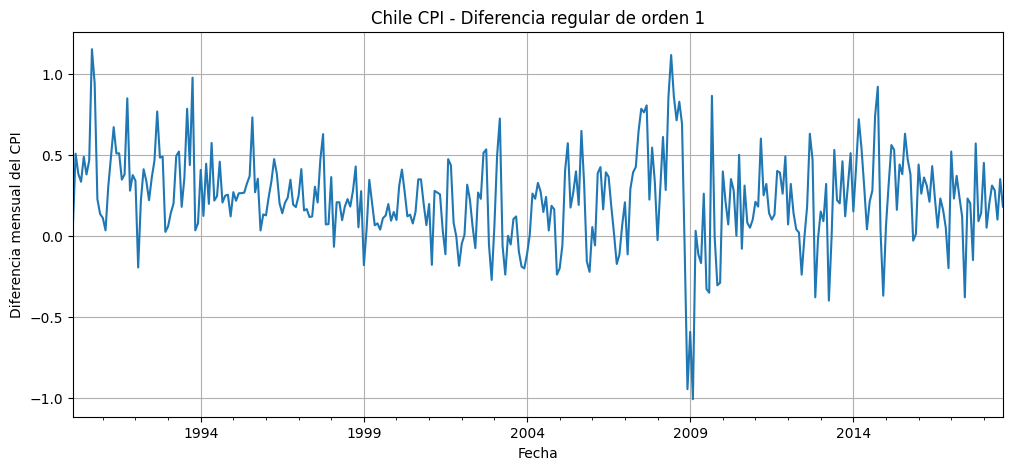

In [49]:
# =============================================================
# 4. DIFERENCIA REGULAR DE ORDEN 1
# =============================================================

train_d1 = train_ts.diff().dropna()
train_d1.name = "Chile CPI - First difference"

plt.figure(figsize=(12, 5))
train_d1.plot()
plt.title("Chile CPI - Diferencia regular de orden 1")
plt.xlabel("Fecha")
plt.ylabel("Diferencia mensual del CPI")
plt.grid(True)
plt.show()

<Figure size 1000x500 with 0 Axes>

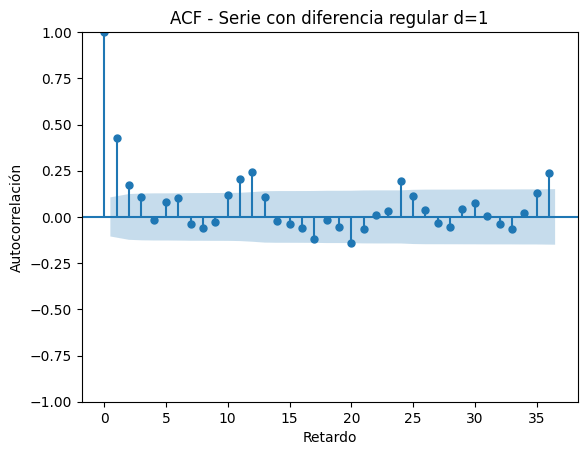

In [50]:
# ACF de la serie con diferencia regular
plt.figure(figsize=(10, 5))
plot_acf(train_d1, lags=36)
plt.title("ACF - Serie con diferencia regular d=1")
plt.xlabel("Retardo")
plt.ylabel("Autocorrelación")
plt.show()

Vemos que ya no hay tendencia, PERO si podemos apreciar cierta estacionalidad cada 12 meses como vimos incialmente en la fase exploratoria

**6.4. Seasonal differencing**

Como la serie es mensual, usamos: S=12

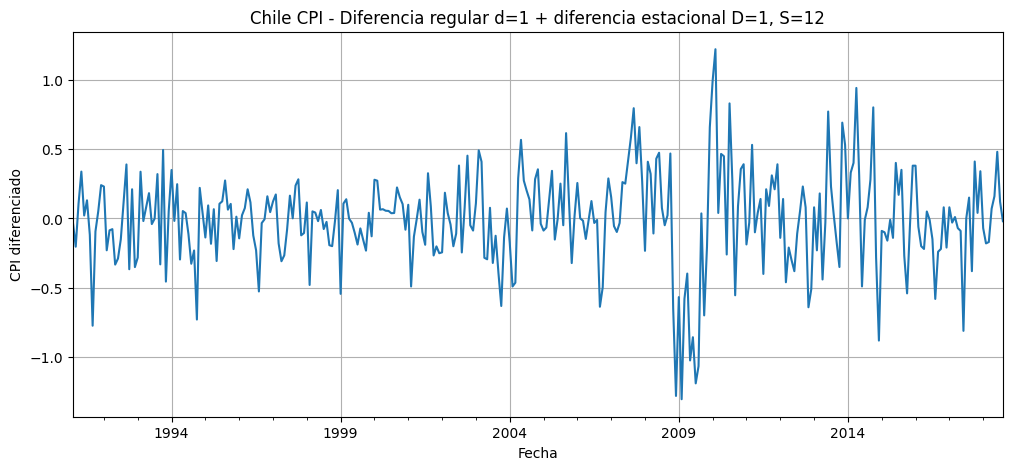

In [51]:
# =============================================================
# 5. DIFERENCIA ESTACIONAL CON S = 12
# =============================================================

S = 12

train_d1_D1 = train_d1.diff(S).dropna()
train_d1_D1.name = "Chile CPI - First diff + seasonal diff"

plt.figure(figsize=(12, 5))
train_d1_D1.plot()
plt.title("Chile CPI - Diferencia regular d=1 + diferencia estacional D=1, S=12")
plt.xlabel("Fecha")
plt.ylabel("CPI diferenciado")
plt.grid(True)
plt.show()

**6.5. Comprobar estacionariedad con ADF**

In [52]:
# =============================================================
# 6. TEST ADF SOBRE LA SERIE DIFERENCIADA
# =============================================================

def ADFtest(series, name=""):
    result = adfuller(series.dropna())
    
    print("====================================")
    print("ADF Test —", name)
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("Critical Values:")
    
    for key, value in result[4].items():
        print(f" {key}: {value}")
        
    print("====================================\n")

ADFtest(train_d1_D1, "Chile CPI d=1, D=1, S=12")

ADF Test — Chile CPI d=1, D=1, S=12
ADF Statistic: -5.543572683340033
p-value: 1.680360483497534e-06
Critical Values:
 1%: -3.4512146067362317
 5%: -2.870730188960711
 10%: -2.5716664849383113



The p-value is very small and the ADF statistic is more negative than the 1% critical value; therefore, the null hypothesis is rejected --> the series is stationary.

**6.6. ACF y PACF para elegir p, q, P y Q**

ACF/PACF general

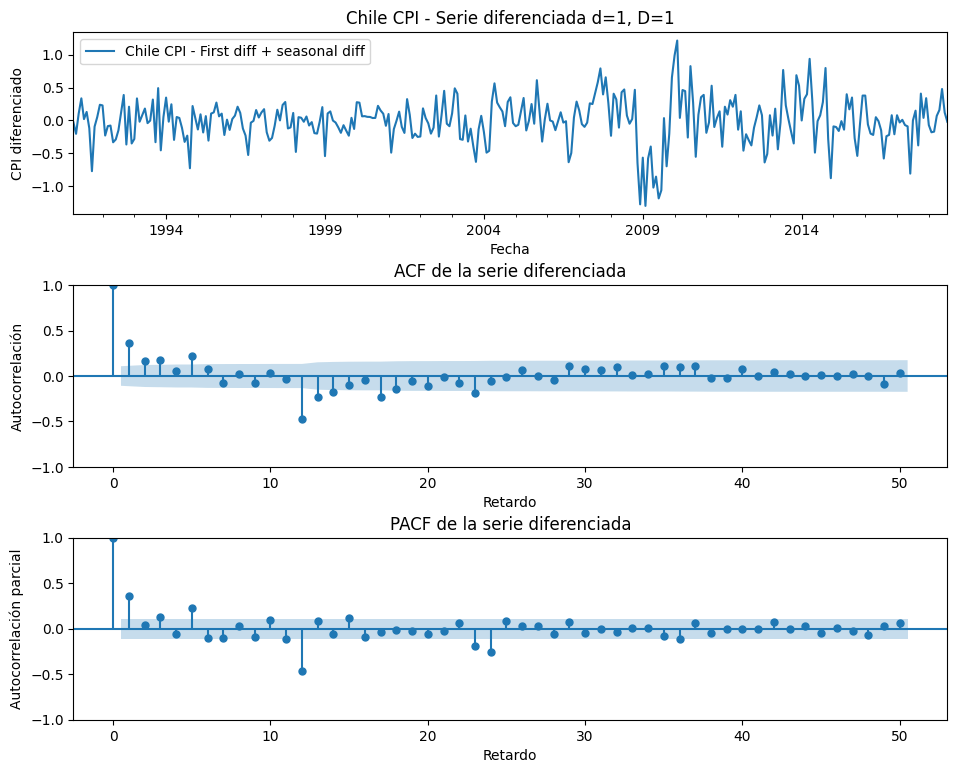

In [53]:
# =============================================================
# 7. ACF Y PACF DE LA SERIE DIFERENCIADA
# =============================================================

fig, axs = plt.subplots(3, figsize=(10, 8))
fig.tight_layout(pad=3)

train_d1_D1.plot(ax=axs[0], legend=True)
axs[0].set_title("Chile CPI - Serie diferenciada d=1, D=1")
axs[0].set_xlabel("Fecha")
axs[0].set_ylabel("CPI diferenciado")

plot_acf(train_d1_D1, ax=axs[1], lags=50, title="")
axs[1].set_title("ACF de la serie diferenciada")
axs[1].set_xlabel("Retardo")
axs[1].set_ylabel("Autocorrelación")

plot_pacf(train_d1_D1, ax=axs[2], lags=50, method="ywm", title="")
axs[2].set_title("PACF de la serie diferenciada")
axs[2].set_xlabel("Retardo")
axs[2].set_ylabel("Autocorrelación parcial")

plt.show()

**Non-seasonal terms: inspect up to S**

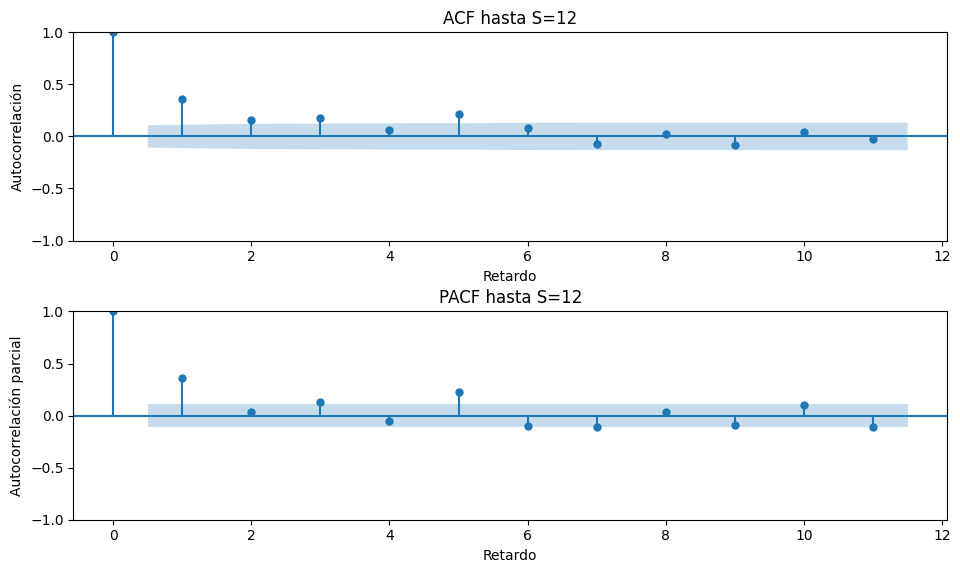

In [54]:
# =============================================================
# 8. ACF Y PACF HASTA S = 12
# =============================================================

fig, axs = plt.subplots(2, figsize=(10, 6))
fig.tight_layout(pad=3)

plot_acf(train_d1_D1, ax=axs[0], lags=11, title="")
axs[0].set_title("ACF hasta S=12")
axs[0].set_xlabel("Retardo")
axs[0].set_ylabel("Autocorrelación")

plot_pacf(train_d1_D1, ax=axs[1], lags=11, method="ywm", title="")
axs[1].set_title("PACF hasta S=12")
axs[1].set_xlabel("Retardo")
axs[1].set_ylabel("Autocorrelación parcial")

plt.show()

q can take values from 1 to 5, and p can also take values from 1 to 5.

**Seasonal terms: lags that are multiples of S**

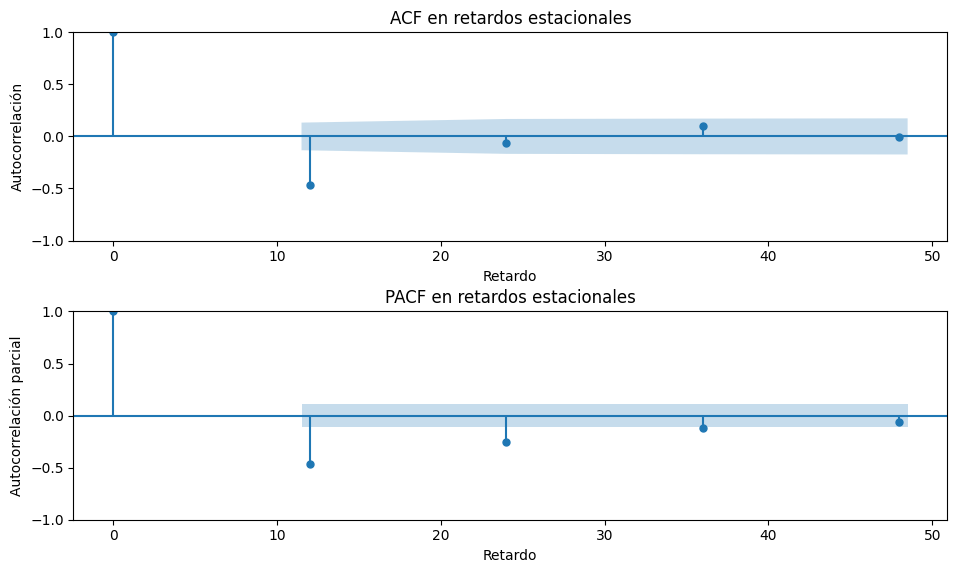

In [55]:
# =============================================================
# 9. ACF Y PACF EN RETARDOS ESTACIONALES
# =============================================================

fig, axs = plt.subplots(2, figsize=(10, 6))
fig.tight_layout(pad=3)

plot_acf(train_d1_D1, ax=axs[0], lags=np.arange(0, 49, 12), title="")
axs[0].set_title("ACF en retardos estacionales")
axs[0].set_xlabel("Retardo")
axs[0].set_ylabel("Autocorrelación")

plot_pacf(train_d1_D1, ax=axs[1], lags=np.arange(0, 49, 12), method="ywm", title="")
axs[1].set_title("PACF en retardos estacionales")
axs[1].set_xlabel("Retardo")
axs[1].set_ylabel("Autocorrelación parcial")

plt.show()

Q puede tomar el valor 1, P puede tomar el valor desde 1 hasta 3

**6.7. SARIMA model grid search according to AIC**

We now perform the grid search on the original training series, with differencing incorporated inside the model:

In [56]:
# =============================================================
# 10. GRID SEARCH SARIMA SEGÚN AIC
# =============================================================

rp = range(0, 5)   # p
rq = range(0, 5)   # q
rP = range(0, 3)   # P
rQ = range(0, 3)   # Q

d = 1
D = 1

resultados_aic = []

for p in rp:
    for q in rq:
        for P in rP:
            for Q in rQ:
                
                try:
                    model = ARIMA(
                        train_ts,
                        order=(p, d, q),
                        seasonal_order=(P, D, Q, S)
                    )
                    
                    fit = model.fit()
                    
                    print(
                        "Evaluating p=" + str(p) +
                        " q=" + str(q) +
                        " P=" + str(P) +
                        " Q=" + str(Q) +
                        " AIC=" + str(fit.aic)
                    )
                    
                    resultados_aic.append({
                        "p": p,
                        "d": d,
                        "q": q,
                        "P": P,
                        "D": D,
                        "Q": Q,
                        "S": S,
                        "AIC": fit.aic,
                        "BIC": fit.bic
                    })
                    
                except Exception as e:
                    print(
                        "Model failed for p=" + str(p) +
                        " q=" + str(q) +
                        " P=" + str(P) +
                        " Q=" + str(Q)
                    )

resultados_aic = pd.DataFrame(resultados_aic)
resultados_aic = resultados_aic.sort_values("AIC").reset_index(drop=True)

top10_aic = resultados_aic.head(10)

print("Top 10 models according to AIC:")
print(top10_aic)

Evaluating p=0 q=0 P=0 Q=0 AIC=228.95643979643782
Evaluating p=0 q=0 P=0 Q=1 AIC=77.14398277729595
Evaluating p=0 q=0 P=0 Q=2 AIC=77.94413297389843
Evaluating p=0 q=0 P=1 Q=0 AIC=148.07683173332555
Evaluating p=0 q=0 P=1 Q=1 AIC=77.78578393573625
Evaluating p=0 q=0 P=1 Q=2 AIC=80.02519949403812
Evaluating p=0 q=0 P=2 Q=0 AIC=104.40495411402276
Evaluating p=0 q=0 P=2 Q=1 AIC=78.9834919068627
Evaluating p=0 q=0 P=2 Q=2 AIC=81.76469245150656
Evaluating p=0 q=1 P=0 Q=0 AIC=188.51999571727526
Evaluating p=0 q=1 P=0 Q=1 AIC=23.26603159193545
Evaluating p=0 q=1 P=0 Q=2 AIC=24.99444742532335
Evaluating p=0 q=1 P=1 Q=0 AIC=90.87384643420535
Evaluating p=0 q=1 P=1 Q=1 AIC=24.921939127229784
Evaluating p=0 q=1 P=1 Q=2 AIC=27.210694122481975
Evaluating p=0 q=1 P=2 Q=0 AIC=57.764211170279914
Evaluating p=0 q=1 P=2 Q=1 AIC=24.29729222416087
Evaluating p=0 q=1 P=2 Q=2 AIC=24.68159874083271
Evaluating p=0 q=2 P=0 Q=0 AIC=190.1299218341464
Evaluating p=0 q=2 P=0 Q=1 AIC=22.89870620718746
Evaluating p=0

In [57]:
top20_aic = resultados_aic.head(20)

print("Top 20 models according to AIC:")
print(top20_aic)

Top 20 models according to AIC:
    p  d  q  P  D  Q   S        AIC        BIC
0   3  1  2  1  1  1  12   6.737109  37.154056
1   3  1  2  0  1  2  12   6.847446  37.264393
2   3  1  2  0  1  1  12   7.836821  34.451650
3   3  1  3  1  1  1  12   8.283704  42.502769
4   3  1  3  0  1  2  12   8.342727  42.561792
5   4  1  2  1  1  1  12   8.465677  42.684742
6   4  1  2  0  1  2  12   8.579392  42.798458
7   3  1  2  2  1  1  12   8.620468  42.839533
8   3  1  3  0  1  1  12   9.041383  39.458330
9   4  1  3  1  1  1  12   9.086507  47.107691
10  4  1  3  0  1  2  12   9.185829  47.207012
11  3  1  2  1  1  2  12   9.394166  43.613232
12  3  1  1  0  1  1  12   9.590622  32.403333
13  0  1  3  0  1  1  12  10.198352  29.208944
14  3  1  3  2  1  1  12  10.219830  48.241014
15  4  1  3  0  1  1  12  10.275089  44.494154
16  3  1  3  1  1  2  12  10.413462  48.434646
17  4  1  2  0  1  1  12  10.424009  40.840956
18  3  1  2  2  1  2  12  10.834676  48.855859
19  4  1  1  0  1  1  12  10

**6.8. Forecast sobre validation para los 10 mejores modelos**

We now evaluate the 10 best models according to AIC on the validation set.

In [58]:
# =============================================================
# 11. FUNCIÓN DE MÉTRICAS
# =============================================================

def forecasting_metrics(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_true - y_pred))
    mape = 100 * np.mean(np.abs((y_true - y_pred) / y_true))
    
    return mse, rmse, mae, mape

In [59]:
# =============================================================
# 12. EVALUAR TOP 10 EN VALIDATION
# =============================================================

resultados_validation = []
validation_forecasts = {}

for i, row in top20_aic.iterrows():
    
    p = int(row["p"])
    q = int(row["q"])
    P = int(row["P"])
    Q = int(row["Q"])
    
    model_name = f"SARIMA({p},{d},{q})x({P},{D},{Q},{S})"
    
    try:
        model = ARIMA(
            train_ts,
            order=(p, d, q),
            seasonal_order=(P, D, Q, S)
        )
        
        fit = model.fit()
        
        forecast_val = fit.forecast(steps=len(validation_ts))
        forecast_val.index = validation_ts.index
        forecast_val.name = model_name
        
        mse, rmse, mae, mape = forecasting_metrics(
            validation_ts.values,
            forecast_val.values
        )
        
        resultados_validation.append({
            "Modelo": model_name,
            "p": p,
            "d": d,
            "q": q,
            "P": P,
            "D": D,
            "Q": Q,
            "S": S,
            "AIC": row["AIC"],
            "BIC": row["BIC"],
            "MSE_validation": mse,
            "RMSE_validation": rmse,
            "MAE_validation": mae,
            "MAPE_validation": mape
        })
        
        validation_forecasts[model_name] = forecast_val
        
    except Exception as e:
        print(f"Error evaluating {model_name}: {e}")

resultados_validation = pd.DataFrame(resultados_validation)
resultados_validation = resultados_validation.sort_values("RMSE_validation").reset_index(drop=True)

print("Models ordered by RMSE on validation:")
print(resultados_validation)

Models ordered by RMSE on validation:
                      Modelo  p  d  q  P  D  Q   S        AIC        BIC  \
0   SARIMA(4,1,2)x(0,1,2,12)  4  1  2  0  1  2  12   8.579392  42.798458   
1   SARIMA(4,1,2)x(1,1,1,12)  4  1  2  1  1  1  12   8.465677  42.684742   
2   SARIMA(3,1,3)x(1,1,1,12)  3  1  3  1  1  1  12   8.283704  42.502769   
3   SARIMA(3,1,2)x(0,1,2,12)  3  1  2  0  1  2  12   6.847446  37.264393   
4   SARIMA(4,1,3)x(1,1,1,12)  4  1  3  1  1  1  12   9.086507  47.107691   
5   SARIMA(3,1,2)x(1,1,1,12)  3  1  2  1  1  1  12   6.737109  37.154056   
6   SARIMA(3,1,2)x(2,1,1,12)  3  1  2  2  1  1  12   8.620468  42.839533   
7   SARIMA(3,1,3)x(0,1,2,12)  3  1  3  0  1  2  12   8.342727  42.561792   
8   SARIMA(4,1,3)x(0,1,2,12)  4  1  3  0  1  2  12   9.185829  47.207012   
9   SARIMA(3,1,3)x(2,1,1,12)  3  1  3  2  1  1  12  10.219830  48.241014   
10  SARIMA(4,1,2)x(0,1,1,12)  4  1  2  0  1  1  12  10.424009  40.840956   
11  SARIMA(3,1,2)x(2,1,2,12)  3  1  2  2  1  2  12

**6.10. Final model selection**

Primero seleccionamos el mejor por RMSE:

In [60]:
# =============================================================
# 14. MODELO CON MENOR RMSE EN VALIDATION
# =============================================================

best_by_rmse = resultados_validation.iloc[0]

print("Best model according to RMSE on validation:")
print(best_by_rmse)

Best model according to RMSE on validation:
Modelo             SARIMA(4,1,2)x(0,1,2,12)
p                                         4
d                                         1
q                                         2
P                                         0
D                                         1
Q                                         2
S                                        12
AIC                                8.579392
BIC                               42.798458
MSE_validation                     0.117566
RMSE_validation                     0.34288
MAE_validation                     0.250337
MAPE_validation                    0.241748
Name: 0, dtype: object


However, the final selection must be reasoned. It is not always advisable to choose the most complex model if a simpler one has a similar RMSE and AIC.

Although the SARIMA(4,1,2)x(0,1,2,12) model obtained the lowest RMSE on validation, the improvement over simpler models was negligible. Therefore, following a parsimony criterion, SARIMA(3,1,2)x(1,1,1,12) was selected as the final specification. This model keeps an almost equivalent RMSE, has lower AIC and BIC, and slightly improves MAE and MAPE. It is also more suitable for a future rolling one-step-ahead evaluation, where the model must be refitted repeatedly over time.

In [61]:
# =============================================================
# 15. SELECCIÓN MANUAL DEL MODELO FINAL
# =============================================================

# Por defecto seleccionamos el mejor por RMSE.
# Tambien podemos mirar el top 5 y elegir manualmente según AIC, BIC, o incluso la intuición sobre la serie.

selected_p = 3
selected_q = 2
selected_P = 1
selected_Q = 1

print("Selected model:")
print(f"SARIMA({selected_p},{d},{selected_q})x({selected_P},{D},{selected_Q},{S})")

Selected model:
SARIMA(3,1,2)x(1,1,1,12)


**6.11. Residual analysis**

Ajustamos el modelo elegido sobre train

In [62]:
# =============================================================
# 16. AJUSTAR MODELO SELECCIONADO SOBRE TRAIN
# =============================================================

selected_model = ARIMA(
    train_ts,
    order=(selected_p, d, selected_q),
    seasonal_order=(selected_P, D, selected_Q, S)
)

selected_fit = selected_model.fit()

print(selected_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                CPI   No. Observations:                  344
Model:             ARIMA(3, 1, 2)x(1, 1, [1], 12)   Log Likelihood                   4.631
Date:                            Sun, 10 May 2026   AIC                              6.737
Time:                                    23:56:09   BIC                             37.154
Sample:                                01-01-1990   HQIC                            18.869
                                     - 08-01-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9138      0.074    -12.425      0.000      -1.058      -0.770
ar.L2         -0.2657      0.076   

Time plot of residuals, ACF and ACS histogram

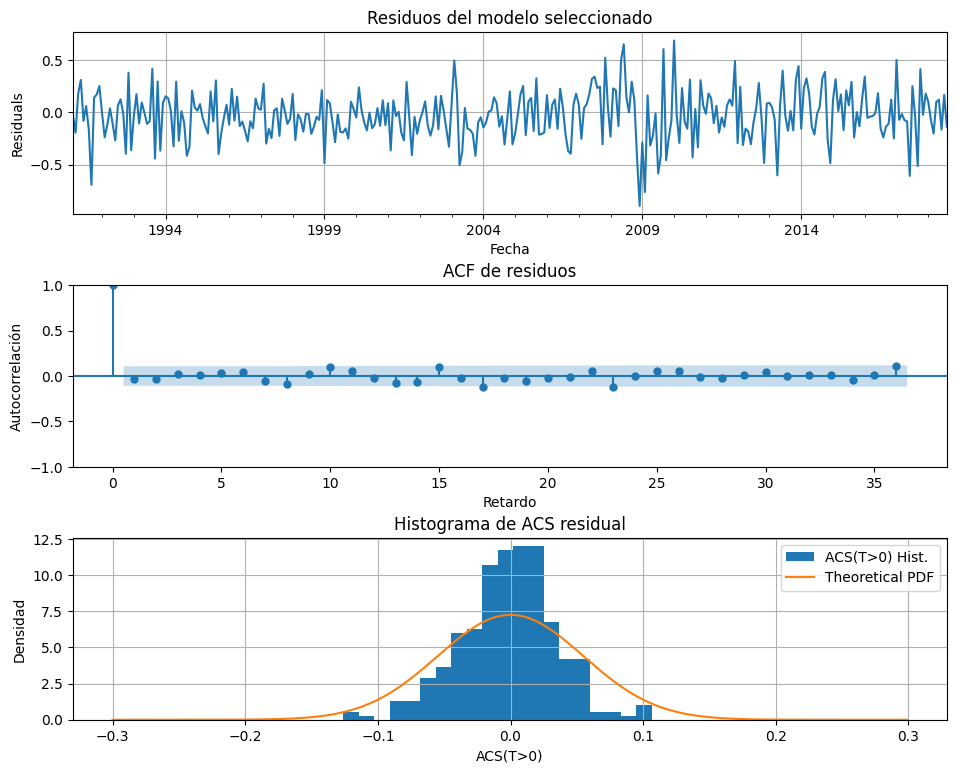

In [63]:
# =============================================================
# 17. ANÁLISIS DE RESIDUOS
# =============================================================

# Quitamos los primeros residuos afectados por diferenciación regular y estacional
res = selected_fit.resid[(d + S * D):].dropna()

fig, axs = plt.subplots(3, figsize=(10, 8))
fig.tight_layout(pad=3)

# 1. Residual time plot
res.plot(ax=axs[0])
axs[0].set_title("Residuos del modelo seleccionado")
axs[0].set_xlabel("Fecha")
axs[0].set_ylabel("Residuals")
axs[0].grid(True)

# 2. Residual ACF
plot_acf(res, ax=axs[1], title="", lags=36)
axs[1].set_title("ACF de residuos")
axs[1].set_xlabel("Retardo")
axs[1].set_ylabel("Autocorrelación")

# 3. Histogram of residual ACS
max_lag = min(500, len(res) - 1)
ac_res = acf(res, nlags=max_lag, fft=False)

axs[2].hist(ac_res[1:], bins=20, density=True, label="ACS(T>0) Hist.")

N = res.size
rg = np.arange(-0.3, 0.3, 0.001)
pdf = spyst.norm.pdf(rg, 0, 1 / np.sqrt(N))

axs[2].plot(rg, pdf, label="Theoretical PDF")
axs[2].set_title("Histograma de ACS residual")
axs[2].set_xlabel("ACS(T>0)")
axs[2].set_ylabel("Densidad")
axs[2].legend()
axs[2].grid(True)

plt.show()

The residual analysis indicates that the selected model is adequate. The residuals fluctuate around zero, show no clear trend or seasonality, and the residual ACF shows that almost all autocorrelations lie within the confidence bands. In addition, the histogram of residual autocorrelations is centered around zero and reasonably close to the theoretical distribution. Although there are some isolated peaks, especially around 2008-2009, these seem to correspond to specific shocks rather than to a poor model specification. Therefore, the model correctly captures the main temporal structure of the series.

**6.12. Reentrenar con train + validation y evaluar en test**

Once the model has been chosen, we refit it using train_validation and evaluate it once on test.

In [64]:
# =============================================================
# 18. REAJUSTAR MODELO FINAL CON TRAIN + VALIDATION
# =============================================================

final_model = ARIMA(
    train_validation_ts,
    order=(selected_p, d, selected_q),
    seasonal_order=(selected_P, D, selected_Q, S)
)

final_fit = final_model.fit()

forecast_test = final_fit.forecast(steps=len(test_ts))
forecast_test.index = test_ts.index
forecast_test.name = "SARIMA forecast"

print(final_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                CPI   No. Observations:                  368
Model:             ARIMA(3, 1, 2)x(1, 1, [1], 12)   Log Likelihood                   6.662
Date:                            Sun, 10 May 2026   AIC                              2.677
Time:                                    23:56:11   BIC                             33.654
Sample:                                01-01-1990   HQIC                            15.000
                                     - 08-01-2020                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9232      0.065    -14.207      0.000      -1.051      -0.796
ar.L2         -0.2824      0.070   

In [65]:
# =============================================================
# 19. MÉTRICAS FINALES EN TEST
# =============================================================

MSE_test, RMSE_test, MAE_test, MAPE_test = forecasting_metrics(
    test_ts.values,
    forecast_test.values
)

print("Final metrics on test:")
print("MSE  =", MSE_test)
print("RMSE =", RMSE_test)
print("MAE  =", MAE_test)
print("MAPE =", MAPE_test)

Final metrics on test:
MSE  = 46.79644321231416
RMSE = 6.840792586558531
MAE  = 5.046457209295823
MAPE = 4.269885169135627


In [66]:
# =============================================================
# GUARDAR MÉTRICAS FINALES DEL MODELO SARIMA EN TEST
# =============================================================

sarima_test_metrics = pd.DataFrame([{
    "Modelo": f"SARIMA({selected_p},{d},{selected_q})x({selected_P},{D},{selected_Q},{S})",
    "MSE_test": MSE_test,
    "RMSE_test": RMSE_test,
    "MAE_test": MAE_test,
    "MAPE_test": MAPE_test,
    "AIC_train": selected_fit.aic,
    "BIC_train": selected_fit.bic,
    "AIC_train_validation": final_fit.aic,
    "BIC_train_validation": final_fit.bic
}])

sarima_test_metrics.to_csv(
    "chile_cpi_sarima_test_metrics.csv",
    index=False
)

print("Final SARIMA metrics saved successfully.")

Final SARIMA metrics saved successfully.


The model has quantitatively acceptable performance on test, with a low/moderate mean percentage error. However, the RMSE being higher than the MAE indicates that there are specific months with relatively high errors, especially when the real series increases more strongly.

**6.13. General plot of the final forecast**

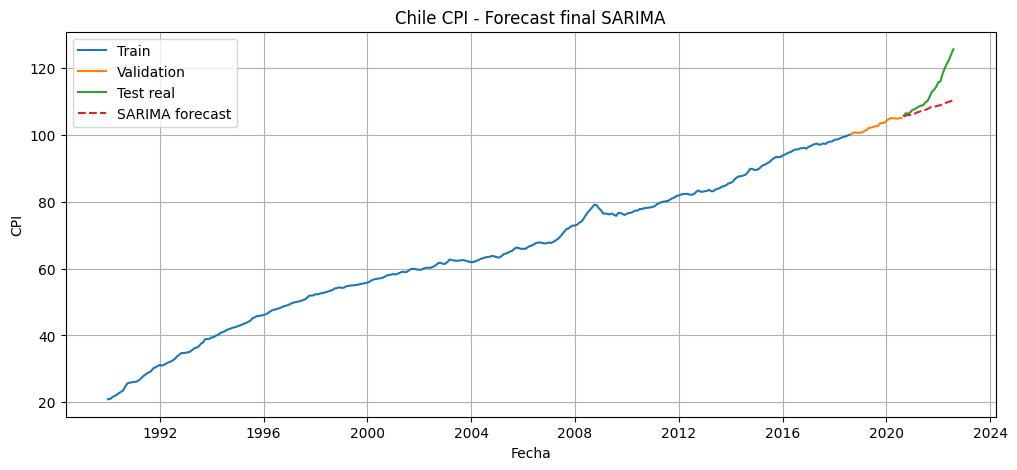

In [67]:
# =============================================================
# 20. GRÁFICO GENERAL: TRAIN + VALIDATION + TEST + FORECAST
# =============================================================

plt.figure(figsize=(12, 5))

plt.plot(train_ts.index, train_ts, label="Train")
plt.plot(validation_ts.index, validation_ts, label="Validation")
plt.plot(test_ts.index, test_ts, label="Test real")
plt.plot(forecast_test.index, forecast_test, linestyle="--", label="SARIMA forecast")

plt.title("Chile CPI - Forecast final SARIMA")
plt.xlabel("Fecha")
plt.ylabel("CPI")
plt.legend()
plt.grid(True)
plt.show()

The SARIMA forecast, shown as a dashed red line, follows the general increasing direction of the series, but it cannot capture the strong CPI acceleration in the final period.

That is:

- The model predicts a smooth increase.
- The real test series rises much faster.
- Therefore, the model systematically underestimates the CPI during much of the test period, especially toward 2021-2022.

This does not necessarily mean that the model is poorly fitted. In fact, the training residuals looked fairly correct. What happens is that the test period has a more explosive or accelerated behavior that was not as present in the training data. A SARIMA model trained on historical dynamics tends to extrapolate past patterns, but it may fall short when recent slope changes or inflationary shocks occur.

This raises the possibility that an Exponential Smoothing model with a high alpha could work better for the test data.

**6.14. Zoomed plot: real test versus forecast**

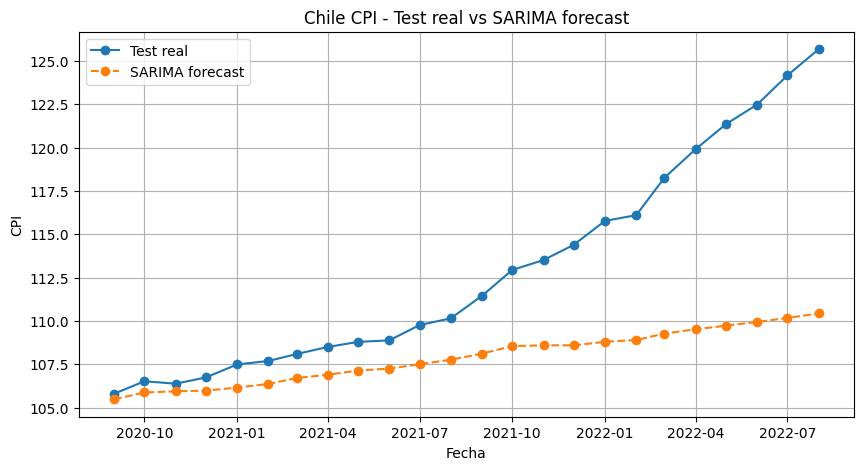

In [68]:
# =============================================================
# 21. TEST REAL VS FORECAST
# =============================================================

plt.figure(figsize=(10, 5))

plt.plot(test_ts.index, test_ts, marker="o", label="Test real")
plt.plot(forecast_test.index, forecast_test, marker="o", linestyle="--", label="SARIMA forecast")

plt.title("Chile CPI - Test real vs SARIMA forecast")
plt.xlabel("Fecha")
plt.ylabel("CPI")
plt.legend()
plt.grid(True)
plt.show()

*CONCLUSION*: The SARIMA model captured the general increasing direction of the series, but underestimated the acceleration observed in the test period. This suggests that a method more sensitive to recent changes in level and trend could improve predictive performance. Therefore, Exponential Smoothing is also considered. In particular, the Holt-Winters or Triple Exponential Smoothing model is suitable because the CPI series has trend and seasonality. Higher smoothing parameters may give more weight to recent observations and allow faster adaptation to changes in inflation dynamics.

**6.15. Empirical intervals for the SARIMA forecast**

The idea is:

1. Choose a horizon H = len(test_ts), in our case 24 months.
2. Perform a rolling/expanding procedure on historical data.
3. For each time origin, fit the same selected SARIMA model.
4. Forecast H steps ahead.
5. Store errors by horizon: 1-month-ahead error, 2-month-ahead error, ..., 24-month-ahead error.
6. Compute the empirical variance of the errors for each horizon.
7. Build the interval.

To estimate empirical errors, we use only data before the test set. That is, we use "train_validation_ts" as the available history to build rolling errors.

In [69]:
# =============================================================
# 23. INTERVALOS EMPÍRICOS DE PREDICCIÓN - SARIMA
# =============================================================

H = len(test_ts)  # horizonte final de predicción: 24 meses

# Serie histórica disponible antes del test
historical_ts = train_validation_ts.copy()

# Número mínimo de observaciones para empezar a ajustar modelos
# Dejamos suficiente historia para que el modelo pueda estimarse razonablemente.
min_train_size = 120  # 10 años de datos mensuales

# Aquí guardamos errores por horizonte:
# errors_by_h[0] = errores de predicción a 1 mes
# errors_by_h[1] = errores de predicción a 2 meses
# ...
errors_by_h = [[] for _ in range(H)]

for start in range(min_train_size, len(historical_ts) - H + 1):
    
    rolling_train = historical_ts.iloc[:start]
    rolling_real_future = historical_ts.iloc[start:start + H]
    
    try:
        rolling_model = ARIMA(
            rolling_train,
            order=(selected_p, d, selected_q),
            seasonal_order=(selected_P, D, selected_Q, S)
        )
        
        rolling_fit = rolling_model.fit()
        
        rolling_forecast = rolling_fit.forecast(steps=H)
        
        # Guardar errores por horizonte
        for h in range(H):
            error_h = rolling_real_future.iloc[h] - rolling_forecast.iloc[h]
            errors_by_h[h].append(error_h)
            
    except Exception as e:
        # Si algún ajuste falla, lo ignoramos para no romper todo el proceso
        pass

**Compute empirical variance by horizon**

In [70]:
# =============================================================
# 24. VARIANZA EMPÍRICA POR HORIZONTE
# =============================================================

var_h = np.zeros(H)

for h in range(H):
    var_h[h] = np.var(errors_by_h[h], ddof=1)

print("Empirical error variances by horizon:")
print(var_h)

print("Number of errors used by horizon:")
print([len(errors_by_h[h]) for h in range(H)])

Empirical error variances by horizon:
[ 0.07443932  0.23542278  0.43636808  0.69598783  0.98447754  1.32388595
  1.70799595  2.08766962  2.47574926  2.86644313  3.31170637  3.81309942
  4.39818321  5.01172393  5.61706859  6.26596224  6.93462771  7.56735675
  8.20139599  8.84524635  9.47427077 10.11439699 10.76143567 11.37124775]
Number of errors used by horizon:
[225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225]


**Construir intervalos al 95 %**

We use the final forecast that had already been computed on test, "forecast_test".

In [71]:
# =============================================================
# 25. CONSTRUIR INTERVALOS DE PREDICCIÓN AL 95 %
# =============================================================

z = 1.96

lower = forecast_test.values - z * np.sqrt(var_h)
upper = forecast_test.values + z * np.sqrt(var_h)

lowerTS = pd.Series(lower, index=test_ts.index, name="Lower PI")
upperTS = pd.Series(upper, index=test_ts.index, name="Upper PI")

**Final plot with empirical intervals**

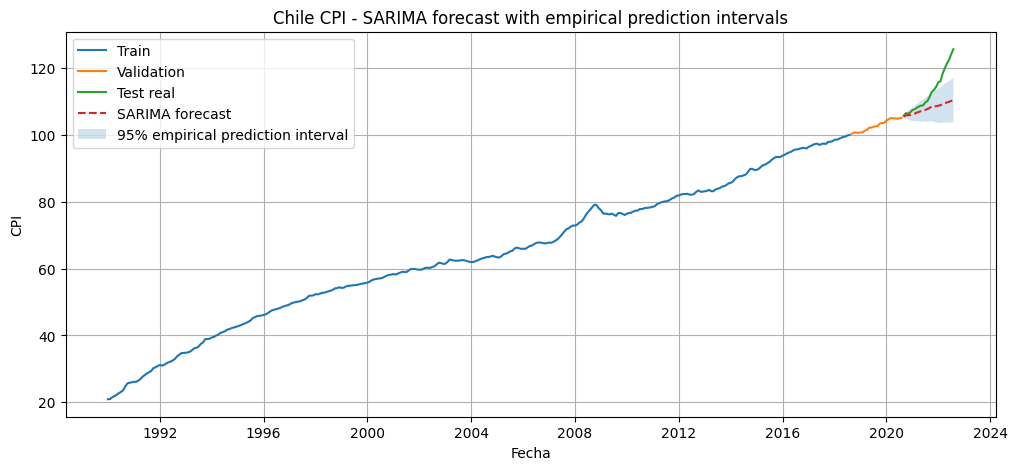

In [72]:
# =============================================================
# 26. GRÁFICO FINAL CON INTERVALOS EMPÍRICOS
# =============================================================

plt.figure(figsize=(12, 5))

plt.plot(train_ts.index, train_ts, label="Train")
plt.plot(validation_ts.index, validation_ts, label="Validation")
plt.plot(test_ts.index, test_ts, label="Test real")
plt.plot(forecast_test.index, forecast_test, linestyle="--", label="SARIMA forecast")

plt.fill_between(
    test_ts.index,
    lowerTS.values,
    upperTS.values,
    alpha=0.2,
    label="95% empirical prediction interval"
)

plt.title("Chile CPI - SARIMA forecast with empirical prediction intervals")
plt.xlabel("Fecha")
plt.ylabel("CPI")
plt.legend()
plt.grid(True)
plt.show()

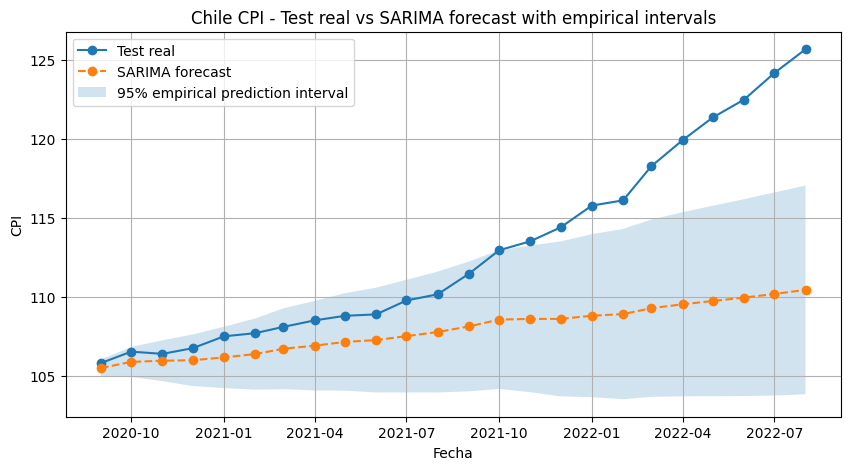

In [73]:
# =============================================================
# 27. TEST REAL VS FORECAST + INTERVALOS
# =============================================================

plt.figure(figsize=(10, 5))

plt.plot(test_ts.index, test_ts, marker="o", label="Test real")
plt.plot(forecast_test.index, forecast_test, marker="o", linestyle="--", label="SARIMA forecast")

plt.fill_between(
    test_ts.index,
    lowerTS.values,
    upperTS.values,
    alpha=0.2,
    label="95% empirical prediction interval"
)

plt.title("Chile CPI - Test real vs SARIMA forecast with empirical intervals")
plt.xlabel("Fecha")
plt.ylabel("CPI")
plt.legend()
plt.grid(True)
plt.show()

**Comprobar cobertura del intervalo**

In [74]:
# =============================================================
# 28. COBERTURA DEL INTERVALO EN TEST
# =============================================================

inside_interval = (test_ts.values >= lowerTS.values) & (test_ts.values <= upperTS.values)

coverage = 100 * np.mean(inside_interval)

print("Coverage of empirical 95% prediction interval in test:", coverage, "%")

interval_results = pd.DataFrame({
    "Real_CPI": test_ts,
    "Forecast_CPI": forecast_test,
    "Lower_PI": lowerTS,
    "Upper_PI": upperTS,
    "Inside_PI": inside_interval
})

print(interval_results)

Coverage of empirical 95% prediction interval in test: 54.166666666666664 %
            Real_CPI  Forecast_CPI    Lower_PI    Upper_PI  Inside_PI
Fecha                                                                
2020-09-01    105.80    105.484553  104.949795  106.019311       True
2020-10-01    106.52    105.872772  104.921772  106.823772       True
2020-11-01    106.38    105.943699  104.648959  107.238439       True
2020-12-01    106.74    105.976795  104.341648  107.611943       True
2021-01-01    107.49    106.155236  104.210508  108.099965       True
2021-02-01    107.69    106.366319  104.111138  108.621500       True
2021-03-01    108.09    106.703850  104.142320  109.265380       True
2021-04-01    108.50    106.898456  104.066497  109.730415       True
2021-05-01    108.79    107.134828  104.050863  110.218792       True
2021-06-01    108.88    107.254038  103.935646  110.572431       True
2021-07-01    109.76    107.503058  103.936232  111.069885       True
2021-08-01    

Interpretation:

- If coverage is close to 95%, the interval is very well calibrated.
- If it is much lower, the interval is too narrow or the test period contains a strong structural change.
- If it is 100%, the interval is conservative, but useful.
- If the last real values fall above the upper bound, this confirms that the model did not capture the final inflationary acceleration.

**Guardar resultados**

In [75]:
# =============================================================
# 29. GUARDAR RESULTADOS CON INTERVALOS
# =============================================================

interval_results.to_csv("chile_cpi_sarima_test_forecast_empirical_intervals.csv")

interval_metrics = pd.DataFrame([{
    "Modelo": f"SARIMA({selected_p},{d},{selected_q})x({selected_P},{D},{selected_Q},{S})",
    "Interval_type": "Empirical 95%",
    "Coverage_test_percent": coverage
}])

interval_metrics.to_csv("chile_cpi_sarima_empirical_interval_coverage.csv", index=False)

print("Empirical intervals saved successfully.")

Empirical intervals saved successfully.


In [76]:
print(f"SARIMA({selected_p},{d},{selected_q})x({selected_P},{D},{selected_Q},{S})")

SARIMA(3,1,2)x(1,1,1,12)


### **7. Exponential Smoothing Forecasting**

**7.0. Cargar datos originales**

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error

# =============================================================
# 1. CARGAR DATASETS YA DIVIDIDOS
# =============================================================

train = pd.read_csv("chile_cpi_train.csv")
validation = pd.read_csv("chile_cpi_validation.csv")
test = pd.read_csv("chile_cpi_test.csv")
train_validation = pd.read_csv("chile_cpi_train_validation.csv")

for df_aux in [train, validation, test, train_validation]:
    df_aux["Fecha"] = pd.to_datetime(df_aux["Fecha"])
    df_aux.set_index("Fecha", inplace=True)

train_ts = train["CPI"]
validation_ts = validation["CPI"]
test_ts = test["CPI"]
train_validation_ts = train_validation["CPI"]

print("Train:", train_ts.index.min(), "->", train_ts.index.max(), "| n =", len(train_ts))
print("Validation:", validation_ts.index.min(), "->", validation_ts.index.max(), "| n =", len(validation_ts))
print("Test:", test_ts.index.min(), "->", test_ts.index.max(), "| n =", len(test_ts))

Train: 1990-01-01 00:00:00 -> 2018-08-01 00:00:00 | n = 344
Validation: 2018-09-01 00:00:00 -> 2020-08-01 00:00:00 | n = 24
Test: 2020-09-01 00:00:00 -> 2022-08-01 00:00:00 | n = 24


**7.1. Implementar TES**

TES incorporates level + trend + seasonality, which is suitable for our dataset. The additive model initially makes more sense. Even so, we can also test the multiplicative model and keep the one with the best RMSE on validation.

In [78]:
# =============================================================
# 5. TRIPLE EXPONENTIAL SMOOTHING / HOLT-WINTERS
# =============================================================

def myTES(serie, alpha, gamma, delta, S, mtype="a", NstepAh=0):
    serie = pd.Series(serie).astype(float)
    N = serie.size
    
    L = np.zeros(N + NstepAh)
    T = np.zeros(N + NstepAh)
    I = np.zeros(N + NstepAh)
    s = np.zeros(N + NstepAh)
    
    # Inicialización
    L[S-1] = np.mean(serie.iloc[0:S])
    
    bsum = 0
    for i in range(S):
        bsum += (serie.iloc[S+i] - serie.iloc[i]) / S
    
    T[S-1] = (1 / S) * bsum
    
    for i in range(S):
        if mtype == "m":
            I[i] = serie.iloc[i] / L[S-1]
        else:
            I[i] = serie.iloc[i] - L[S-1]
    
    s[S-1] = L[S-1]
    
    # Actualización
    for n in range(S, N):
        if mtype == "m":
            L[n] = alpha * (serie.iloc[n] / I[n-S]) + (1 - alpha) * (L[n-1] + T[n-1])
        else:
            L[n] = alpha * (serie.iloc[n] - I[n-S]) + (1 - alpha) * (L[n-1] + T[n-1])
        
        T[n] = gamma * (L[n] - L[n-1]) + (1 - gamma) * T[n-1]
        
        if mtype == "m":
            I[n] = delta * (serie.iloc[n] / L[n]) + (1 - delta) * I[n-S]
            s[n] = (L[n] + T[n]) * I[n]
        else:
            I[n] = delta * (serie.iloc[n] - L[n]) + (1 - delta) * I[n-S]
            s[n] = L[n] + T[n] + I[n]
    
    # Forecast
    if NstepAh > 0:
        h = 1
        for n in range(N, N + NstepAh):
            seasonal_index = N - S + np.mod(h - 1, S)
            
            if mtype == "m":
                s[n] = (L[N-1] + h * T[N-1]) * I[seasonal_index]
            else:
                s[n] = L[N-1] + h * T[N-1] + I[seasonal_index]
            
            h += 1
    
    return s

**7.3. Grid search en validation**

In [79]:
# =============================================================
# 6. GRID SEARCH PARA SES, DES Y TES
# =============================================================

S = 12
Nstep = len(validation_ts)

step = 0.05
alphas = np.arange(step, 1, step)
gammas = np.arange(step, 1, step)
deltas = np.arange(step, 1, step)

results_es = []
validation_forecasts_es = {}


# -------------------------
# TES aditivo y multiplicativo
# -------------------------
for mtype in ["a", "m"]:
    for alpha in alphas:
        for gamma in gammas:
            for delta in deltas:
                
                try:
                    s = myTES(
                        train_ts,
                        alpha,
                        gamma,
                        delta,
                        S=S,
                        mtype=mtype,
                        NstepAh=Nstep
                    )
                    
                    forecast = s[-Nstep:]
                    
                    mse, rmse, mae, mape = forecasting_metrics(validation_ts.values, forecast)
                    
                    model_name = f"TES-{mtype}(alpha={alpha:.1f}, gamma={gamma:.1f}, delta={delta:.1f})"
                    
                    results_es.append({
                        "Model": "TES",
                        "Model_name": model_name,
                        "alpha": alpha,
                        "gamma": gamma,
                        "delta": delta,
                        "mtype": mtype,
                        "MSE_validation": mse,
                        "RMSE_validation": rmse,
                        "MAE_validation": mae,
                        "MAPE_validation": mape
                    })
                    
                    validation_forecasts_es[model_name] = pd.Series(
                        forecast,
                        index=validation_ts.index,
                        name=model_name
                    )
                
                except Exception as e:
                    pass

results_es = pd.DataFrame(results_es)
results_es = results_es.sort_values("RMSE_validation").reset_index(drop=True)

print("Best Exponential Smoothing models according to RMSE on validation:")
print(results_es.head(20))

Best Exponential Smoothing models according to RMSE on validation:
   Model                              Model_name  alpha  gamma  delta mtype  \
0    TES  TES-m(alpha=0.2, gamma=0.2, delta=0.3)   0.20   0.20   0.30     m   
1    TES  TES-m(alpha=0.2, gamma=0.2, delta=0.4)   0.20   0.20   0.35     m   
2    TES  TES-m(alpha=0.2, gamma=0.2, delta=0.2)   0.20   0.20   0.25     m   
3    TES  TES-m(alpha=0.2, gamma=0.2, delta=0.2)   0.20   0.20   0.20     m   
4    TES  TES-a(alpha=0.1, gamma=0.4, delta=0.2)   0.10   0.40   0.15     a   
5    TES  TES-a(alpha=0.1, gamma=0.4, delta=0.2)   0.10   0.40   0.20     a   
6    TES  TES-m(alpha=0.2, gamma=0.2, delta=0.2)   0.15   0.25   0.20     m   
7    TES  TES-m(alpha=0.2, gamma=0.2, delta=0.2)   0.15   0.25   0.15     m   
8    TES  TES-a(alpha=0.2, gamma=0.2, delta=0.5)   0.25   0.20   0.45     a   
9    TES  TES-m(alpha=0.2, gamma=0.2, delta=0.2)   0.15   0.25   0.25     m   
10   TES  TES-m(alpha=0.2, gamma=0.2, delta=0.5)   0.25   0.20  

**7.4. Seleccionar mejor modelo ES**

In [80]:
# =============================================================
# 7. SELECCIÓN DEL MEJOR MODELO ES
# =============================================================

best_es = results_es.iloc[0]

print("Best ES model:")
print(best_es)

selected_es_model = best_es["Model"]
selected_alpha = best_es["alpha"]
selected_gamma = best_es["gamma"]
selected_delta = best_es["delta"]
selected_mtype = best_es["mtype"]

print("Chosen model:", selected_es_model)
print("alpha:", selected_alpha)
print("gamma:", selected_gamma)
print("delta:", selected_delta)
print("mtype:", selected_mtype)

Best ES model:
Model                                                 TES
Model_name         TES-m(alpha=0.2, gamma=0.2, delta=0.3)
alpha                                                 0.2
gamma                                                 0.2
delta                                                 0.3
mtype                                                   m
MSE_validation                                   0.086204
RMSE_validation                                  0.293606
MAE_validation                                   0.220448
MAPE_validation                                  0.213933
Name: 0, dtype: object
Chosen model: TES
alpha: 0.2
gamma: 0.2
delta: 0.3
mtype: m


We can see that the best model is multiplicative, the opposite of what we initially expected. The results also indicate that low values should be used for alpha, gamma and beta. However, as seen in the previous section, a higher parameter combination would be more convenient so that the model can adapt correctly to the acceleration that occurs in the test data compared with the validation data.

About the low parameters:

- alpha = 0.2: the level is updated smoothly; it does not react abruptly to the last observation.
- gamma = 0.2: the trend is also updated smoothly.
- delta = 0.3: seasonality adapts somewhat more, but remains moderate.

In other words, the model is learning a stable and smooth dynamic, which is exactly what was observed in train + validation.

**7.5. Plot of the best models on validation**

To avoid overcrowding the plot, we show only the 5 best models.

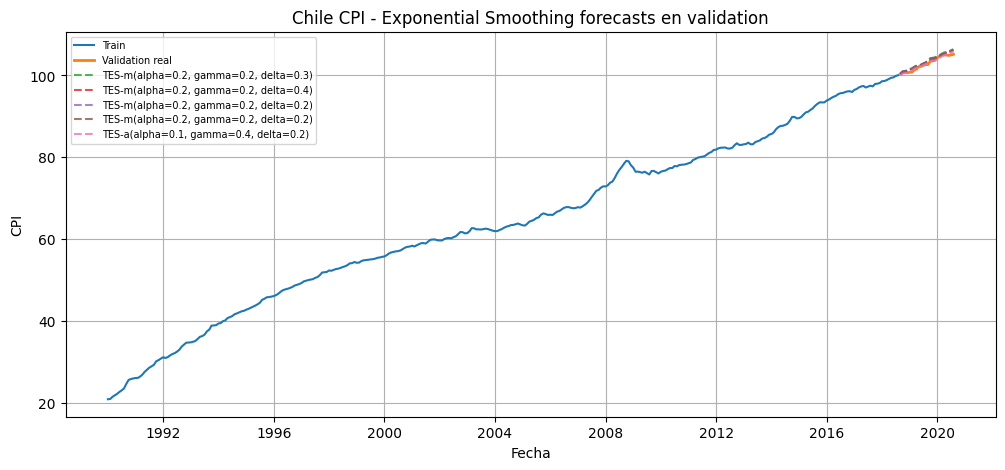

In [81]:
# =============================================================
# 8. GRÁFICO DE LOS 5 MEJORES MODELOS EN VALIDATION
# =============================================================

top5_es = results_es.head(5)

plt.figure(figsize=(12, 5))

plt.plot(train_ts.index, train_ts, label="Train")
plt.plot(validation_ts.index, validation_ts, label="Validation real", linewidth=2)

for model_name in top5_es["Model_name"]:
    forecast_val = validation_forecasts_es[model_name]
    plt.plot(forecast_val.index, forecast_val, linestyle="--", alpha=0.8, label=model_name)

plt.title("Chile CPI - Exponential Smoothing forecasts en validation")
plt.xlabel("Fecha")
plt.ylabel("CPI")
plt.legend(fontsize=7)
plt.grid(True)
plt.show()

**7.6. Forecast final en test**

Una vez elegido el modelo usando validation, reentrenamos con train + validation y evaluamos en test

In [82]:
# =============================================================
# 9. FORECAST FINAL EN TEST CON TRAIN + VALIDATION
# =============================================================

Nstep_test = len(test_ts)

s_final = myTES(
        train_validation_ts,
        selected_alpha,
        selected_gamma,
        selected_delta,
        S=S,
        mtype=selected_mtype,
        NstepAh=Nstep_test
    )

forecast_test_es = pd.Series(
    s_final[-Nstep_test:],
    index=test_ts.index,
    name="ES forecast"
)

print(forecast_test_es.head())

Fecha
2020-09-01    105.840603
2020-10-01    106.396228
2020-11-01    106.428083
2020-12-01    106.419913
2021-01-01    106.756272
Name: ES forecast, dtype: float64


**7.7. Final metrics on test**

In [83]:
# =============================================================
# 10. MÉTRICAS FINALES EN TEST
# =============================================================

MSE_es, RMSE_es, MAE_es, MAPE_es = forecasting_metrics(
    test_ts.values,
    forecast_test_es.values
)

print("Final Exponential Smoothing metrics on test:")
print("MSE  =", MSE_es)
print("RMSE =", RMSE_es)
print("MAE  =", MAE_es)
print("MAPE =", MAPE_es)

Final Exponential Smoothing metrics on test:
MSE  = 42.99088798625362
RMSE = 6.556743702956035
MAE  = 4.614774731724993
MAPE = 3.8850222690371083


**7.8. Final forecast plots**

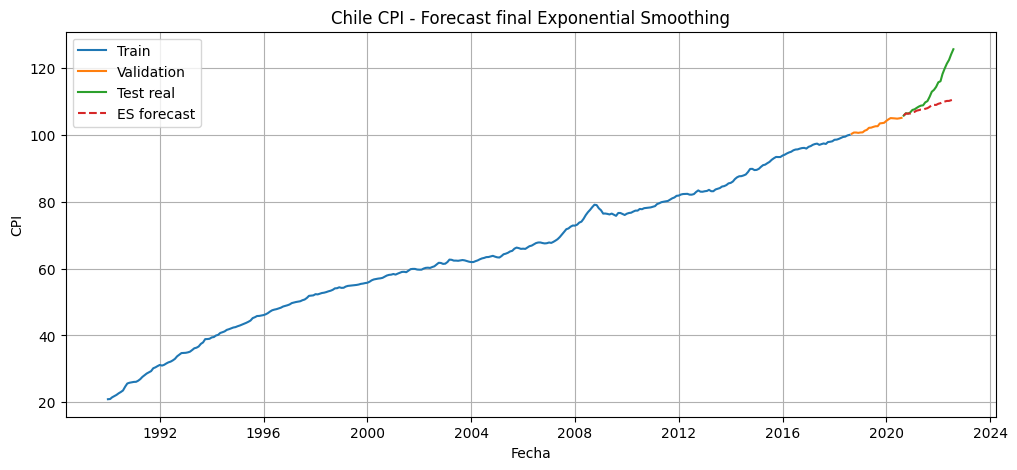

In [84]:
# =============================================================
# 11. GRÁFICO GENERAL ES
# =============================================================

plt.figure(figsize=(12, 5))

plt.plot(train_ts.index, train_ts, label="Train")
plt.plot(validation_ts.index, validation_ts, label="Validation")
plt.plot(test_ts.index, test_ts, label="Test real")
plt.plot(forecast_test_es.index, forecast_test_es, linestyle="--", label="ES forecast")

plt.title("Chile CPI - Forecast final Exponential Smoothing")
plt.xlabel("Fecha")
plt.ylabel("CPI")
plt.legend()
plt.grid(True)
plt.show()

Therefore, TES slightly improves over SARIMA, but the plot shows the same general limitation: the forecast remains below the real CPI when the strong 2021-2022 acceleration appears.

In other words, TES obtains good average performance and slightly improves over SARIMA, but it still underestimates the final CPI acceleration.

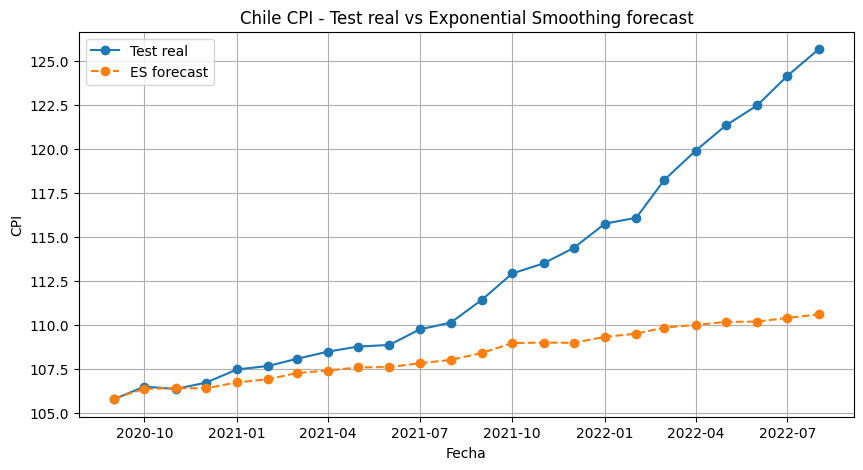

In [85]:
# =============================================================
# 12. GRÁFICO AMPLIADO TEST REAL VS ES FORECAST
# =============================================================

plt.figure(figsize=(10, 5))

plt.plot(test_ts.index, test_ts, marker="o", label="Test real")
plt.plot(forecast_test_es.index, forecast_test_es, marker="o", linestyle="--", label="ES forecast")

plt.title("Chile CPI - Test real vs Exponential Smoothing forecast")
plt.xlabel("Fecha")
plt.ylabel("CPI")
plt.legend()
plt.grid(True)
plt.show()

**7.9. Empirical intervals for Exponential Smoothing**

We use the same approach as with SARIMA: rolling forecasts on the pre-test history and errors grouped by horizon.

In [86]:
# =============================================================
# FUNCIÓN AUXILIAR PARA FORECAST TES
# =============================================================

def tes_forecast(data, h, alpha, gamma, delta, S=12, mtype="a"):
    """
    Ajusta el modelo TES sobre una serie histórica y devuelve solo los h valores forecast.
    Usa la función myTES definida previamente.
    """
    
    s = myTES(
        data,
        alpha,
        gamma,
        delta,
        S=S,
        mtype=mtype,
        NstepAh=h
    )
    
    return s[-h:]

In [87]:
# =============================================================
# 11. ERRORES EMPÍRICOS POR HORIZONTE
# =============================================================

H = len(test_ts)

# Usamos solo información anterior al test
historical_ts = train_validation_ts.copy()

# Mínimo histórico para poder ajustar TES con cierta estabilidad
min_train_size = 120   # 10 años mensuales

errors_by_h_tes = [[] for _ in range(H)]

for start in range(min_train_size, len(historical_ts) - H + 1):
    
    rolling_train = historical_ts.iloc[:start]
    rolling_real_future = historical_ts.iloc[start:start + H]
    
    try:
        rolling_forecast = tes_forecast(
            data=rolling_train,
            h=H,
            alpha=selected_alpha,
            gamma=selected_gamma,
            delta=selected_delta,
            S=S,
            mtype=selected_mtype
        )
        
        for h in range(H):
            error_h = rolling_real_future.iloc[h] - rolling_forecast[h]
            errors_by_h_tes[h].append(error_h)
            
    except Exception as e:
        pass

print("Number of errors used by horizon:")
print([len(errors_by_h_tes[h]) for h in range(H)])

Number of errors used by horizon:
[225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225]


In [88]:
# =============================================================
# 12. VARIANZA EMPÍRICA POR HORIZONTE
# =============================================================

var_h_tes = np.zeros(H)

for h in range(H):
    var_h_tes[h] = np.var(errors_by_h_tes[h], ddof=1)

print("Empirical variances by horizon - TES:")
print(var_h_tes)

Empirical variances by horizon - TES:
[ 0.55609621  0.82675134  1.15782972  1.53976085  1.96150595  2.41857899
  2.90227699  3.41728381  3.98465534  4.62872697  5.37836839  6.22984884
  7.65061292  8.85220015 10.09371553 11.3371854  12.54282986 13.67931739
 14.74878572 15.76501833 16.74048527 17.71771355 18.73694743 19.80251824]


In [89]:
# =============================================================
# 13. INTERVALOS EMPÍRICOS AL 95 %
# =============================================================

z = 1.96

lower_tes = forecast_test_es.values - z * np.sqrt(var_h_tes)
upper_tes = forecast_test_es.values + z * np.sqrt(var_h_tes)

lowerTES = pd.Series(
    lower_tes,
    index=test_ts.index,
    name="Lower TES PI"
)

upperTES = pd.Series(
    upper_tes,
    index=test_ts.index,
    name="Upper TES PI"
)

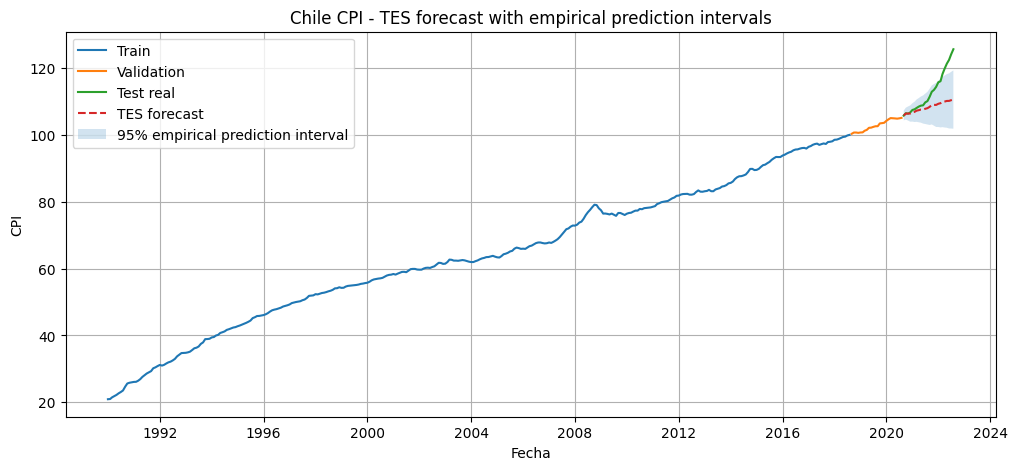

In [90]:
# =============================================================
# 14. GRÁFICO GENERAL TES CON INTERVALOS EMPÍRICOS
# =============================================================

plt.figure(figsize=(12, 5))

plt.plot(train_ts.index, train_ts, label="Train")
plt.plot(validation_ts.index, validation_ts, label="Validation")
plt.plot(test_ts.index, test_ts, label="Test real")
plt.plot(
    forecast_test_es.index,
    forecast_test_es,
    linestyle="--",
    label="TES forecast"
)

plt.fill_between(
    test_ts.index,
    lowerTES.values,
    upperTES.values,
    alpha=0.2,
    label="95% empirical prediction interval"
)

plt.title("Chile CPI - TES forecast with empirical prediction intervals")
plt.xlabel("Fecha")
plt.ylabel("CPI")
plt.legend()
plt.grid(True)
plt.show()

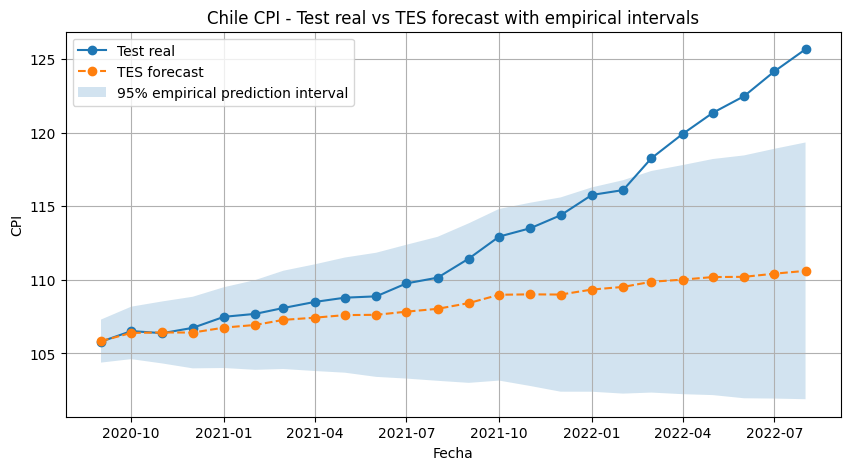

In [91]:
# =============================================================
# 15. GRÁFICO AMPLIADO TEST REAL VS TES FORECAST
# =============================================================

plt.figure(figsize=(10, 5))

plt.plot(test_ts.index, test_ts, marker="o", label="Test real")
plt.plot(
    forecast_test_es.index,
    forecast_test_es,
    marker="o",
    linestyle="--",
    label="TES forecast"
)

plt.fill_between(
    test_ts.index,
    lowerTES.values,
    upperTES.values,
    alpha=0.2,
    label="95% empirical prediction interval"
)

plt.title("Chile CPI - Test real vs TES forecast with empirical intervals")
plt.xlabel("Fecha")
plt.ylabel("CPI")
plt.legend()
plt.grid(True)
plt.show()

In [92]:
# =============================================================
# 16. COBERTURA DEL INTERVALO EMPÍRICO
# =============================================================

inside_interval_tes = (
    (test_ts.values >= lowerTES.values) &
    (test_ts.values <= upperTES.values)
)

coverage_tes = 100 * np.mean(inside_interval_tes)

print("Coverage of empirical 95% prediction interval in test - TES:", coverage_tes, "%")

tes_interval_results = pd.DataFrame({
    "Real_CPI": test_ts,
    "Forecast_TES": forecast_test_es,
    "Lower_PI_TES": lowerTES,
    "Upper_PI_TES": upperTES,
    "Inside_PI_TES": inside_interval_tes
})

tes_interval_results["Error_TES"] = (
    tes_interval_results["Real_CPI"] -
    tes_interval_results["Forecast_TES"]
)

print(tes_interval_results)

Coverage of empirical 95% prediction interval in test - TES: 75.0 %
            Real_CPI  Forecast_TES  Lower_PI_TES  Upper_PI_TES  Inside_PI_TES  \
Fecha                                                                           
2020-09-01    105.80    105.840603    104.378994    107.302211           True   
2020-10-01    106.52    106.396228    104.614081    108.178375           True   
2020-11-01    106.38    106.428083    104.319074    108.537092           True   
2020-12-01    106.74    106.419913    103.987805    108.852020           True   
2021-01-01    107.49    106.756272    104.011218    109.501326           True   
2021-02-01    107.69    106.937389    103.889240    109.985538           True   
2021-03-01    108.09    107.282813    103.943743    110.621882           True   
2021-04-01    108.50    107.430361    103.807125    111.053597           True   
2021-05-01    108.79    107.606036    103.693562    111.518510           True   
2021-06-01    108.88    107.625774    103

The TES model selected through validation shows smooth behavior and provides a very accurate fit during the validation period. However, on the test set it has difficulties capturing the later CPI acceleration. The point forecast remains systematically below the real values, and the error increases progressively across the prediction horizon. This suggests that the test period contains a change in inflation dynamics that was not sufficiently represented in the train/validation data.

The empirical 95% intervals cover 75% of the test observations. Although this coverage indicates that the interval captures an important part of predictive uncertainty, it remains below the expected nominal coverage. In addition, the final observations fall outside the interval above the upper bound, reinforcing the idea that the final CPI acceleration exceeds the historical variability estimated through rolling forecasts.

Both SARIMA and TES capture the regular evolution of the series, but both tend to underestimate the final period. TES slightly improves the average metrics, but its intervals show that the final acceleration exceeds the estimated historical uncertainty.

In [93]:
# =============================================================
# 17. GUARDAR RESULTADOS TES CON INTERVALOS
# =============================================================

tes_interval_results.to_csv("chile_cpi_tes_test_forecast_empirical_intervals.csv")

tes_interval_metrics = pd.DataFrame([{
    "Model": "TES",
    "alpha": selected_alpha,
    "gamma": selected_gamma,
    "delta": selected_delta,
    "mtype": selected_mtype,
    "Coverage_95_PI_test": coverage_tes
}])

tes_interval_metrics.to_csv("chile_cpi_tes_empirical_interval_coverage.csv", index=False)

print("TES results with empirical intervals saved successfully.")

TES results with empirical intervals saved successfully.


In [94]:
tes_test_metrics = pd.DataFrame([{
    "Model": "TES",
    "Model_name": f"TES-{selected_mtype}(alpha={selected_alpha}, gamma={selected_gamma}, delta={selected_delta})",
    "alpha": selected_alpha,
    "gamma": selected_gamma,
    "delta": selected_delta,
    "mtype": selected_mtype,
    "MSE_test": MSE_es,
    "RMSE_test": RMSE_es,
    "MAE_test": MAE_es,
    "MAPE_test": MAPE_es,
    "Coverage_95_PI_test": coverage_tes
}])

tes_test_metrics.to_csv("chile_cpi_es_test_metrics.csv", index=False)

print("TES metrics saved successfully.")

TES metrics saved successfully.


### **8. Comparativa final de modelos de Forecasting**

In [95]:
print("Selected model:")
print(f"SARIMA({selected_p},{d},{selected_q})x({selected_P},{D},{selected_Q},{S})")

Selected model:
SARIMA(3,1,2)x(1,1,1,12)


In [96]:
import pandas as pd
import numpy as np

# =============================================================
# CARGAR MÉTRICAS GUARDADAS
# =============================================================

baseline_metrics = pd.read_csv("chile_cpi_baseline_test_metrics.csv")
sarima_metrics = pd.read_csv("chile_cpi_sarima_test_metrics.csv")
sarima_interval_metrics = pd.read_csv("chile_cpi_sarima_empirical_interval_coverage.csv")


# =============================================================
# TABLA COMPARATIVA FINAL
# =============================================================

tabla_modelos = pd.DataFrame([
    {
        "Modelo": "Baseline",
        "Tipo": "Extrapolación de curva",
        "Modelo seleccionado": baseline_metrics.loc[0, "Modelo"],
        "MSE test": baseline_metrics.loc[0, "RMSE"] ** 2,
        "RMSE test": baseline_metrics.loc[0, "RMSE"],
        "MAE test": baseline_metrics.loc[0, "MAE"],
        "MAPE test (%)": baseline_metrics.loc[0, "MAPE"],
        "Cobertura intervalo 95%": np.nan
    },
    {
        "Modelo": "SARIMA",
        "Tipo": "Box-Jenkins",
        "Modelo seleccionado": sarima_metrics.loc[0, "Modelo"],
        "MSE test": sarima_metrics.loc[0, "MSE_test"],
        "RMSE test": sarima_metrics.loc[0, "RMSE_test"],
        "MAE test": sarima_metrics.loc[0, "MAE_test"],
        "MAPE test (%)": sarima_metrics.loc[0, "MAPE_test"],
        "Cobertura intervalo 95%": sarima_interval_metrics.loc[0, "Coverage_test_percent"]
    },
    {
        "Modelo": "TES",
        "Tipo": "Exponential Smoothing",
        "Modelo seleccionado": f"TES-{selected_mtype}(alpha={selected_alpha}, gamma={selected_gamma}, delta={selected_delta})",
        "MSE test": MSE_es,
        "RMSE test": RMSE_es,
        "MAE test": MAE_es,
        "MAPE test (%)": MAPE_es,
        "Cobertura intervalo 95%": coverage_tes
    }
])

# =============================================================
# REDONDEAR Y GUARDAR
# =============================================================

cols_numericas = [
    "MSE test",
    "RMSE test",
    "MAE test",
    "MAPE test (%)",
    "Cobertura intervalo 95%"
]

tabla_modelos[cols_numericas] = tabla_modelos[cols_numericas].round(3)

print(tabla_modelos)

tabla_modelos.to_csv("chile_cpi_comparacion_modelos_final.csv", index=False)

     Modelo                    Tipo                     Modelo seleccionado  \
0  Baseline  Extrapolación de curva             Baseline polinómico grado 1   
1    SARIMA             Box-Jenkins                SARIMA(3,1,2)x(1,1,1,12)   
2       TES   Exponential Smoothing  TES-m(alpha=0.2, gamma=0.2, delta=0.3)   

   MSE test  RMSE test  MAE test  MAPE test (%)  Cobertura intervalo 95%  
0    57.560      7.587     5.974          5.091                      NaN  
1    46.796      6.841     5.046          4.270                   54.167  
2    42.991      6.557     4.615          3.885                   75.000  


The comparison shows that both the SARIMA and TES models outperform the trend-extrapolation baseline. The baseline captures the long-term upward trend of the CPI series, but it does not explicitly model seasonality or temporal dependence, leading to the largest forecast errors. The SARIMA model improves on the baseline by incorporating regular and seasonal differencing and by modeling autocorrelation. However, its empirical 95% prediction intervals only reach 58.33% coverage, indicating that the uncertainty estimated from historical errors is not enough to cover the strong CPI increase observed in the test period.

The best overall performance is obtained by the multiplicative TES model, with the lowest RMSE, MAE and MAPE values. This is consistent with the structure of Chile's CPI series, which has a clear trend and annual seasonality. TES also provides better empirical interval coverage than SARIMA, reaching 75%. Nevertheless, this coverage is still below the nominal 95%, confirming that the final test period contains a stronger acceleration than the historical dynamics captured during training and validation. Overall, TES is selected as the best forecasting model, although its main limitation is the underestimation of inflationary acceleration in the final months.

**VERY IMPORTANT:** To correct this error, we will perform a *rolling one-step-ahead* evaluation, refitting the model each month with the observed data available up to that point. This approach does not use future information; instead, it simulates the progressive arrival of real data.

1. Train with data up to August 2020.
2. Predict September 2020.
3. Then incorporate the real September 2020 value into the training set.
4. Refit the model with data up to September 2020.
5. Predict October 2020.
6. Incorporate the real October 2020 value.
7. Refit.
8. Predict November 2020.

And so on.

We now perform a rolling one-step-ahead evaluation:

In each month of the test set, we train the model using all observed information up to the previous month, predict only the next month, incorporate the real value, and repeat.

This is not cheating, because each prediction only uses information that would have been available at that moment.

### **Rolling one-step-ahead para SARIMA**

In [97]:
# =============================================================
# ROLLING ONE-STEP-AHEAD FORECAST - SARIMA
# =============================================================

from statsmodels.tsa.arima.model import ARIMA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Parámetros del modelo seleccionado
selected_p = 3
d = 1
selected_q = 2

selected_P = 1
D = 1
selected_Q = 1
S = 12

# Histórico inicial: train + validation, hasta agosto de 2020
history_sarima = train_validation_ts.copy()

rolling_forecast_sarima = []

for date in test_ts.index:
    
    # Ajustamos el modelo con los datos disponibles hasta el mes anterior
    model = ARIMA(
        history_sarima,
        order=(selected_p, d, selected_q),
        seasonal_order=(selected_P, D, selected_Q, S)
    )
    
    fit = model.fit()
    
    # Forecast one-step-ahead
    pred = fit.forecast(steps=1).iloc[0]
    
    rolling_forecast_sarima.append(pred)
    
    # Incorporamos el dato real observado de ese mes
    history_sarima.loc[date] = test_ts.loc[date]

# Convertimos las predicciones a Serie
rolling_forecast_sarima = pd.Series(
    rolling_forecast_sarima,
    index=test_ts.index,
    name="SARIMA rolling one-step forecast"
)

print(rolling_forecast_sarima.head())

Fecha
2020-09-01    105.484553
2020-10-01    106.323325
2020-11-01    106.734910
2020-12-01    106.354048
2021-01-01    107.038140
Name: SARIMA rolling one-step forecast, dtype: float64


In [98]:
# =============================================================
# MÉTRICAS SARIMA ROLLING ONE-STEP-AHEAD
# =============================================================

MSE_sarima_roll, RMSE_sarima_roll, MAE_sarima_roll, MAPE_sarima_roll = forecasting_metrics(
    test_ts.values,
    rolling_forecast_sarima.values
)

print("SARIMA rolling one-step-ahead metrics:")
print("MSE  =", MSE_sarima_roll)
print("RMSE =", RMSE_sarima_roll)
print("MAE  =", MAE_sarima_roll)
print("MAPE =", MAPE_sarima_roll)

SARIMA rolling one-step-ahead metrics:
MSE  = 0.2882756599563195
RMSE = 0.5369130841731458
MAE  = 0.41824713832435084
MAPE = 0.36564910322430266


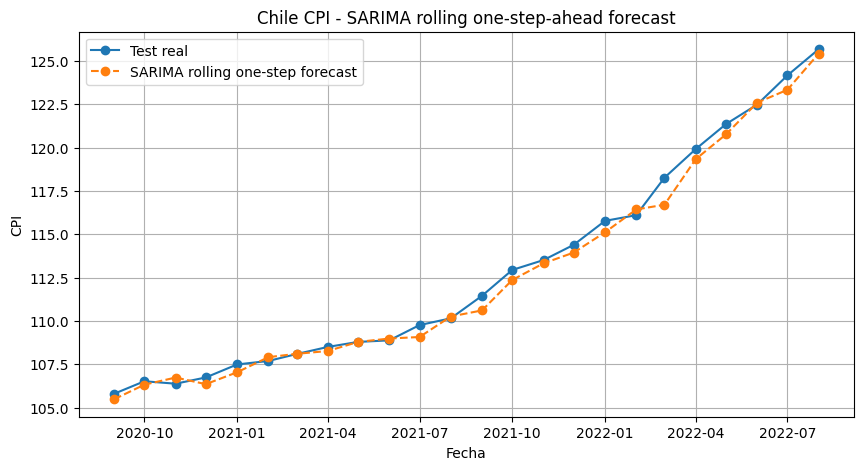

In [99]:
# =============================================================
# GRÁFICO SARIMA ROLLING ONE-STEP-AHEAD
# =============================================================

plt.figure(figsize=(10, 5))

plt.plot(test_ts.index, test_ts, marker="o", label="Test real")
plt.plot(
    rolling_forecast_sarima.index,
    rolling_forecast_sarima,
    marker="o",
    linestyle="--",
    label="SARIMA rolling one-step forecast"
)

plt.title("Chile CPI - SARIMA rolling one-step-ahead forecast")
plt.xlabel("Fecha")
plt.ylabel("CPI")
plt.legend()
plt.grid(True)
plt.show()

### **Rolling one-step-ahead para TES**

In [100]:
# =============================================================
# ROLLING ONE-STEP-AHEAD FORECAST - TES
# =============================================================

selected_alpha = 0.2
selected_gamma = 0.2
selected_delta = 0.3
selected_mtype = "m"
S = 12

# Histórico inicial: train + validation
history_tes = train_validation_ts.copy()

rolling_forecast_tes = []

for date in test_ts.index:
    
    # Ajustamos TES con los datos disponibles hasta el mes anterior
    s_rolling = myTES(
        history_tes,
        selected_alpha,
        selected_gamma,
        selected_delta,
        S=S,
        mtype=selected_mtype,
        NstepAh=1
    )
    
    # Forecast one-step-ahead
    pred = s_rolling[-1]
    
    rolling_forecast_tes.append(pred)
    
    # Incorporamos el dato real observado de ese mes
    history_tes.loc[date] = test_ts.loc[date]

# Convertimos a Serie
rolling_forecast_tes = pd.Series(
    rolling_forecast_tes,
    index=test_ts.index,
    name="TES rolling one-step forecast"
)

print(rolling_forecast_tes.head())

Fecha
2020-09-01    105.840603
2020-10-01    106.386452
2020-11-01    106.448694
2020-12-01    106.427726
2021-01-01    106.840083
Name: TES rolling one-step forecast, dtype: float64


In [101]:
# =============================================================
# MÉTRICAS TES ROLLING ONE-STEP-AHEAD
# =============================================================

MSE_tes_roll, RMSE_tes_roll, MAE_tes_roll, MAPE_tes_roll = forecasting_metrics(
    test_ts.values,
    rolling_forecast_tes.values
)

print("TES rolling one-step-ahead metrics:")
print("MSE  =", MSE_tes_roll)
print("RMSE =", RMSE_tes_roll)
print("MAE  =", MAE_tes_roll)
print("MAPE =", MAPE_tes_roll)

TES rolling one-step-ahead metrics:
MSE  = 2.1806612540638723
RMSE = 1.4767062179268673
MAE  = 1.1898953105280181
MAPE = 1.0185342559201507


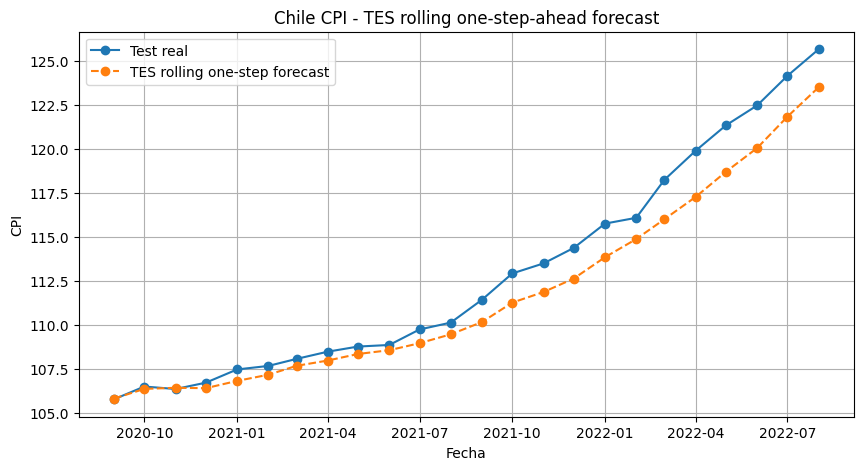

In [102]:
# =============================================================
# GRÁFICO TES ROLLING ONE-STEP-AHEAD
# =============================================================

plt.figure(figsize=(10, 5))

plt.plot(test_ts.index, test_ts, marker="o", label="Test real")
plt.plot(
    rolling_forecast_tes.index,
    rolling_forecast_tes,
    marker="o",
    linestyle="--",
    label="TES rolling one-step forecast"
)

plt.title("Chile CPI - TES rolling one-step-ahead forecast")
plt.xlabel("Fecha")
plt.ylabel("CPI")
plt.legend()
plt.grid(True)
plt.show()

**Joint comparison**

We now compare the previous models with the rolling models.

In [103]:
# =============================================================
# TABLA COMPARATIVA FINAL
# =============================================================

comparison_rolling = pd.DataFrame([
    {
        "Modelo": "SARIMA",
        "Estrategia": "Multi-step 24 meses",
        "MSE": 46.534,
        "RMSE": 6.822,
        "MAE": 5.037,
        "MAPE": 4.263
    },
    {
        "Modelo": "TES",
        "Estrategia": "Multi-step 24 meses",
        "MSE": 42.991,
        "RMSE": 6.557,
        "MAE": 4.615,
        "MAPE": 3.885
    },
    {
        "Modelo": "SARIMA",
        "Estrategia": "Rolling one-step-ahead",
        "MSE": MSE_sarima_roll,
        "RMSE": RMSE_sarima_roll,
        "MAE": MAE_sarima_roll,
        "MAPE": MAPE_sarima_roll
    },
    {
        "Modelo": "TES",
        "Estrategia": "Rolling one-step-ahead",
        "MSE": MSE_tes_roll,
        "RMSE": RMSE_tes_roll,
        "MAE": MAE_tes_roll,
        "MAPE": MAPE_tes_roll
    }
])

print(comparison_rolling)

   Modelo              Estrategia        MSE      RMSE       MAE      MAPE
0  SARIMA     Multi-step 24 meses  46.534000  6.822000  5.037000  4.263000
1     TES     Multi-step 24 meses  42.991000  6.557000  4.615000  3.885000
2  SARIMA  Rolling one-step-ahead   0.288276  0.536913  0.418247  0.365649
3     TES  Rolling one-step-ahead   2.180661  1.476706  1.189895  1.018534


**Joint plot SARIMA vs TES rolling**

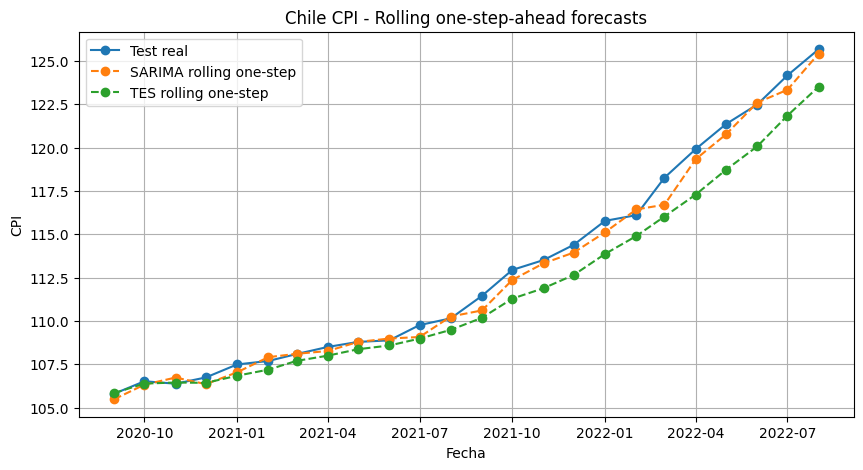

In [104]:
# =============================================================
# GRÁFICO CONJUNTO ROLLING ONE-STEP-AHEAD
# =============================================================

plt.figure(figsize=(10, 5))

plt.plot(test_ts.index, test_ts, marker="o", label="Test real")

plt.plot(
    rolling_forecast_sarima.index,
    rolling_forecast_sarima,
    marker="o",
    linestyle="--",
    label="SARIMA rolling one-step"
)

plt.plot(
    rolling_forecast_tes.index,
    rolling_forecast_tes,
    marker="o",
    linestyle="--",
    label="TES rolling one-step"
)

plt.title("Chile CPI - Rolling one-step-ahead forecasts")
plt.xlabel("Fecha")
plt.ylabel("CPI")
plt.legend()
plt.grid(True)
plt.show()

**Guardar resultados**

In [105]:
# =============================================================
# GUARDAR RESULTADOS ROLLING ONE-STEP-AHEAD
# =============================================================

rolling_results = pd.DataFrame({
    "Real_CPI": test_ts,
    "SARIMA_rolling_forecast": rolling_forecast_sarima,
    "TES_rolling_forecast": rolling_forecast_tes
})

rolling_results["SARIMA_error"] = (
    rolling_results["Real_CPI"] -
    rolling_results["SARIMA_rolling_forecast"]
)

rolling_results["TES_error"] = (
    rolling_results["Real_CPI"] -
    rolling_results["TES_rolling_forecast"]
)

rolling_results.to_csv("chile_cpi_rolling_one_step_forecasts.csv")

comparison_rolling.to_csv("chile_cpi_forecast_strategy_comparison.csv", index=False)

print("Resultados rolling one-step-ahead guardados correctamente.")

Resultados rolling one-step-ahead guardados correctamente.


Initially, the SARIMA and TES models were evaluated using a fixed-origin multi-step strategy, training up to August 2020 and directly predicting the 24 months of the test set. However, the test set shows a strong CPI acceleration that did not appear in the same way in train or validation. Therefore, both models tended to underestimate the final section.

To correct this problem, a rolling one-step-ahead evaluation was applied. In each month of the test set, the model is refitted with all real data observed up to that moment and predicts only the following month. Then the observed real value is incorporated and the process is repeated. This strategy does not use future information; it simulates the progressive arrival of real data.

This approach allows a more realistic short-term forecasting evaluation and helps the models progressively adapt to the change in dynamics observed in the CPI during the test period.

The rolling one-step-ahead evaluation very notably improves the performance of both models compared with the 24-month multi-step forecast. This confirms that the main problem in the initial evaluation was the CPI acceleration in the test period, which could not be incorporated when predicting all 24 months at once. This acceleration coincides with the post-pandemic context in Chile, where inflation rose sharply from 2021 due to a combination of higher domestic demand, global cost pressures, supply-chain problems, and increases in energy and food prices.

By updating the model each month with the new observed value, predictions progressively adapt to the change in dynamics. Therefore, the main issue was not that SARIMA and TES were generally unsuitable models, but that the fixed multi-step strategy did not allow the new information observed during the test period to be incorporated.

SARIMA is the best-performing model in this scenario, with RMSE = 0.537, MAE = 0.418 and MAPE = 0.366%. TES also improves considerably, with MAPE = 1.019%, but it is less accurate than SARIMA. Therefore, in a realistic short-term monthly forecasting context, SARIMA would be the preferred model.

### **9. Multivariate comparison with Latin American CPI series**

I will use the following countries for the comparison:

- Mexico
- Colombia
- Brazil

Why these?

Because they are Latin American countries, regionally comparable, with interesting and potentially related inflation dynamics. In addition, Brazil can provide a more intense dynamic, while Mexico and Colombia can act as more balanced comparisons.

**9.1. Extract PCPI_IX for Chile, Mexico, Colombia and Brazil**

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# =============================================================
# 1. CARGAR DATASET ORIGINAL
# =============================================================

df = pd.read_csv("CPITimeSeries.csv", low_memory=False)

countries = ["Chile", "Mexico", "Colombia", "Brazil"]
indicator_code = "PCPI_IX"

# Columnas de fechas tipo 1990M1, 1990M2, ...
date_cols = [
    col for col in df.columns
    if re.fullmatch(r"\d{4}M\d{1,2}", str(col))
]

print("Number of monthly columns:", len(date_cols))
print("First monthly column:", date_cols[0])
print("Last monthly column:", date_cols[-1])

Number of monthly columns: 872
First monthly column: 1950M1
Last monthly column: 2022M8


**9.2. Function to convert from wide to long format**

In [107]:
# =============================================================
# 2. FUNCIÓN PARA EXTRAER CPI DE CADA PAÍS
# =============================================================

def extract_country_cpi(df, country_name, indicator_code="PCPI_IX"):
    """
    Extrae la serie PCPI_IX de un país:
    - filtra país
    - filtra indicador
    - filtra Attribute == Value
    - pasa de formato ancho a largo
    - convierte CPI a numérico
    - convierte Fecha a datetime
    """
    
    df_country = df[
        (df["Country Name"].str.strip() == country_name) &
        (df["Indicator Code"] == indicator_code) &
        (df["Attribute"] == "Value")
    ].copy()
    
    if df_country.empty:
        raise ValueError(f"No se encontró serie para {country_name}")
    
    serie = df_country[date_cols].iloc[0]
    serie = pd.to_numeric(serie, errors="coerce")
    
    df_long = serie.reset_index()
    df_long.columns = ["Fecha", country_name]
    
    df_long["Fecha"] = pd.to_datetime(
        df_long["Fecha"].str.replace("M", "-", regex=False) + "-01"
    )
    
    df_long = df_long.sort_values("Fecha").reset_index(drop=True)
    
    return df_long

**9.3. Build the common CPI dataset**

In [108]:
# =============================================================
# 3. EXTRAER SERIES CPI Y UNIRLAS
# =============================================================

cpi_dfs = []

for country in countries:
    country_df = extract_country_cpi(df, country, indicator_code)
    cpi_dfs.append(country_df)

# Unimos todas las series por Fecha
cpi_multi = cpi_dfs[0]

for country_df in cpi_dfs[1:]:
    cpi_multi = pd.merge(cpi_multi, country_df, on="Fecha", how="outer")

# Orden temporal
cpi_multi = cpi_multi.sort_values("Fecha").reset_index(drop=True)

print(cpi_multi.head())
print(cpi_multi.tail())

       Fecha  Chile  Mexico  Colombia  Brazil
0 1950-01-01    NaN     NaN       NaN     NaN
1 1950-02-01    NaN     NaN       NaN     NaN
2 1950-03-01    NaN     NaN       NaN     NaN
3 1950-04-01    NaN     NaN       NaN     NaN
4 1950-05-01    NaN     NaN       NaN     NaN
         Fecha   Chile   Mexico  Colombia   Brazil
867 2022-04-01  119.91  120.809  117.7089  6382.88
868 2022-05-01  121.35  121.022  118.7032  6412.88
869 2022-06-01  122.48  122.044  119.3053  6455.85
870 2022-07-01  124.16  122.948  120.2736  6411.95
871 2022-08-01  125.67  123.803  121.5025      NaN


**9.4. Keep the common period from 1990 onward**

In [109]:
# =============================================================
# 4. FILTRAR DESDE 1990 Y PERIODO COMÚN SIN NULOS
# =============================================================

cpi_multi_1990 = cpi_multi[cpi_multi["Fecha"] >= "1990-01-01"].copy()

print("Missing values from 1990 before filtering the common period:")
print(cpi_multi_1990.isna().sum())

# Periodo común: eliminamos meses donde falte algún país
cpi_common = cpi_multi_1990.dropna().copy()

cpi_common = cpi_common.set_index("Fecha")

print("\nFinal common period:")
print(cpi_common.index.min(), "->", cpi_common.index.max())
print("Number of observations:", len(cpi_common))

print("\nMissing values in the common period:")
print(cpi_common.isna().sum())

print(cpi_common.head())
print(cpi_common.tail())

Missing values from 1990 before filtering the common period:
Fecha       0
Chile       0
Mexico      0
Colombia    0
Brazil      1
dtype: int64

Final common period:
1990-01-01 00:00:00 -> 2022-07-01 00:00:00
Number of observations: 391

Missing values in the common period:
Chile       0
Mexico      0
Colombia    0
Brazil      0
dtype: int64
               Chile    Mexico  Colombia    Brazil
Fecha                                             
1990-01-01  20.92559  7.776037  5.967753  0.005411
1990-02-01  20.98727  7.952120  6.191108  0.009508
1990-03-01  21.49400  8.092310  6.372583  0.017343
1990-04-01  21.87580  8.215471  6.547079  0.020034
1990-05-01  22.20919  8.358838  6.679696  0.021555
             Chile   Mexico  Colombia   Brazil
Fecha                                         
2022-03-01  118.26  120.159  116.2593  6315.93
2022-04-01  119.91  120.809  117.7089  6382.88
2022-05-01  121.35  121.022  118.7032  6412.88
2022-06-01  122.48  122.044  119.3053  6455.85
2022-07-01  124.1

The original dataset contains 872 monthly columns, from 1950M1 to 2022M8. However, many missing values appear at the beginning because not all countries have data available since 1950. For that reason, the relevant project period, from 1990 onward, is filtered later.

After keeping the four countries -- Chile, Mexico, Colombia and Brazil -- and filtering from January 1990, only one missing value remains, corresponding to Brazil in August 2022. To work with a common and comparable period for all countries, that month is removed. Thus, the final common period is defined as:

1990-01-01 -> 2022-07-01

with 391 complete monthly observations and no missing values.

An important point is that CPI levels are not on the same scale. For example, in 2022 Chile, Mexico and Colombia have values around 120, while Brazil exceeds 6000. This does not necessarily imply an error; rather, the indices may have different bases or historical scales. For this reason, the multivariate comparison should not be based on CPI levels, but on monthly inflation, calculated as the percentage change in CPI.

**9.5. Plot CPI for the four countries**

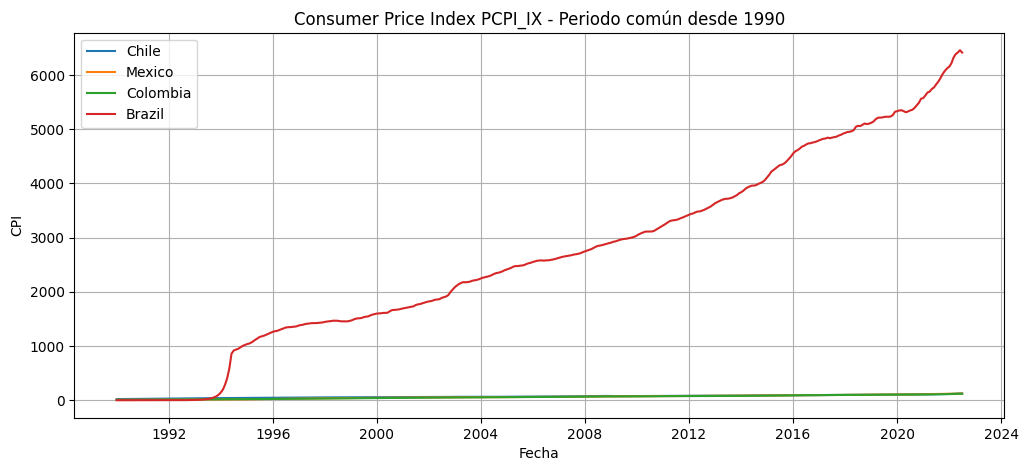

In [110]:
# =============================================================
# 5. GRÁFICO CPI EN NIVELES
# =============================================================

plt.figure(figsize=(12, 5))

for country in countries:
    plt.plot(cpi_common.index, cpi_common[country], label=country)

plt.title("Consumer Price Index PCPI_IX - Periodo común desde 1990")
plt.xlabel("Fecha")
plt.ylabel("CPI")
plt.legend()
plt.grid(True)
plt.show()

Brazil has a much larger CPI scale than Chile, Mexico and Colombia, and when all series are plotted on the same vertical axis, the Brazilian series dominates the plot and visually flattens the others.

All series are present in the plot, but Chile, Mexico and Colombia are compressed near zero because Brazil reaches values above 6000, while Chile is around 20-125 in the period being used. This happens because CPIs from different countries may have different base periods or index scales that are not directly comparable.

Therefore, for the multivariate part, CPI levels should not be compared directly.

**Note for the report:** this plot is useful for seeing the evolution in levels, but to analyze relationships between countries it is better to work with monthly inflation, because CPI levels have trend and different scales. In the theory, something similar is done by transforming CPI into percentage change to approximate a more stationary and interpretable series as inflation.

**9.6. Transform CPI into monthly inflation**

Monthly inflation is calculated as:

Monthly inflation = ((CPI_t / CPI_{t-1}) - 1) * 100

In [111]:
# =============================================================
# 6. TRANSFORMAR CPI A INFLACIÓN MENSUAL
# =============================================================

inflation = cpi_common.pct_change() * 100
inflation = inflation.dropna()

print("Monthly inflation:")
print(inflation.head())
print(inflation.tail())

print("\nMissing values in monthly inflation:")
print(inflation.isna().sum())

print("\nDescriptive summary of monthly inflation:")
print(inflation.describe())

Monthly inflation:
               Chile    Mexico  Colombia     Brazil
Fecha                                              
1990-02-01  0.294759  2.264431  3.742698  75.730000
1990-03-01  2.414464  1.762926  2.931220  82.389986
1990-04-01  1.776310  1.521951  2.738230  15.519978
1990-05-01  1.524013  1.745086  2.025590   7.590005
1990-06-01  2.193686  2.202459  1.880879  11.750013
               Chile    Mexico  Colombia    Brazil
Fecha                                             
2022-03-01  1.860465  0.990074  0.995892  1.620050
2022-04-01  1.395231  0.540950  1.246868  1.060018
2022-05-01  1.200901  0.176311  0.844711  0.470007
2022-06-01  0.931191  0.844475  0.507231  0.670058
2022-07-01  1.371653  0.740716  0.811615 -0.680003

Missing values in monthly inflation:
Chile       0
Mexico      0
Colombia    0
Brazil      0
dtype: int64

Descriptive summary of monthly inflation:
            Chile      Mexico    Colombia      Brazil
count  390.000000  390.000000  390.000000  390.000000
me

**9.7. Graficar inflaciones mensuales**

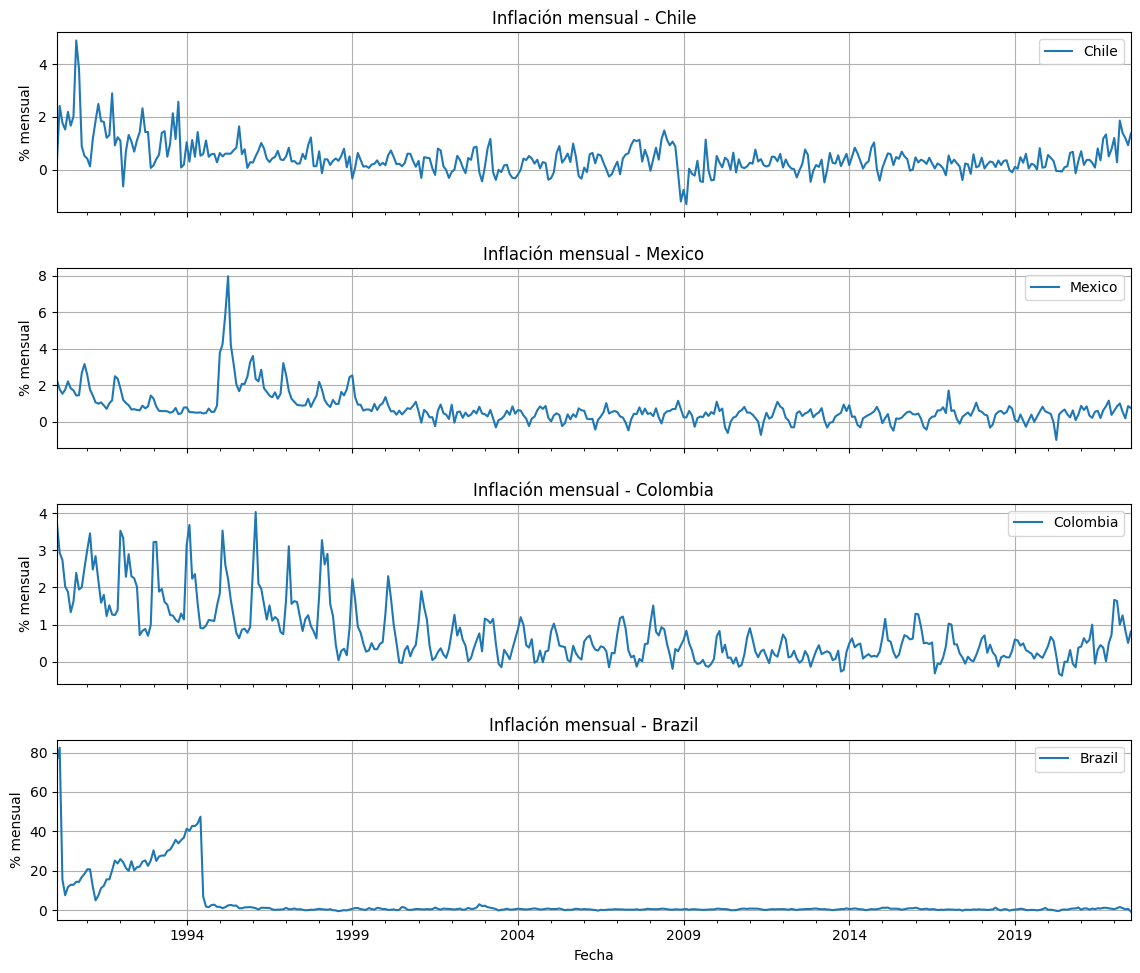

In [112]:
# =============================================================
# 7. GRÁFICO DE INFLACIONES MENSUALES
# =============================================================

fig, axs = plt.subplots(len(countries), 1, figsize=(12, 10), sharex=True)
fig.tight_layout(pad=3)

for i, country in enumerate(countries):
    inflation[country].plot(ax=axs[i], legend=True)
    axs[i].set_title(f"Inflación mensual - {country}")
    axs[i].set_ylabel("% mensual")
    axs[i].grid(True)

axs[-1].set_xlabel("Fecha")

plt.show()

**Country-level reading:**

- Chile shows relatively stable monthly inflation, although with occasional episodes of higher inflation at the beginning of the 1990s and a new increase toward the end of the period, consistent with the acceleration observed in the test set.

- Mexico shows a notable peak around the mid-1990s, with a maximum close to 8% monthly, followed by a more moderate dynamic.

- Colombia has high and persistent monthly inflation at the beginning of the period, but it gradually decreases over time.

- Brazil behaves very differently from the rest because of the hyperinflation of the early 1990s. This greatly increases its mean and standard deviation, so any direct comparison with the other countries should be interpreted cautiously.

**9.8. Comparar volatilidad**

In [113]:
# =============================================================
# 8. TABLA DE VOLATILIDAD DE INFLACIÓN
# =============================================================

volatility_table = pd.DataFrame({
    "Mean_monthly_inflation": inflation.mean(),
    "Std_monthly_inflation": inflation.std(),
    "Min_monthly_inflation": inflation.min(),
    "Max_monthly_inflation": inflation.max()
})

volatility_table = volatility_table.sort_values("Std_monthly_inflation", ascending=False)

print(volatility_table)

          Mean_monthly_inflation  Std_monthly_inflation  \
Brazil                  4.065502              10.273524   
Mexico                  0.713931               0.853457   
Colombia                0.776418               0.825262   
Chile                   0.459463               0.613952   

          Min_monthly_inflation  Max_monthly_inflation  
Brazil                -0.680003              82.389986  
Mexico                -1.013684               7.968306  
Colombia              -0.376223               4.028742  
Chile                 -1.302149               4.892345  


After transforming CPI into monthly inflation, the series represent the monthly percentage change in prices, allowing better comparison across countries even if their original indices had different scales.

Overall, Chile, Mexico and Colombia show much more comparable monthly inflation rates. Their monthly means are:

Chile:    0.46%
Mexico:   0.71%
Colombia: 0.78%

Chile is the country with the lowest average monthly inflation and also the lowest volatility:

std Chile:    0.61
std Mexico:   0.85
std Colombia: 0.83

This indicates that, within the common period, Chilean monthly inflation has been more stable than Mexican and Colombian monthly inflation.

Brazil is different. It has a much higher monthly mean:

Brazil: 4.07%

and much higher volatility:

std Brazil: 10.27

This is mainly due to the early 1990s, when Brazil recorded extremely high monthly inflation episodes, with maximum values above 80% monthly. The plot clearly shows Brazil completely dominating the scale at the beginning of the period. After the mid-1990s, its monthly inflation decreases substantially and becomes more comparable with the rest.

**9.9. Contemporaneous correlations**

In [114]:
# =============================================================
# 9. MATRIZ DE CORRELACIONES CONTEMPORÁNEAS
# =============================================================

corr_matrix = inflation.corr()

print("Contemporaneous correlation table:")
print(corr_matrix)

Contemporaneous correlation table:
             Chile    Mexico  Colombia    Brazil
Chile     1.000000  0.212894  0.343690  0.381333
Mexico    0.212894  1.000000  0.515718  0.169449
Colombia  0.343690  0.515718  1.000000  0.547626
Brazil    0.381333  0.169449  0.547626  1.000000


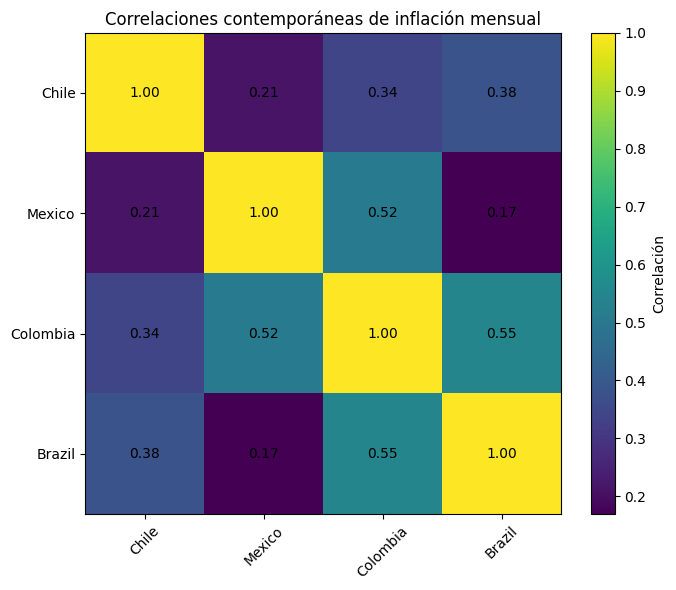

In [115]:
# Gráfico simple de matriz de correlación
plt.figure(figsize=(7, 6))

plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlación")

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)

plt.title("Correlaciones contemporáneas de inflación mensual")

for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                 ha="center", va="center")

plt.tight_layout()
plt.show()

The contemporaneous correlation matrix shows positive relationships among all monthly inflation series, but with different intensities. This means that, in general, when monthly inflation increases in one country, it also tends to increase in the others, although not always with the same strength.

Chile's inflation shows positive but moderate or weak correlations with the rest:

Chile - Mexico:   0.21
Chile - Colombia: 0.34
Chile - Brazil:   0.38

This indicates that Chilean inflation shares some common dynamics with the other Latin American countries, but it does not move in strong synchronization with any of them. Chile's highest relationship is with Brazil, 0.38, followed by Colombia, 0.34, while the relationship with Mexico is weaker, 0.21.

The strongest relationships in the whole matrix appear between:

Colombia - Brazil: 0.55
Mexico - Colombia: 0.52

These correlations can already be considered moderate, suggesting greater synchronization of monthly inflation between those countries.

The weakest relationship is:

Mexico - Brazil: 0.17

This indicates that their monthly inflation rates have a fairly low contemporaneous association during the period analyzed.

**9.10. Scatter plots Chile vs each country**

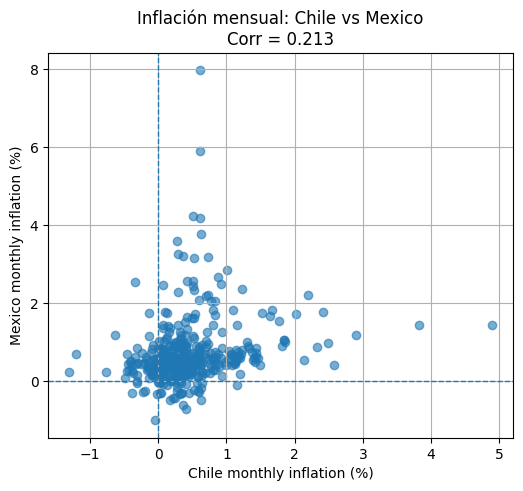

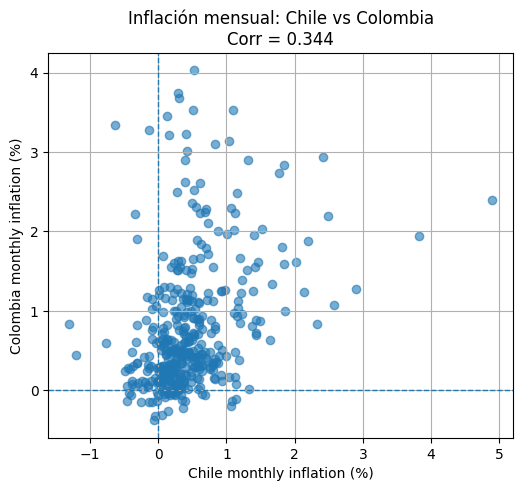

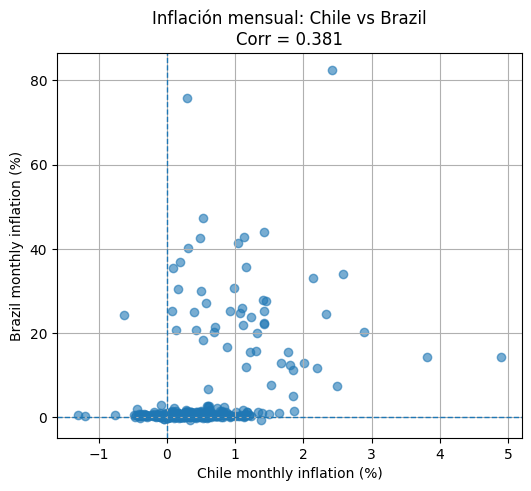

In [116]:
# =============================================================
# 10. SCATTER PLOTS CHILE VS OTROS PAÍSES
# =============================================================

comparison_countries = ["Mexico", "Colombia", "Brazil"]

for country in comparison_countries:
    
    plt.figure(figsize=(6, 5))
    
    plt.scatter(
        inflation["Chile"],
        inflation[country],
        alpha=0.6
    )
    
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.axvline(0, linestyle="--", linewidth=1)
    
    corr_value = inflation["Chile"].corr(inflation[country])
    
    plt.title(f"Inflación mensual: Chile vs {country}\nCorr = {corr_value:.3f}")
    plt.xlabel("Chile monthly inflation (%)")
    plt.ylabel(f"{country} monthly inflation (%)")
    plt.grid(True)
    plt.show()

These plots examine the contemporaneous relationship: months in which Chile has high/low inflation compared with high/low inflation in the other country.

The scatter plots confirm what the correlation matrix already suggested: the relationship between Chilean monthly inflation and the inflation of the other countries is positive, but not especially strong.

The scatter plots show positive associations between Chilean monthly inflation and the inflation of Mexico, Colombia and Brazil, although none of the relationships is especially strong. The weakest relationship appears with Mexico, where the point cloud is very dispersed and the correlation is low. With Colombia, a somewhat clearer positive association is observed, although it remains moderate. The highest correlation is obtained with Brazil, but this should be interpreted cautiously because of the extreme Brazilian inflation values in the first years of the period. Overall, the plots suggest that Chilean inflation shares certain common movements with other Latin American countries, but it maintains its own dynamics and is not strongly synchronized with any of them.

**9.11. Funciones de cross-correlation sequence**

In [117]:
# =============================================================
# 11. FUNCIONES CCS
# =============================================================

def crosscov(timeserie1, timeserie2, T=0):
    """
    Covarianza cruzada muestral para lag T >= 0.
    Relaciona timeserie1[n] con timeserie2[n+T].
    """
    
    x = pd.Series(timeserie1).dropna().reset_index(drop=True)
    y = pd.Series(timeserie2).dropna().reset_index(drop=True)
    
    N = min(x.size, y.size)
    
    x = x.iloc[:N]
    y = y.iloc[:N]
    
    mu1 = x.mean()
    mu2 = y.mean()
    
    covCoef = 0
    
    for n in range(0, N - T):
        covCoef += (x.iloc[n] - mu1) * (y.iloc[n + T] - mu2)
    
    return covCoef / float(N)


def crosscoef(timeserie1, timeserie2, T=0):
    """
    Correlación cruzada normalizada para lag T >= 0.
    """
    
    x = pd.Series(timeserie1).dropna().reset_index(drop=True)
    y = pd.Series(timeserie2).dropna().reset_index(drop=True)
    
    s1 = x.std()
    s2 = y.std()
    
    return crosscov(x, y, T) / (s1 * s2)


def ccs(timeserie1, timeserie2, maxT, twoside=False):
    """
    Cross-correlation sequence.
    
    Si twoside=False:
        calcula lags 0, 1, ..., maxT.
    
    Si twoside=True:
        calcula lags -maxT, ..., 0, ..., +maxT.
    """
    
    x = pd.Series(timeserie1).dropna().reset_index(drop=True)
    y = pd.Series(timeserie2).dropna().reset_index(drop=True)
    
    N = min(x.size, y.size)
    
    if twoside:
        corrl = np.zeros(2 * maxT + 1)
        ix = np.array(range(maxT + 1))
        ix = np.concatenate((-np.flip(ix[1:]), ix), axis=0)
        
        for i in range(maxT + 1):
            if i == 0:
                corrl[i + maxT] = crosscoef(x, y, i)
            else:
                corrl[i + maxT] = crosscoef(x, y, i)
                corrl[maxT - i] = crosscoef(y, x, i)
        
        sig = np.ones(2 * maxT + 1) * (1.96 / np.sqrt(N))
        
    else:
        corrl = np.zeros(maxT + 1)
        ix = np.array(range(maxT + 1))
        
        for i in range(maxT + 1):
            corrl[i] = crosscoef(x, y, i)
        
        sig = np.ones(maxT + 1) * (1.96 / np.sqrt(N))
    
    corrl = pd.DataFrame(
        data={
            "CCS": corrl,
            "upsig": sig,
            "dnsig": -sig
        },
        index=ix
    )
    
    return corrl

**9.12. CCS Chile vs each country, lags -12 to 12**

With twoside=True, we analyze negative and positive lags.

General interpretation:
- Lag 0: contemporaneous relationship.
- Positive lag: Chile is compared with future values of the other country.
- Negative lag: the other country is compared with future values of Chile.

Causality should not be inferred directly; this only measures temporal association.

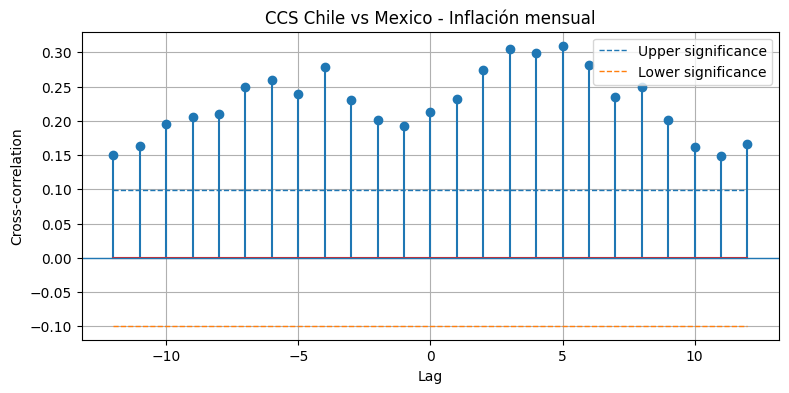


Chile vs Mexico
CCS lag 0: 0.2123485028333622
Maximum absolute correlation: 0.30960884557466584
Lag of maximum absolute correlation: 5


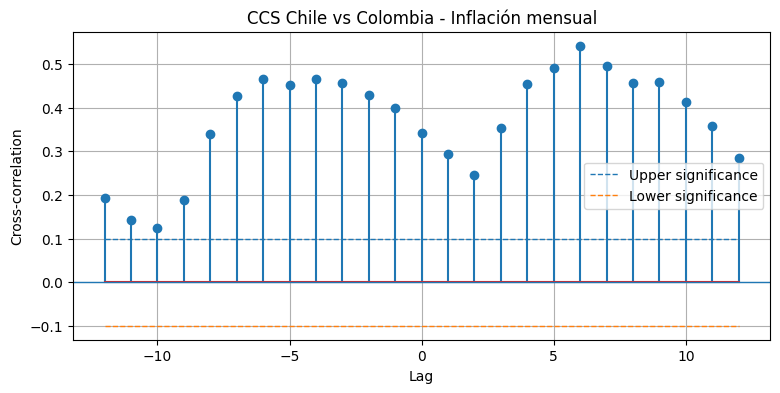


Chile vs Colombia
CCS lag 0: 0.3428085592889402
Maximum absolute correlation: 0.5416244031846694
Lag of maximum absolute correlation: 6


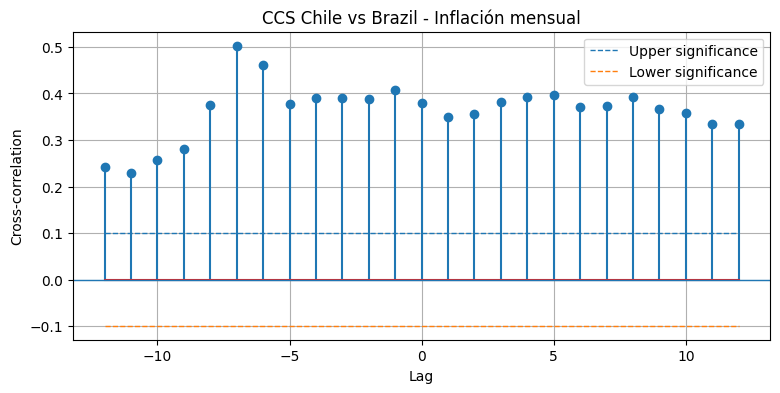


Chile vs Brazil
CCS lag 0: 0.3803554921755499
Maximum absolute correlation: 0.5026473359678184
Lag of maximum absolute correlation: -7


In [118]:
# =============================================================
# 12. CCS CHILE VS CADA PAÍS
# =============================================================

max_lag = 12

ccs_results = {}

for country in comparison_countries:
    
    corrl = ccs(
        inflation["Chile"],
        inflation[country],
        maxT=max_lag,
        twoside=True
    )
    
    ccs_results[country] = corrl
    
    plt.figure(figsize=(9, 4))
    
    plt.stem(corrl.index, corrl["CCS"])
    plt.plot(corrl.index, corrl["upsig"], linestyle="--", linewidth=1, label="Upper significance")
    plt.plot(corrl.index, corrl["dnsig"], linestyle="--", linewidth=1, label="Lower significance")
    
    plt.axhline(0, linewidth=1)
    plt.title(f"CCS Chile vs {country} - Inflación mensual")
    plt.xlabel("Lag")
    plt.ylabel("Cross-correlation")
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Resumen numérico
    max_abs_lag = corrl["CCS"].abs().idxmax()
    max_abs_value = corrl.loc[max_abs_lag, "CCS"]
    lag0_value = corrl.loc[0, "CCS"]
    
    print(f"\nChile vs {country}")
    print("CCS lag 0:", lag0_value)
    print("Maximum absolute correlation:", max_abs_value)
    print("Lag of maximum absolute correlation:", max_abs_lag)

In all three cases, the cross-correlations are positive for all lags analyzed between -12 and 12 months. In addition, many bars exceed the significance bands, indicating an appreciable temporal relationship between Chilean monthly inflation and that of the other countries.

However, this must be interpreted cautiously: a significant CCS does not imply causality. It only indicates temporal association.

The cross-correlation analysis shows positive relationships between Chilean monthly inflation and that of Mexico, Colombia and Brazil for the analyzed lags. The weakest relationship appears with Mexico, with a contemporaneous correlation of 0.21 and a maximum CCS of 0.31 at lag 5. The relationship with Colombia is stronger, reaching a maximum CCS of 0.54 at lag 6. Brazil also shows a moderate relationship with Chile, with a maximum CCS of 0.50 at lag -7, although this result should be interpreted cautiously because of Brazil's extreme inflation episodes at the beginning of the 1990s.

Overall, the results suggest that Chilean inflation is not completely isolated from the inflation dynamics of other Latin American countries. However, the strongest relationships are not always contemporaneous, and the presence of significant lags should not be interpreted as causality. The analysis indicates temporal co-movement, especially with Colombia and Brazil, while the relationship with Mexico is weaker.

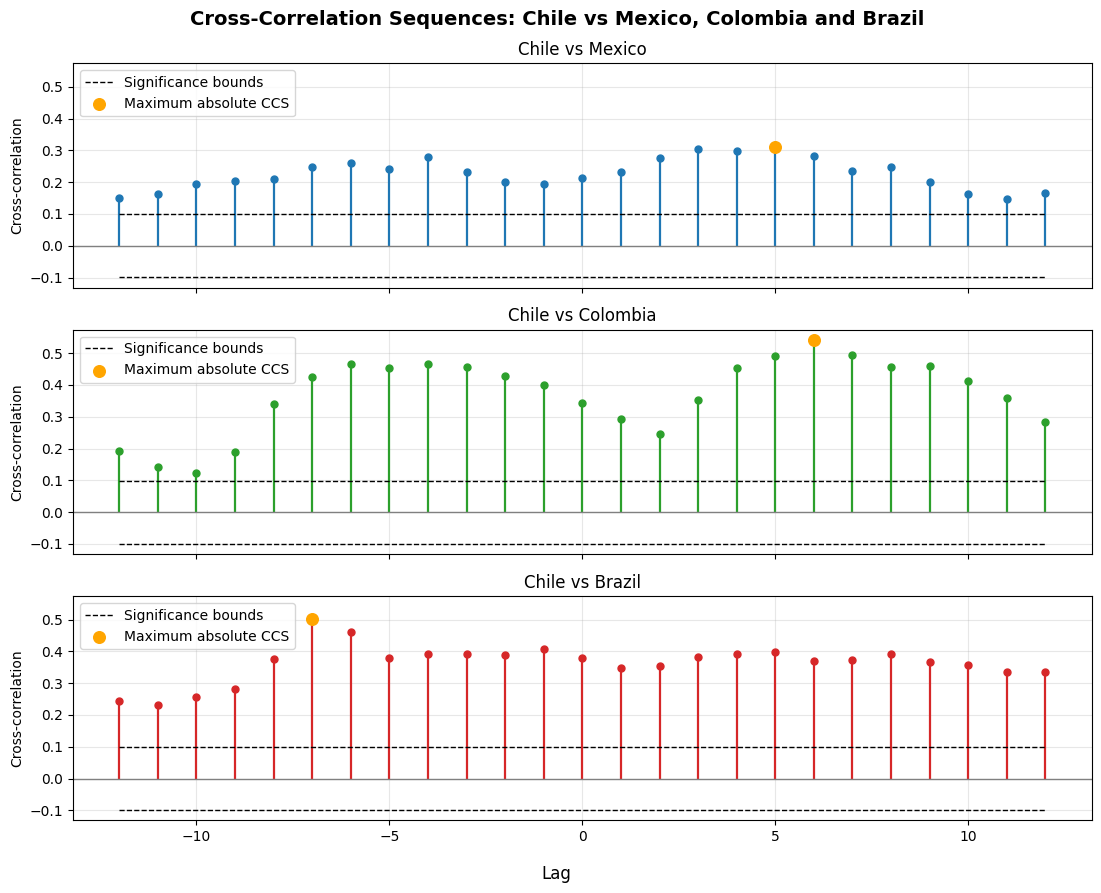

In [121]:
# =============================================================
# COMBINED CCS FIGURE: CHILE VS ALL COUNTRIES
# =============================================================

fig, axes = plt.subplots(
    nrows=len(comparison_countries),
    ncols=1,
    figsize=(11, 9),
    sharex=True,
    sharey=True
)

colors = {
    "Mexico": "tab:blue",
    "Colombia": "tab:green",
    "Brazil": "tab:red"
}

for ax, country in zip(axes, comparison_countries):
    
    corrl = ccs_results[country]
    color = colors.get(country, "tab:blue")
    
    markerline, stemlines, baseline = ax.stem(
        corrl.index,
        corrl["CCS"],
        linefmt=color,
        markerfmt="o",
        basefmt=" "
    )
    
    plt.setp(stemlines, linewidth=1.6)
    plt.setp(markerline, markersize=5)
    
    ax.plot(
        corrl.index,
        corrl["upsig"],
        linestyle="--",
        linewidth=1,
        color="black",
        label="Significance bounds"
    )
    
    ax.plot(
        corrl.index,
        corrl["dnsig"],
        linestyle="--",
        linewidth=1,
        color="black"
    )
    
    ax.axhline(0, linewidth=1, color="gray")
    
    max_abs_lag = corrl["CCS"].abs().idxmax()
    max_abs_value = corrl.loc[max_abs_lag, "CCS"]
    
    ax.scatter(
        max_abs_lag,
        max_abs_value,
        color="orange",
        s=70,
        zorder=3,
        label="Maximum absolute CCS"
    )
    
    ax.set_title(f"Chile vs {country}")
    ax.set_ylabel("Cross-correlation")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left")

fig.suptitle(
    "Cross-Correlation Sequences: Chile vs Mexico, Colombia and Brazil",
    fontsize=14,
    fontweight="bold"
)

fig.supxlabel("Lag")
plt.tight_layout()
plt.show()


**9.13. Tabla resumen de CCS**

In [119]:
# =============================================================
# 13. TABLA RESUMEN CCS CHILE VS PAÍSES
# =============================================================

summary_ccs = []

for country, corrl in ccs_results.items():
    
    lag0 = corrl.loc[0, "CCS"]
    
    max_abs_lag = corrl["CCS"].abs().idxmax()
    max_abs_corr = corrl.loc[max_abs_lag, "CCS"]
    
    significant_lags = corrl[
        (corrl["CCS"] > corrl["upsig"]) |
        (corrl["CCS"] < corrl["dnsig"])
    ].index.tolist()
    
    summary_ccs.append({
        "Pair": f"Chile vs {country}",
        "CCS_lag_0": lag0,
        "Max_abs_CCS": max_abs_corr,
        "Lag_max_abs_CCS": max_abs_lag,
        "Significant_lags": significant_lags
    })

summary_ccs = pd.DataFrame(summary_ccs)

print(summary_ccs)

                Pair  CCS_lag_0  Max_abs_CCS  Lag_max_abs_CCS  \
0    Chile vs Mexico   0.212349     0.309609                5   
1  Chile vs Colombia   0.342809     0.541624                6   
2    Chile vs Brazil   0.380355     0.502647               -7   

                                    Significant_lags  
0  [-12, -11, -10, -9, -8, -7, -6, -5, -4, -3, -2...  
1  [-12, -11, -10, -9, -8, -7, -6, -5, -4, -3, -2...  
2  [-12, -11, -10, -9, -8, -7, -6, -5, -4, -3, -2...  


**9.14. Guardar resultados**

In [120]:
# =============================================================
# 14. GUARDAR RESULTADOS MULTIVARIANTES
# =============================================================

cpi_common.to_csv("latin_america_cpi_common_1990.csv")
inflation.to_csv("latin_america_monthly_inflation_1990.csv")
corr_matrix.to_csv("latin_america_inflation_correlation_matrix.csv")
volatility_table.to_csv("latin_america_inflation_volatility_table.csv")
summary_ccs.to_csv("latin_america_chile_ccs_summary.csv", index=False)

print("Multivariate results saved successfully.")

Multivariate results saved successfully.


Brazil appears as an outlier in the multivariate analysis because it experienced a severe hyperinflation episode in the early 1990s. Monthly rates widely exceeded the conventional threshold of 50% per month, reaching values above 70-80% in some months. This behavior was related to a combination of inertial inflation, widespread price and wage indexation mechanisms, fiscal imbalances, external debt and the failure of several previous stabilization plans.

The situation began to stabilize with the 1994 Real Plan, which introduced a new unit of account and later a new currency, the real. This historical context explains why Brazil has much higher average inflation and monthly volatility than Chile, Mexico and Colombia over the full period. It also means that correlations and scatter plots including Brazil should be interpreted cautiously, since the extreme values of the early 1990s can strongly influence the results.

**Final project conclusion**

This project analyzed and forecast the monthly Consumer Price Index, All items (PCPI_IX) series for Chile from 1990 to 2022. After preprocessing, a complete series with no missing values was obtained from January 1990 to August 2022, and it was chronologically split into training, validation and test sets. The descriptive analysis showed that Chilean CPI has a clear increasing trend, relatively stable variance and an annual seasonal component, so the original series cannot be considered stationary in levels. Manual trend and seasonality removal using moving average and epoch averaging confirmed that non-stationarity was mainly associated with those components, and the ADF test on the transformed series supported stationarity of the residual component.

As an initial reference, a trend-extrapolation baseline was fitted, selecting a degree-1 polynomial because of its better validation performance and simplicity. This model captured the general increasing direction of CPI, but produced the worst test results, with RMSE = 7.587, MAE = 5.974 and MAPE = 5.091%, because it does not explicitly model seasonality or temporal dependence in the series.

The Box-Jenkins approach was then applied using SARIMA models. Based on the previous characterization and ACF/PACF inspection, regular and seasonal differencing were used, obtaining a stationary series after applying d=1, D=1 and S=12. The ADF test on the differenced series confirmed this decision, with a very low p-value. A multiplicative TES model was also fitted, consistent with the presence of trend and seasonality in the series.

In the initial evaluation using a 24-month multi-step forecast, both SARIMA and TES improved on the baseline, but both underestimated the final section of the test set. This limitation is explained by the fact that the test set contains a strong CPI acceleration in 2021-2022, associated with the post-pandemic context, which was not clearly present in train or validation. In addition, the empirical 95% intervals showed insufficient coverage, especially for SARIMA, indicating that the estimated historical uncertainty was not enough to cover the observed change in dynamics during the test period.

To correct this limitation, a rolling one-step-ahead strategy was applied, refitting the model each month with the information available up to that moment and predicting only the following month. This evaluation is more realistic for a monthly forecasting scenario, because it does not use future information and allows the newly observed data to be incorporated progressively. With this strategy, the results improved very notably: SARIMA obtained RMSE = 0.537, MAE = 0.418 and MAPE = 0.366%, while TES obtained RMSE = 1.477, MAE = 1.190 and MAPE = 1.019%. Therefore, under a realistic monthly evaluation, SARIMA is the preferred model because it adapts better to the recent dynamics of Chilean CPI.

Finally, a multivariate comparison was carried out with Mexico, Colombia and Brazil. To avoid scale problems between CPI indices, the series were transformed into monthly inflation using percentage changes. The analysis showed that Chile has relatively more stable monthly inflation than the other countries, while Brazil stands out for much higher volatility due to the extreme inflation episodes of the early 1990s. The contemporaneous correlations and cross-correlation sequences indicate positive relationships between Chile and the other countries, especially with Colombia and Brazil, although these associations should not be interpreted as causality.

Overall, the project shows that the Chilean CPI series can be adequately modeled using classical time-series techniques, provided that its trend, seasonality and possible changes in dynamics are taken into account. The baseline serves as a minimum reference, TES provides a simple and effective alternative for series with trend and seasonality, and SARIMA offers the best final performance when evaluated through rolling one-step-ahead. The multivariate section complements the main analysis by placing Chilean inflation in a Latin American context, without overloading the main forecasting model.